# Classification Evaluation — LoTSS

Evaluates self-supervised and supervised model representations on the LoTSS downstream classification task.
The **evaluation label set** is controlled by `CONFIG["eval_label_set"]`.
The **confusion matrix** (Section 8) uses `CM_CONFIG["eval_label_set"]` (default: `initial_pure`, 5-class multiclass).

All configurations (`CONFIG`, `GRID_CONFIG`, `CM_CONFIG`) are defined in Section 0. All imports are in Section 1.

Sections:
- **0** Configuration
- **1** Imports & Setup
- **2** Load Representations
  - 2.1 Projections
  - 2.2 Representation Space (SW-Sweep UMAP)
  - 2.3 KNN Gallery
  - 2.4 Retrieval Quality — nDCG@10
- **3** Downstream Classifiers
  - 3.1 Encodings vs Projections
- **4** Hyperparameter Sweep
- **5** Supervised Baseline Comparison
- **6** Fine-tuning Comparison
- **7** Label Fraction
  - 7.1 Macro F1
  - 7.2 All Metrics
- **8** Confusion Matrix
  - 8.1 Single-Run Comparison
  - 8.2 SW Sweep Comparison
- **9** Generative Augmentation
  - 9.1 Gen Fraction Sweep
  - 9.2 Augmentation Comparison

## 0. Configuration

Edit `CONFIG` to point to the target checkpoint and set output paths.
`GRID_CONFIG` controls the hyperparameter sweep axes (Section 4).
`CM_CONFIG` controls which classifiers appear in the confusion matrix (Section 8).

In [1]:
CONFIG = {
    # ── Main BYOL run ──────────────────────────────────────────────────────────
    "checkpoint":    "../outputs/byol_runs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1/data_seed_2/training_seed_2/byol_model_best.pt",
    "catalogue":     "../catalogues/lotss_initial_all.yaml",
    "colour_by":     "dataset",   # "dataset" | "label"
    "root":          "..",

    # ── Seeds ─────────────────────────────────────────────────────────────────
    "data_seed":     2,   # data_seed_N used by the reference checkpoint
    "training_seed": 2,   # training_seed_N used by the reference checkpoint
    "variation":     "cv",  # "cv" (5-fold cross-val) | "seeds" (multiple seed runs)

    # ── Label sets & classifier settings ───────────────────────────────────────
    # See label-set explanation cell below for definitions of pure / binary / (none).
    "train_label_set": 'initial_pure', # initial | initial_pure | initial_binary
    "class_weight":    "",               # "" (no weighting) | "all" | "initial"
    "eval_label_set": "initial_pure",

    # ── Supervised baselines (Section 4) ──────────────────────────────────────
    "baselines_dir": "../outputs/supervised_baseline_classifiers",

    # ── Generative augmentation sweep dirs (Section 9) ────────────────────────
    "aug_comp_dir": "../outputs/supervised_baseline_classifiers/aug_comp",

    "gen_sweep_dirs": [
        "../outputs/supervised_baseline_classifiers/gen_sweep",
    ],

    # ── Fine-tuning runs (Sections 6, 8) ───────────────────────────
    "finetuning_runs": [
        "../outputs/byol_runs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1/data_seed_2/training_seed_2/",
    ],
    "finetuning_spec": "mode2_lr1e-2_ep40",             # mode2: frozen encoder, fine-tune projector + head
    "finetuning_spec_retrained": "mode3_lr1e-5_ep40",   # mode3: full encoder retrain (Section 6)

    # ── BYOL runs root (Section 6) ────────────────────────────────────────────
    "byol_runs_dir": "../outputs/byol_runs/byol_runs",
}

# ── Hyperparameter sweep (Section 7) ──────────────────────────────────────────
GRID_CONFIG = {
    "axis_x":        "f",            # label fraction  (f0, f0.1, f0.5, f1 …)
    "axis_y":        "sw",           # supervision wt  (sw0.01, sw0.1, sw1 …)
    "classifier":    "lr",           # rf | knn | lr
    "feature_type":  "projections",
    "outputs_root":  "../outputs/byol_runs/byol_runs",
    "run_glob":      "pd128_*",
}

# ── Confusion matrix (Section 8) ──────────────────────────────────────────────
CM_CONFIG = {
    "eval_label_set":  "initial_pure",
    "byol_classifier": "linear_probe",   # "random_forest" | "knn" | "linear_probe"
    "baseline_model":  "enb0",           # substring matched against baseline run dir names
    "n_estimators":    200,
    "n_neighbors":     15,
}

OUT_DIR = "/users/mbredber/p3_SUPLAT/outputs/figures/classification"
SEED    = 42

### Label-set naming conventions

#### Base label groups

| Base | Classes |
|------|---------|
| `classical` | FRI, FRII *(2 classes)* |
| `initial` | FRI, FRII, Hybrids, Spirals, Relaxed doubles *(5 classes)* |
| `morphology` | C-curv, S-curv, Misalign, Wings, X-shaped, Straight jets, Multi hotspots, Cont. jets, Banding, One-sided, Restarted *(11 classes)* |
| `environment` | Cluster, Merger, Diffuse, Unknown *(4 classes)* |
| `full` | All 20 classes combined |

#### Suffix variants

Each base group can be combined with a suffix:

| Suffix | Example | What it means |
|--------|---------|---------------|
| *(none)* | `initial` | **Multi-label, all sources.** Sources can belong to several classes simultaneously; the full multi-hot vector is used. No sources are discarded. |
| `_pure` | `initial_pure` | **Single-label subset.** Only sources with *exactly one* active class are kept. Becomes a standard N-way multiclass problem (argmax prediction). Ambiguous or unlabelled sources are discarded. |
| `_binary` | `initial_binary` | **Per-class binary classifiers, all sources.** No filtering — every source is included. N independent binary classifiers answer "yes or no" for each class. Accuracy is element-wise, not argmax. Better suited to multi-label data. |

#### `class_weight` option

Controls how training loss is weighted by class frequency:

| Value | Effect |
|-------|--------|
| `""` *(empty)* | Uniform weights — all samples contribute equally |
| `"all"` | Inverse-frequency weighting across all 20 classes |
| `"initial"` | Inverse-frequency weighting within the initial 5 classes only |

**Which label set to use:**
- `_pure` gives the cleanest multiclass benchmark but discards a significant fraction of sources.
- `_binary` retains all sources and handles multi-label overlap, at the cost of a harder task.
- *(none)* is rarely used for evaluation — it appears as the BYOL supervision label set.

## 1. Imports & Setup

All third-party imports and project-local imports (`ALL_CLASS_NAMES`, `LABEL_SETS`).
Includes UMAP, DBSCAN, and pandas for the sw-sweep UMAP section.
`OUT_DIR` is created here if it does not exist.

In [2]:
import os, sys, re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import umap as umap_lib
from pathlib import Path
from matplotlib.gridspec import GridSpec as _GridSpec
from matplotlib.lines import Line2D
from sklearn.cluster import DBSCAN
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors as _NNR
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score, confusion_matrix

# Add project src and scripts to path
_root = os.path.abspath("..")
for _p in [os.path.join(_root, "src"), os.path.join(_root, "scripts")]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

from train_byol_classifiers import ALL_CLASS_NAMES, LABEL_SETS

os.makedirs(OUT_DIR, exist_ok=True)
print("Imports OK")

# Canonical sw-parameter colour palette (shared across all cells/notebooks)
_SW_PALETTE = ["#1B2A6B", "#8DB0FE", "#F4A582", "#8B2E1F"]  # cividis 4-pt: sw 0.0, 0.05, 0.1, 0.5

Imports OK


## 2. Load Representations

Loads model projections and UMAP embeddings for the reference checkpoint and all sibling sw-sweep runs.

### 2.1 Projections

Loads pre-extracted projections from `data/byol/` for the reference checkpoint. Train/test split is reconstructed from the shared `data_splits/` directory. Prints source counts by label tag for the eval label set.

In [3]:
_run_dir  = Path(CONFIG["checkpoint"]).parent   # .../pd128_.../data_seed_2/training_seed_2/
_data_dir = _run_dir / "data"
_byol_dir = _data_dir / "byol"

# Extract f-label tag from run name (e.g. "_f1", "_f0.1")
_run_name = _run_dir.parent.parent.name
_f_m  = re.search(r'_f([\d.]+)', _run_name)
_f_tag = f"_f{_f_m.group(1)}" if _f_m else ""

# Derive shared splits directory from the configured data_seed.
# Layout: outputs/byol_runs/byol_runs/<run>/data_seed_N/training_seed_N/  →  outputs/data_splits/<seed>/
_data_seed  = CONFIG["data_seed"]
_splits_dir = _run_dir.parent.parent.parent.parent.parent / "data_splits" / str(_data_seed)

# In CV mode, use fold 0 for display (projections/splits for §2 UMAP, §3 encodings).
if CONFIG.get("variation") == "cv":
    _cv_fold_dirs = sorted(f for f in _run_dir.glob("cross_val_*") if f.is_dir())
    if _cv_fold_dirs:
        _cv_byol_dir = _run_dir / "cross_val_0" / "data" / "byol"
        if (_cv_byol_dir / "labelled_train_projections.npy").exists():
            _byol_dir   = _cv_byol_dir
            _splits_dir = _splits_dir / "cross_val_0"
        print(f"CV mode: {len(_cv_fold_dirs)} folds detected — using fold 0 for projections display")

def _load_label(name):
    """Load a label .npy from splits_dir (new runs) or data_dir (old runs)."""
    p = _splits_dir / name
    return np.load(p if p.exists() else _data_dir / name)

_X_train = np.load(_byol_dir / "labelled_train_projections.npy").astype(np.float32)
_X_test  = np.load(_byol_dir / "test_projections.npy").astype(np.float32)

_lab_labels_path = _splits_dir / f"labelled_train_labels{_f_tag}.npy"
if not _lab_labels_path.exists():
    _lab_labels_path = _splits_dir / "labelled_train_labels.npy"
if not _lab_labels_path.exists():
    _lab_labels_path = _data_dir / "labelled_train_labels.npy"
if _lab_labels_path.exists():
    _y_train_20 = np.load(_lab_labels_path)
    if len(_y_train_20) != len(_X_train):
        # Reconstruct by concatenating labelled + unlabelled labels.
        _unlab_labels_path = _splits_dir / f"unlabelled_train_labels{_f_tag}.npy"
        if not _unlab_labels_path.exists():
            _unlab_labels_path = _splits_dir / "unlabelled_train_labels.npy"
        if _unlab_labels_path.exists():
            _y_unlab_20 = np.load(_unlab_labels_path)
            _y_train_20 = np.concatenate([_y_train_20, _y_unlab_20], axis=0)
        if len(_y_train_20) != len(_X_train):
            raise ValueError(f"Label count {len(_y_train_20)} != projection count {len(_X_train)}")
else:
    _y_train_20 = None

_y_test_20 = np.load(_splits_dir / "test_labels.npy") if (_splits_dir / "test_labels.npy").exists() else None

print(f"Loaded lotss_initial_pure: train={len(_X_train)}  test={len(_X_test)}  proj_dim={_X_train.shape[1]}")

CV mode: 5 folds detected — using fold 0 for projections display
Loaded lotss_initial_pure: train=6076  test=1520  proj_dim=128


In [4]:
# ── Source counts per unique tag in eval label set (test split) ───────────────
_eval_ls  = CONFIG["eval_label_set"]
_els_cols = LABEL_SETS[_eval_ls]
_n_els    = len(_els_cols)
_is_pure  = "_pure" in _eval_ls
_names    = [ALL_CLASS_NAMES[c] for c in _els_cols]

_y_te_tab = _y_test_20[:, _els_cols]
if _is_pure:
    _pure_mask = _y_te_tab.sum(axis=1) == 1
    _y_te_tab  = _y_te_tab[_pure_mask]

_total = len(_y_te_tab)
_unique_tags, _counts = np.unique(_y_te_tab, axis=0, return_counts=True)
_order = np.argsort(_counts)[::-1]

_tag_w  = _n_els * 3 + 2
_name_w = max(len(n) for n in _names) + 4
print(f"Eval label set : {_eval_ls}  ({'pure sources only' if _is_pure else 'all sources'})")
_tag_note = " (5 independent binary labels)" if not _is_pure else ""
print(f"Test sources   : {_total}  |  unique co-occurrence patterns: {len(_unique_tags)}{_tag_note}\n")
_hdr = f"  {'Tag':<{_tag_w}}  {'Active classes':<{_name_w}}  {'N':>6}  {'%':>6}"
print(_hdr)
print("-" * len(_hdr))
for _idx in _order:
    _tag     = _unique_tags[_idx]
    _tag_str = "[" + ", ".join(str(int(v)) for v in _tag) + "]"
    _active  = [_names[j] for j, v in enumerate(_tag) if v]
    _cls_str = ", ".join(_active) if _active else "(none)"
    _cnt     = int(_counts[_idx])
    _pct     = 100 * _cnt / _total if _total > 0 else 0
    print(f"  {_tag_str:<{_tag_w}}  {_cls_str:<{_name_w}}  {_cnt:>6}  {_pct:>5.1f}%")

Eval label set : initial_pure  (pure sources only)
Test sources   : 1349  |  unique co-occurrence patterns: 5

  Tag                Active classes            N       %
--------------------------------------------------------
  [0, 1, 0, 0, 0]    FRII                    853   63.2%
  [1, 0, 0, 0, 0]    FRI                     375   27.8%
  [0, 0, 1, 0, 0]    Hybrids                  55    4.1%
  [0, 0, 0, 0, 1]    Relaxed doubles          44    3.3%
  [0, 0, 0, 1, 0]    Spirals                  22    1.6%


### 2.2 Representation Space (SW-Sweep UMAP)

Discovers all sibling runs matching the checkpoint's base name (varying `sw` and `f`), loads or fits 2-D UMAP embeddings for each, and plots the representation space coloured by initial morphological class. Island sub-plots zoom in on small off-continent clusters.

In [5]:
def _get_seed_dirs(run_name_dir):
    """Return training_seed_N dirs for each data_seed_N (training_seed == data_seed)."""
    result = []
    for ds_dir in sorted(run_name_dir.glob("data_seed_*")):
        n = int(ds_dir.name.split("_")[-1])
        ts_dir = ds_dir / f"training_seed_{n}"
        if ts_dir.is_dir():
            result.append(ts_dir)
    return result


def _get_fold_dirs(run_dir):
    """Return cross_val_K subdirs if this is a CV run, else [run_dir]."""
    folds = sorted(f for f in run_dir.glob("cross_val_*") if f.is_dir())
    return folds if folds else [run_dir]




def _get_available_seeds(run_dir):
    """Return sorted list of integer seeds covering both off-diagonal (ts=ds+1)
    and diagonal (ts=ds) training-seed dirs.

    Off-diagonal dirs are used by f=1 runs; diagonal dirs with cross_val_K
    subdirs are used by f<1 runs.
    """
    seeds = set()
    # Off-diagonal: training_seed = data_seed + 1 (standard f=1 runs)
    for d in _get_seed_dirs(run_dir):
        seeds.add(int(d.name.split("_")[-1]))
    # Diagonal: training_seed = data_seed (cross-val / f<1 runs)
    for ds_dir in sorted(run_dir.glob("data_seed_*")):
        n = int(ds_dir.name.split("_")[-1])
        if (ds_dir / f"training_seed_{n}").is_dir():
            seeds.add(n)
    return sorted(seeds)


# ── UMAP sweep config + helper functions ─────────────────────────────────────
# Derive glob from checkpoint: replace specific sw/f values with wildcards
OUTPUTS_ROOT  = _run_dir.parent.parent.parent.parent.parent    # .../outputs/
_run_basename = _run_dir.parent.parent.name             # e.g. pd128_..._sw0.05_f1
_glob_name    = re.sub(r'_sw[\d.]+', '_sw*', re.sub(r'_f[\d.]+', '_f*', _run_basename))
RUN_GLOB_BASE = f"byol_runs/byol_runs/{_glob_name}"
_f_m_anchor   = re.search(r'_f([\d.]+)', _run_basename)
F_ANCHOR      = float(_f_m_anchor.group(1)) if _f_m_anchor else 1.0
FEATURE_TYPE  = "projections"

LABELS_NPY_PATH = str(OUTPUTS_ROOT.parent / "data" / "preprocessed" / "lotss" / "labels_filtered.npy")

LABEL_COLS = [
    "fri", "frii", "hybrid", "spiral", "relaxed",
    "cshaped", "sshaped", "misaligned", "wings", "xshaped",
    "straight", "multihotspots", "continuous", "banding", "onesided",
    "restarted", "cluster", "merger", "diffuse", "unknown",
]
SCORE_4 = ["xshaped", "unknown", "cluster", "merger"]
SCORE_3 = ["diffuse", "sshaped", "spiral"]
SCORE_2 = ["restarted", "onesided", "banding", "cshaped", "wings",
           "misaligned", "multihotspots", "relaxed"]
SCORE_1 = ["fri", "frii", "hybrid", "straight", "continuous"]
TIERS   = [(4, SCORE_4), (3, SCORE_3), (2, SCORE_2), (1, SCORE_1)]

INITIAL_NAMES = ["FRI", "FRII", "Hybrid", "Spiral", "Relaxed", "None or multiple"]

_labels_all = np.load(LABELS_NPY_PATH)   # (N_all, 20)


def build_human_labels(idx_arr):
    """Map global source indices → integer interest score 1–4."""
    ldf = pd.DataFrame(_labels_all[idx_arr].astype(bool), columns=LABEL_COLS)
    hl  = np.ones(len(ldf), dtype=int)
    for score_val, cols in reversed(TIERS):
        hl[ldf[cols].any(axis=1).values] = score_val
    return hl


def build_initial_labels(idx_arr):
    """Map global source indices → integer initial class 0–4, or 5 ('None or multiple')."""
    init   = _labels_all[idx_arr, 0:5].astype(bool)
    n_init = init.sum(axis=1)
    labels = np.full(len(idx_arr), 5, dtype=int)
    for c in range(5):
        labels[(n_init == 1) & init[:, c]] = c
    return labels


def load_run(run_dir, feature_type="projections", cv_fold=None):
    """Load all projections + global indices for a run (train + test).

    If cv_fold is set and cross_val_{cv_fold}/ exists, projections and splits
    are loaded from that fold's subdirectory.
    """
    d = run_dir / "data"
    b = d / "byol"
    ckpt    = torch.load(run_dir / "byol_model_best.pt", map_location="cpu", weights_only=False)
    seed    = int(ckpt["config"]["data_seed"])
    f_label = float(ckpt["config"].get("f_label", 1.0))
    if re.match(r"seed\d+$", run_dir.name):
        s = run_dir.parent.parent.parent / "data_splits" / str(seed)
    elif re.match(r"training_seed_\d+$", run_dir.name):
        s = run_dir.parent.parent.parent.parent.parent / "data_splits" / str(seed)
    else:
        s = run_dir.parent.parent / "data_splits" / str(seed)
    f_str = str(int(f_label)) if f_label == int(f_label) else str(f_label)

    # Redirect to CV fold if requested and available
    if cv_fold is not None:
        _cv_byol = run_dir / f"cross_val_{cv_fold}" / "data" / "byol"
        if _cv_byol.is_dir():
            b = _cv_byol
            s = s / f"cross_val_{cv_fold}"

    def _load_idx(name):
        p = s / name
        return np.load(p if p.exists() else d / name)

    train_idx_all = _load_idx("train_idx.npy")
    test_idx      = _load_idx("test_idx.npy")
    test_proj     = np.load(b / f"test_{feature_type}.npy")
    lab_proj      = np.load(b / f"labelled_train_{feature_type}.npy")
    n_lab = len(lab_proj)
    n_all = len(train_idx_all)
    unlab_path = b / f"unlabelled_train_{feature_type}.npy"

    if f_label == 0.0 or n_lab == n_all:
        train_proj    = lab_proj
        train_idx_out = train_idx_all
    else:
        try:
            lab_idx_shared = _load_idx(f"labelled_train_idx_f{f_str}.npy")
        except FileNotFoundError:
            lab_idx_shared = _load_idx("labelled_train_idx.npy")
        lab_idx = lab_idx_shared if len(lab_idx_shared) == n_lab else train_idx_all[:n_lab]
        if unlab_path.exists():
            unlab_proj = np.load(unlab_path)
            n_unlab    = len(unlab_proj)
            try:
                unlab_idx_shared = _load_idx(f"unlabelled_train_idx_f{f_str}.npy")
            except FileNotFoundError:
                unlab_idx_shared = _load_idx("unlabelled_train_idx.npy")
            unlab_idx     = (unlab_idx_shared if len(unlab_idx_shared) == n_unlab
                             else train_idx_all[n_lab:])
            train_proj    = np.concatenate([lab_proj, unlab_proj], axis=0)
            train_idx_out = np.concatenate([lab_idx, unlab_idx])
        else:
            train_proj    = lab_proj
            train_idx_out = lab_idx

    all_proj = np.concatenate([train_proj, test_proj], axis=0)
    all_idx  = np.concatenate([train_idx_out, test_idx])
    return all_proj, all_idx


def get_or_fit_umap(run_dir, projections, feature_type="projections",
                    n_neighbors=15, min_dist=0.1, n_components=2):
    npy_cache = run_dir / "data" / "byol" / f"umap_{feature_type}.npy"
    if npy_cache.exists():
        coords = np.load(npy_cache)
        if coords.shape[0] == projections.shape[0]:
            return coords
    print(f"  fitting UMAP ({projections.shape[0]} sources, dim={projections.shape[1]})...", flush=True)
    import umap
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist,
                        n_components=n_components, random_state=42)
    coords  = reducer.fit_transform(projections)
    np.save(npy_cache, coords)
    return coords

In [6]:
# ── Discover sw-sweep runs + load UMAP coords ────────────────────────────────
all_matches = sorted(OUTPUTS_ROOT.glob(RUN_GLOB_BASE))
run_map = {}
for rd in all_matches:
    name_to_parse = rd.name
    m = re.search(r"_sw([\d.]+)_f([\d.]+)", name_to_parse)
    if m:
        key = (float(m.group(2)), float(m.group(1)))
    else:
        m = re.search(r"_f([\d.]+)_sw([\d.]+)", name_to_parse)
        if not m:
            continue
        key = (float(m.group(1)), float(m.group(2)))
    run_map[key] = rd

print(f"Found {len(run_map)} (f, sw) combinations.")

_umap_cv_fold = 0 if CONFIG.get("variation") == "cv" else None

run_data = {}
for key, rd in sorted(run_map.items()):
    f, sw = key
    _seed_dirs_sw = _get_seed_dirs(rd)
    _actual_rd = _seed_dirs_sw[0] if _seed_dirs_sw else rd
    try:
        proj, idx = load_run(_actual_rd, FEATURE_TYPE, cv_fold=_umap_cv_fold)
        coords    = get_or_fit_umap(_actual_rd, proj, FEATURE_TYPE)
        run_data[key] = dict(
            coords         = coords,
            human_labels   = build_human_labels(idx),
            initial_labels = build_initial_labels(idx),
            run_dir        = _actual_rd,
        )
    except FileNotFoundError as e:
        print(f"  ✗ skipping [f={f} sw={sw}]: {e}")

print(f"Loaded {len(run_data)} runs.")


Found 16 (f, sw) combinations.


Loaded 16 runs.


In [7]:
# ── Island detection + build _sw_data ────────────────────────────────────────
def _find_islands(umap_real, umap_gen, eps_frac=0.04, min_samples=8):
    """Cluster real+gen UMAP points; return per-point labels and island IDs."""
    pts = np.vstack([umap_real, umap_gen]) if len(umap_gen) else umap_real
    span = max(pts[:, 0].max() - pts[:, 0].min(), pts[:, 1].max() - pts[:, 1].min())
    labels_cl = DBSCAN(eps=span * eps_frac, min_samples=min_samples).fit_predict(pts)
    if (labels_cl == -1).any() and (labels_cl >= 0).any():
        ids_lab = np.unique(labels_cl[labels_cl >= 0])
        centres = np.array([pts[labels_cl == k].mean(0) for k in ids_lab])
        nn = _NNR(n_neighbors=1).fit(centres)
        _, idx = nn.kneighbors(pts[labels_cl == -1])
        labels_cl[labels_cl == -1] = ids_lab[idx.ravel()]
    uniq, cnt = np.unique(labels_cl, return_counts=True)
    continent_id = uniq[np.argmax(cnt)]
    n_real = len(umap_real)
    return (labels_cl[:n_real], labels_cl[n_real:],
            continent_id, [k for k in uniq if k != continent_id])


label_names_subset = INITIAL_NAMES[:5]
n_labels           = len(label_names_subset)
class_colors       = [plt.cm.tab10(i / 10.0) for i in range(n_labels)]

_empty_gen = np.empty((0, 2))
_sw_data   = {}
for (_f_val, _sw_val), _d in run_data.items():
    if _f_val != F_ANCHOR:
        continue
    _rc = [class_colors[_l] if _l < n_labels else (1., 1., 1., 1.)
           for _l in _d["initial_labels"]]
    _sw_data[_sw_val] = dict(umap_real=_d["coords"], umap_gen=_empty_gen, real_colors=_rc)

_OUT_SW = Path(OUT_DIR)
_stem_f = _run_dir.parent.name
_ls_str = "initial"

print(f"_sw_data sw values: {sorted(_sw_data.keys())}")

_sw_data sw values: [0.0, 0.05, 0.1, 0.5, 1.0]


SW-sweep UMAP focal (cropped, real only): projections


Saved → /users/mbredber/p3_SUPLAT/outputs/figures/classification/umap_sw_sweep_focal_cropped_real_data_seed_2_initial.pdf


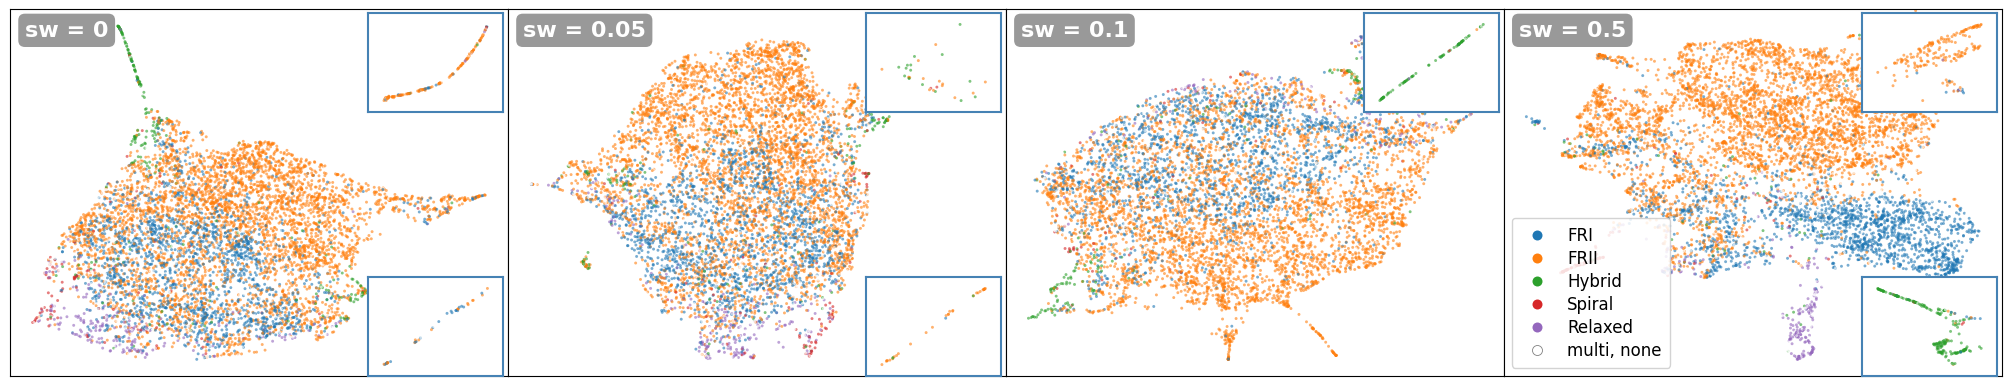

In [8]:
# ── SW-sweep UMAP — real data only (same style, no generated points) ──────────

def _plot_sw_panels_cropped_real(sw_selection, title, out_path, panel_size=3.2,
                                  legend_fontsize=10, height_ratio=0.75):
    _n = len(sw_selection)
    if _n == 0:
        print(f"No sw values found in _sw_data for selection — skipping: {title}")
        return
    fig, axes = plt.subplots(1, _n, figsize=(panel_size * _n, panel_size * height_ratio),
                             gridspec_kw={"wspace": 0.0})
    if _n == 1:
        axes = [axes]
    _pt_size  = max(3, panel_size * 0.9)
    _corners = [(0.72, 0.72), (0.72, 0.00), (0.00, 0.72), (0.00, 0.00)]
    _inset_w = 0.27

    for _ax, _sw_val in zip(axes, sw_selection):
        _d = _sw_data[_sw_val]
        _ur, _ug = _d["umap_real"], _d["umap_gen"]

        # ── Island detection (same as original, using real+gen for consistent bounds) ──
        _rl, _gl, _cid, _island_ids = _find_islands(_ur, _ug)

        # Continent bounds (identical to original so axes match)
        _cont_mask_r = _rl == _cid
        _cont_mask_g = _gl == _cid
        _cont_pts = np.vstack([_ur[_cont_mask_r], _ug[_cont_mask_g]]) if _cont_mask_g.any() else _ur[_cont_mask_r]
        _pad = lambda lo, hi, f: (lo - (hi - lo) * f, hi + (hi - lo) * f)
        _xl = _pad(_cont_pts[:, 0].min(), _cont_pts[:, 0].max(), 0.05)
        _yl = _pad(_cont_pts[:, 1].min(), _cont_pts[:, 1].max(), 0.05)
        _ax.set_xlim(_xl); _ax.set_ylim(_yl)

        # ── Real points only ──────────────────────────────────────────────────
        _ax.scatter(_ur[:, 0], _ur[:, 1],
                    c=_d["real_colors"], s=_pt_size, alpha=0.6, edgecolors="none", marker="o", zorder=2)

        _ax.text(0.03, 0.97, f"sw = {_sw_val}", transform=_ax.transAxes,
                 fontsize=16, color="white", va="top", ha="left", fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.3", fc="black", alpha=0.4, ec="none"))
        _ax.set_xticks([]); _ax.set_yticks([])

        # ── Island insets (up to 4) ───────────────────────────────────────────
        for _iidx, _kid in enumerate(_island_ids[:4]):
            _x0, _y0 = _corners[_iidx]
            _iax = _ax.inset_axes([_x0, _y0, _inset_w, _inset_w])

            _ir_mask = _rl == _kid
            _ig_mask = _gl == _kid if len(_gl) else np.zeros(0, dtype=bool)
            _ipts = _ur[_ir_mask] if _ir_mask.any() else None

            if _ipts is not None and len(_ipts) > 0:
                _ixl = _pad(_ipts[:, 0].min(), _ipts[:, 0].max(), 0.15)
                _iyl = _pad(_ipts[:, 1].min(), _ipts[:, 1].max(), 0.15)
                _iax.set_xlim(_ixl); _iax.set_ylim(_iyl)

            if _ir_mask.any():
                _irc = [_d["real_colors"][_j] for _j in np.where(_ir_mask)[0]]
                _iax.scatter(_ur[_ir_mask, 0], _ur[_ir_mask, 1],
                             c=_irc, s=_pt_size, alpha=0.6, edgecolors="none", marker="o", zorder=2)

            _iax.set_xticks([]); _iax.set_yticks([])
            for _spine in _iax.spines.values():
                _spine.set_edgecolor("steelblue"); _spine.set_linewidth(1.5)

    # ── Legend ────────────────────────────────────────────────────────────────
    _ms_small = legend_fontsize * 0.6
    _class_handles = [
        Line2D([0], [0], marker="o", linestyle="none",
               markerfacecolor=class_colors[_i], markeredgecolor="none",
               markersize=_ms_small, label=label_names_subset[_i])
        for _i in range(n_labels)
    ] + [
        Line2D([0], [0], marker="o", linestyle="none",
               markerfacecolor="white", markeredgecolor="gray", markeredgewidth=0.6,
               markersize=_ms_small, label="multi, none"),
    ]
    axes[min(3, _n - 1)].legend(handles=_class_handles, loc="lower left",
                                 ncol=1, fontsize=legend_fontsize, framealpha=0.85,
                                 borderpad=0.5, labelspacing=0.3)
    plt.tight_layout(pad=0.3)
    print(title)
    fig.savefig(out_path, bbox_inches="tight")
    print(f"Saved → {out_path}")
    plt.show()


_plot_sw_panels_cropped_real(
    [v for v in [0, 0.05, 0.1, 0.5] if v in _sw_data],
    "SW-sweep UMAP focal (cropped, real only): projections",
    _OUT_SW / f"umap_sw_sweep_focal_cropped_real_{_stem_f}_{_ls_str}.pdf",
    panel_size=5.0,
    legend_fontsize=12,
)


  sw=0.0: loaded test UMAP cache (2279 sources)
  sw=0.05: loaded test UMAP cache (2279 sources)
  sw=0.1: loaded test UMAP cache (2279 sources)
  sw=0.5: loaded test UMAP cache (2279 sources)


  sw=1.0: loaded test UMAP cache (2279 sources)


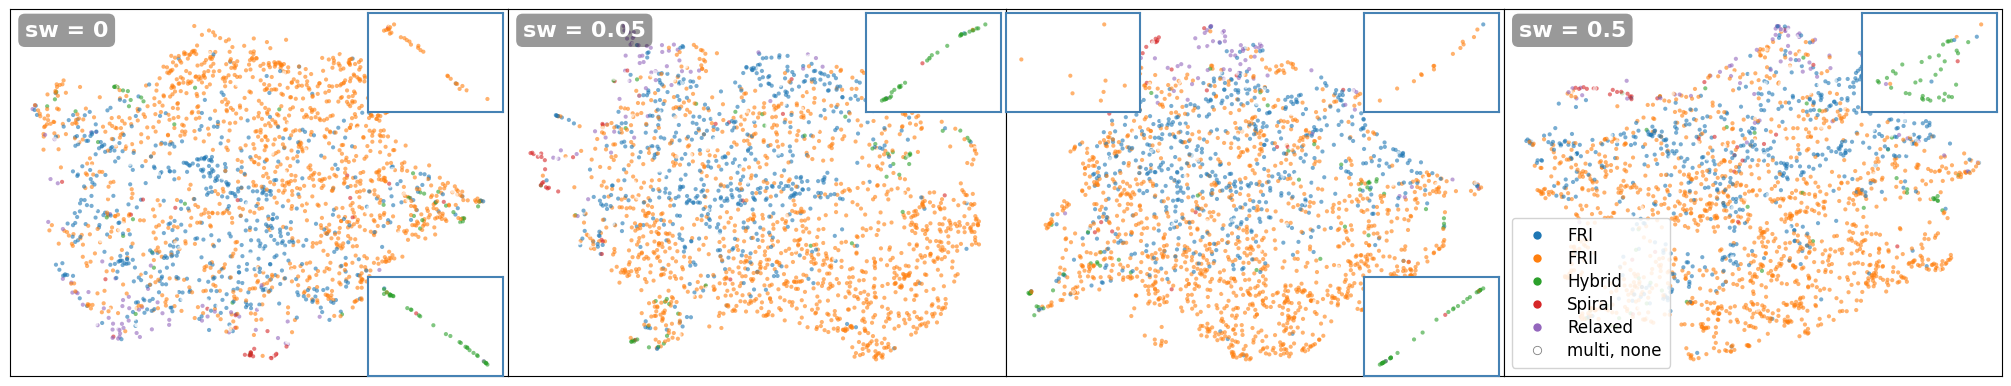

Saved → /users/mbredber/p3_SUPLAT/outputs/figures/classification/umap_sw_sweep_focal_cropped_test_data_seed_2_initial.pdf


In [9]:
# ── SW-sweep UMAP — test data only ────────────────────────────────────────────
# Fits a separate UMAP on test projections only (one per sw value),
# coloured by initial morphological class, same style as the all-data real-only panel above.

_sw_test_data = {}  # sw_val → dict(umap, colors)

for _sw_val in sorted(_sw_data.keys()):
    if (F_ANCHOR, _sw_val) not in run_data:
        continue
    _actual_rd = run_data[(F_ANCHOR, _sw_val)]["run_dir"]
    _byol_d    = _actual_rd / "data" / "byol"

    # Locate splits dir (mirrors load_run logic for training_seed_N dirs)
    _ckpt_sw  = torch.load(_actual_rd / "byol_model_best.pt", map_location="cpu", weights_only=False)
    _dseed_sw = int(_ckpt_sw["config"]["data_seed"])
    _splits_sw = _actual_rd.parent.parent.parent.parent.parent / "data_splits" / str(_dseed_sw)

    # Load test projections and indices
    _tp_path = _byol_d / f"test_{FEATURE_TYPE}.npy"
    _ti_path = _splits_sw / "test_idx.npy"
    if not _tp_path.exists():
        print(f"  sw={_sw_val}: missing {_tp_path}"); continue
    _test_proj = np.load(_tp_path).astype(np.float32)
    _test_idx  = np.load(_ti_path)[:len(_test_proj)] if _ti_path.exists() else np.array([], dtype=int)

    # Fit / load test-only UMAP (separate cache from the all-data UMAP)
    _cache = _byol_d / f"umap_test_{FEATURE_TYPE}.npy"
    if _cache.exists() and np.load(_cache).shape[0] == len(_test_proj):
        _t_emb = np.load(_cache)
        print(f"  sw={_sw_val}: loaded test UMAP cache ({len(_t_emb)} sources)")
    else:
        print(f"  sw={_sw_val}: fitting test-only UMAP ({len(_test_proj)} sources) …", flush=True)
        _t_emb = umap_lib.UMAP(random_state=42, n_neighbors=15, min_dist=0.1).fit_transform(_test_proj)
        np.save(_cache, _t_emb)

    # Build initial-class colours (same mapping as the all-data panel)
    _init_lbl = (build_initial_labels(_test_idx) if len(_test_idx)
                 else np.full(len(_test_proj), 5, dtype=int))
    _tc = [class_colors[_l] if _l < n_labels else (1., 1., 1., 1.) for _l in _init_lbl]
    _sw_test_data[_sw_val] = dict(umap=_t_emb, colors=_tc)

# ── Plot ────────────────────────────────────────────────────────────────────
_sw_sel = [v for v in [0, 0.05, 0.1, 0.5] if v in _sw_test_data]
_n      = len(_sw_sel)
if _n == 0:
    print("No test UMAP data available — run cells above first.")
else:
    _panel_size = 5.0
    _corners    = [(0.72, 0.72), (0.72, 0.00), (0.00, 0.72), (0.00, 0.00)]
    _inset_w    = 0.27
    _pt_size    = 2 * max(3, _panel_size * 0.9)
    _pad_t      = lambda lo, hi, f: (lo - (hi - lo) * f, hi + (hi - lo) * f)

    fig, axes = plt.subplots(1, _n, figsize=(_panel_size * _n, _panel_size * 0.75),
                             gridspec_kw={"wspace": 0.0})
    if _n == 1:
        axes = [axes]

    for _ax, _sw_val in zip(axes, _sw_sel):
        _td  = _sw_test_data[_sw_val]
        _emb = _td["umap"]
        _col = _td["colors"]
        _rl, _, _cid, _iids = _find_islands(_emb, _empty_gen)

        _cont_pts = _emb[_rl == _cid]
        _ax.set_xlim(_pad_t(_cont_pts[:, 0].min(), _cont_pts[:, 0].max(), 0.05))
        _ax.set_ylim(_pad_t(_cont_pts[:, 1].min(), _cont_pts[:, 1].max(), 0.05))

        _ax.scatter(_emb[:, 0], _emb[:, 1],
                    c=_col, s=_pt_size, alpha=0.6, edgecolors="none", marker="o", zorder=2)

        _ax.text(0.03, 0.97, f"sw = {_sw_val}", transform=_ax.transAxes,
                 fontsize=16, color="white", va="top", ha="left", fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.3", fc="black", alpha=0.4, ec="none"))
        _ax.set_xticks([]); _ax.set_yticks([])

        for _iidx, _kid in enumerate(_iids[:4]):
            _x0, _y0 = _corners[_iidx]
            _iax   = _ax.inset_axes([_x0, _y0, _inset_w, _inset_w])
            _imask = _rl == _kid
            _ipts  = _emb[_imask]
            if len(_ipts) > 0:
                _iax.set_xlim(_pad_t(_ipts[:, 0].min(), _ipts[:, 0].max(), 0.15))
                _iax.set_ylim(_pad_t(_ipts[:, 1].min(), _ipts[:, 1].max(), 0.15))
                _irc = [_col[_j] for _j in np.where(_imask)[0]]
                _iax.scatter(_ipts[:, 0], _ipts[:, 1],
                             c=_irc, s=_pt_size, alpha=0.6, edgecolors="none", marker="o", zorder=2)
            _iax.set_xticks([]); _iax.set_yticks([])
            for _spine in _iax.spines.values():
                _spine.set_edgecolor("steelblue"); _spine.set_linewidth(1.5)

    _ms_small = 6
    _class_handles = [
        Line2D([0], [0], marker="o", linestyle="none",
               markerfacecolor=class_colors[_i], markeredgecolor="none",
               markersize=_ms_small, label=label_names_subset[_i])
        for _i in range(n_labels)
    ] + [
        Line2D([0], [0], marker="o", linestyle="none",
               markerfacecolor="white", markeredgecolor="gray", markeredgewidth=0.6,
               markersize=_ms_small, label="multi, none"),
    ]
    axes[min(3, _n - 1)].legend(handles=_class_handles, loc="lower left",
                                 ncol=1, fontsize=12, framealpha=0.85,
                                 borderpad=0.5, labelspacing=0.3)
    plt.tight_layout(pad=0.3)

    _out = f"{OUT_DIR}/umap_sw_sweep_focal_cropped_test_{_stem_f}_{_ls_str}.pdf"
    fig.savefig(_out, bbox_inches="tight")
    plt.show()
    print(f"Saved → {_out}")

### 2.3 KNN Gallery

Visualises nearest neighbours in projection space: one query image per initial morphological class, with its top-K retrievals from the test set.

Saved → /users/mbredber/p3_SUPLAT/outputs/figures/classification/knn_gallery_real_data_seed_2.pdf


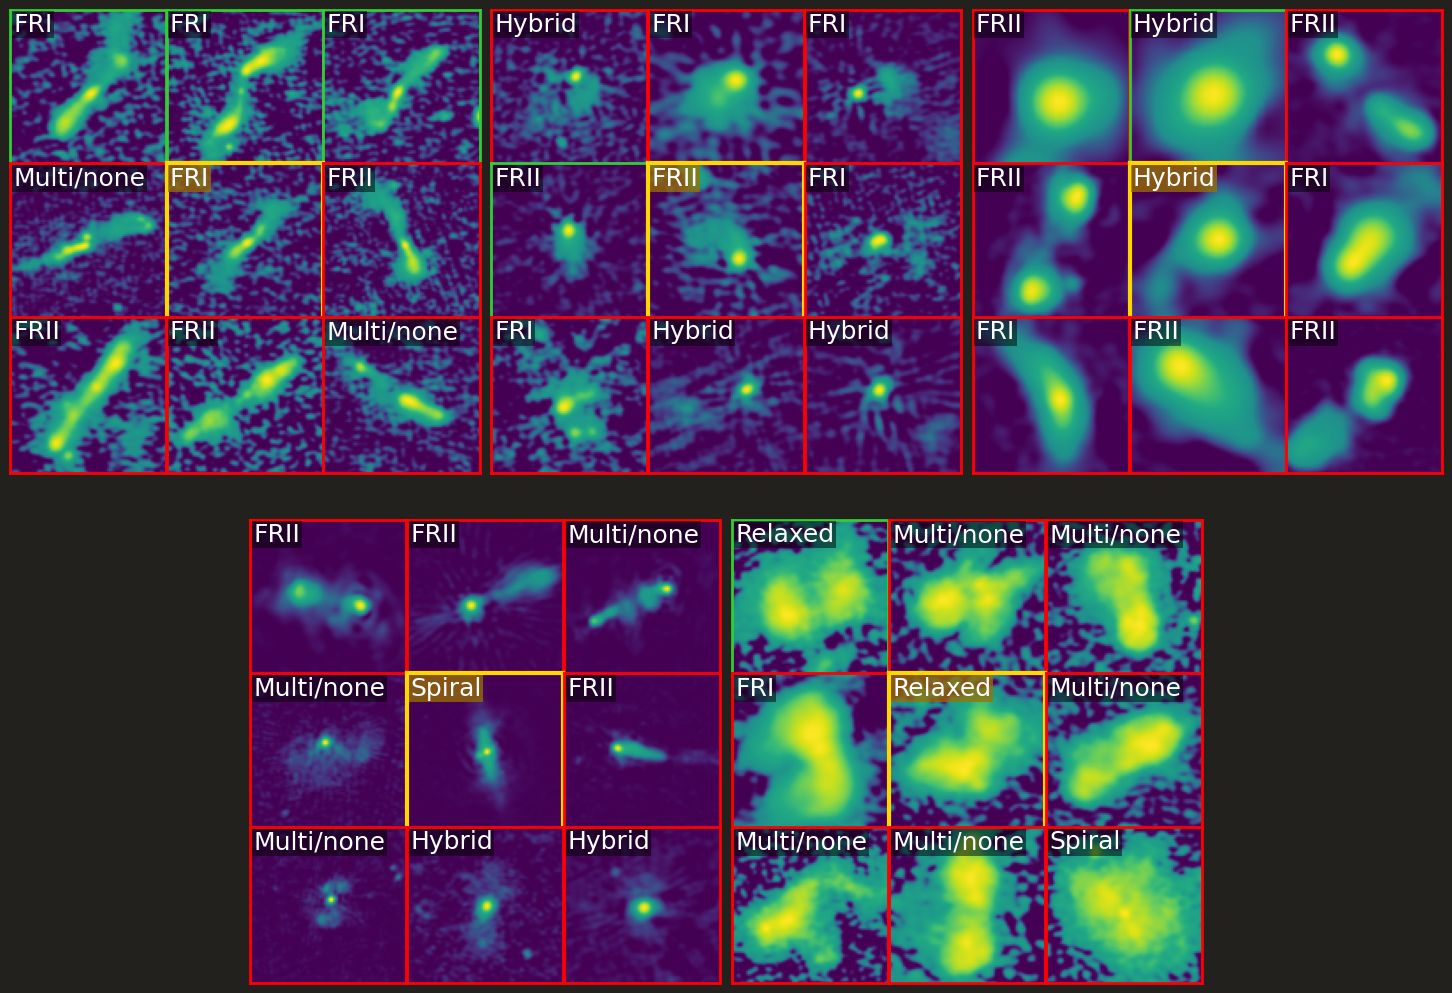

In [10]:
# ── KNN gallery — real images, one query per initial class ────────────────────
# Picks one random test image from each of the 5 initial classes and shows its
# 8 nearest neighbours in the embedding. Layout per class: 3×3 grid with the
# query (gold border) in the centre and 8 neighbours around it.
# Green border = same initial class as query; red = different.

_KNN_SEED = 0
_KNN_K    = 8

# ── Load images and test-split projections ────────────────────────────────────
_imgs_path      = OUTPUTS_ROOT.parent / "data" / "preprocessed" / "lotss" / "images_filtered.npy"
_all_images     = np.load(_imgs_path).astype(np.float32)
if _all_images.max() > 1.5:
    _all_images /= 255.0

_knn_test_idx  = np.load(_splits_dir / "test_idx.npy")
_knn_test_proj = np.load(_byol_dir / "test_projections.npy")
_knn_test_imgs = _all_images[_knn_test_idx]
_knn_test_lbl  = build_initial_labels(_knn_test_idx)   # 0–4 = initial class, 5 = multi/none

# L2-normalise for cosine-equivalent Euclidean KNN
_knn_norms      = np.linalg.norm(_knn_test_proj, axis=1, keepdims=True)
_knn_test_norm  = _knn_test_proj / np.maximum(_knn_norms, 1e-10)

# ── One random pure-class image per initial class ─────────────────────────────
_knn_rng      = np.random.default_rng(_KNN_SEED)
_class_sel    = []
for _ci in range(5):
    _pool = np.where(_knn_test_lbl == _ci)[0]
    if len(_pool) == 0:
        continue
    _class_sel.append((_ci, int(_knn_rng.choice(_pool))))

# ── Fit KNN and find 8 neighbours (K+1 to exclude self at rank 0) ────────────
_nn_model    = _NNR(n_neighbors=_KNN_K + 1, metric="euclidean").fit(_knn_test_norm)
_q_projs     = _knn_test_norm[[qi for _, qi in _class_sel]]
_, _nn_raw   = _nn_model.kneighbors(_q_projs)
_knn_indices = _nn_raw[:, 1:]   # drop self (index 0, distance 0)

# ── Layout helpers (same as generative_modelling KNN gallery) ─────────────────
def _knn_wrap_label(s, max_chars=18):
    parts = [p.strip() for p in s.split(',')]
    lines, cur = [], ''
    for p in parts:
        cand = f'{cur}, {p}' if cur else p
        if len(cand) > max_chars and cur:
            lines.append(cur); cur = p
        else:
            cur = cand
    if cur:
        lines.append(cur)
    return '\n'.join(lines)

N_CLS   = len(_class_sel)
N_TOP   = 3
N_BOT   = N_CLS - N_TOP
SEP     = 6 / 89
CS      = 1.6   # cell_size
BG      = '#23211E'

top_ratios = []
for _i in range(N_TOP):
    top_ratios += [1, 1, 1]
    if _i < N_TOP - 1:
        top_ratios.append(SEP)

_top_total = N_TOP * 3 + (N_TOP - 1) * SEP
_bot_used  = N_BOT * 3 + (N_BOT - 1) * SEP
_pad       = (_top_total - _bot_used) / 2
bot_ratios = [_pad] + sum([[1, 1, 1] + ([SEP] if _i < N_BOT - 1 else []) for _i in range(N_BOT)], []) + [_pad]

_fw  = _top_total * CS
_fh  = (3 * CS + 0.2) * 2 + 0.3
_hsp = (SEP * CS) / (_fh / 2)

fig_knn = plt.figure(figsize=(_fw, _fh), facecolor=BG)
gs_o    = _GridSpec(2, 1, figure=fig_knn, hspace=_hsp)
fig_knn.subplots_adjust(top=0.99, bottom=0.01, left=0.01, right=0.99)
gs_top  = gs_o[0].subgridspec(3, len(top_ratios), wspace=0.005, hspace=-0.2, width_ratios=top_ratios)
gs_bot  = gs_o[1].subgridspec(3, len(bot_ratios), wspace=0.005, hspace=-0.2, width_ratios=bot_ratios)

def _fill_knn_gallery(gs_row, col_offset, query_idx, nn_idxs, class_tag, query_cls):
    grid = [nn_idxs[0], nn_idxs[1], nn_idxs[2],
            nn_idxs[3], None,        nn_idxs[4],
            nn_idxs[5], nn_idxs[6], nn_idxs[7]]
    for flat_pos, ridx in enumerate(grid):
        r  = flat_pos // 3
        c  = col_offset + (flat_pos % 3)
        ax = fig_knn.add_subplot(gs_row[r, c])
        ax.set_facecolor(BG)
        if ridx is None:   # query
            ax.imshow(_knn_test_imgs[query_idx], cmap='viridis', origin='lower')
            for sp in ax.spines.values():
                sp.set_visible(True); sp.set_edgecolor('gold'); sp.set_linewidth(3)
            ax.axis('on'); ax.set_xticks([]); ax.set_yticks([])
            ax.text(0.02, 0.98, _knn_wrap_label(class_tag), transform=ax.transAxes,
                    fontsize=18, color='white', va='top', ha='left', linespacing=1.3,
                    bbox=dict(facecolor='#9a7200', alpha=0.75, pad=1, linewidth=0))
        else:              # neighbour
            ax.imshow(_knn_test_imgs[ridx], cmap='viridis', origin='lower')
            nn_cls  = _knn_test_lbl[ridx]
            nn_name = label_names_subset[nn_cls] if nn_cls < 5 else 'Multi/none'
            bc = 'limegreen' if nn_cls == query_cls else 'red'
            for sp in ax.spines.values():
                sp.set_visible(True); sp.set_edgecolor(bc); sp.set_linewidth(2)
            ax.set_xticks([]); ax.set_yticks([])
            ax.text(0.02, 0.98, _knn_wrap_label(nn_name), transform=ax.transAxes,
                    fontsize=18, color='white', va='top', ha='left', linespacing=1.3,
                    bbox=dict(facecolor='black', alpha=0.5, pad=1, linewidth=0))

for _gi, ((cls_i, qi), nn_row) in enumerate(zip(_class_sel[:N_TOP], _knn_indices[:N_TOP])):
    _fill_knn_gallery(gs_top, _gi * 4, qi, nn_row, label_names_subset[cls_i], cls_i)

for _gi, ((cls_i, qi), nn_row) in enumerate(zip(_class_sel[N_TOP:], _knn_indices[N_TOP:])):
    _fill_knn_gallery(gs_bot, 1 + _gi * 4, qi, nn_row, label_names_subset[cls_i], cls_i)

out_knn = Path(OUT_DIR) / f"knn_gallery_real_{_run_dir.parent.name}.pdf"
fig_knn.savefig(out_knn, bbox_inches="tight", facecolor=BG)
print(f"Saved → {out_knn}")
plt.show()

### 2.4 Retrieval Quality — nDCG@10

Computes nDCG@10 (normalised discounted cumulative gain at rank 10) across all `sw` / `f` combinations as an unsupervised proxy for representation quality, without requiring labelled downstream evaluation.

In [11]:
# ── nDCG@10 sweep — build run_results ────────────────────────────────────────
BYOL_RUNS_ROOT = OUTPUTS_ROOT / "byol_runs"
EVAL_SPLIT     = "test"
NDCG_K         = 10


def nDCGk_avg_fast(proj_norm, lab_in, ref_class, k=20):
    """Vectorized nDCG@k. proj_norm must be L2-normalised."""
    mask      = lab_in[:, ref_class].astype(bool)
    class_idx = np.where(mask)[0]
    n_class   = len(class_idx)
    if n_class == 0:
        return np.nan
    sim = proj_norm[class_idx] @ proj_norm.T
    sim[np.arange(n_class), class_idx] = -np.inf
    order      = np.argsort(-sim, axis=1)
    rel_ranked = mask[order][:, :k].astype(float)
    discount   = 1.0 / np.log2(np.arange(2, k + 2))
    dcg        = (rel_ranked * discount).sum(axis=1)
    n_rel      = min(k, n_class - 1)
    idcg       = discount[:n_rel].sum() if n_rel > 0 else 0.0
    if idcg == 0:
        return 0.0
    return float((dcg / idcg).mean())


def _ci68(vals, axis=None):
    """Return 68% CI half-widths (lo_err, hi_err) relative to the mean.

    lo_err = mean - p16,  hi_err = p84 - mean.
    Falls back to (std, std) when n < 2, printing a notice.
    Works on lists or numpy arrays; axis= is forwarded to np operations.
    """
    arr = np.asarray(vals, dtype=float)
    n = arr.shape[axis] if axis is not None else arr.size
    if n < 2:
        s = float(arr.std(axis=axis)) if axis is not None else float(np.std(arr))
        print(f"  [CI68 fallback] n={n} sample(s): using std instead of 68% CI")
        return s, s
    mean = arr.mean(axis=axis)
    p16  = np.percentile(arr, 16, axis=axis)
    p84  = np.percentile(arr, 84, axis=axis)
    return mean - p16, p84 - mean


# Derive family glob from checkpoint run name (same pattern as UMAP sweep)
_family_glob = re.sub(r'_sw[\d.]+_f[\d.]+', '_sw*_f*', _run_dir.parent.parent.name)
_family_glob = re.sub(r'_\d{8}_\d{4}$', '_*', _family_glob)
_family_dirs = sorted((BYOL_RUNS_ROOT / "byol_runs").glob(_family_glob))
print(f"Family glob : {_family_glob}")
print(f"Family dirs : {len(_family_dirs)}")

run_dirs = []
for fd in _family_dirs:
    diag = _get_seed_dirs(fd)
    if diag:
        run_dirs.extend(diag)
print(f"Run dirs    : {len(run_dirs)}")

run_results = []
_first_rd = None
for rd in run_dirs:
    _name_for_regex = rd.parent.parent.name
    m = re.search(r'_sw([\d.]+)_f([\d.]+)', _name_for_regex)
    if not m:
        continue
    sw_val = float(m.group(1))
    f_val  = float(m.group(2))

    proj_path = rd / "data" / "byol" / f"{EVAL_SPLIT}_projections.npy"
    if not proj_path.exists():
        proj_path = rd / "data" / f"{EVAL_SPLIT}_projections.npy"
    if not proj_path.exists():
        print(f"  skip {rd.name}  (missing {EVAL_SPLIT} projections)")
        continue

    try:
        ckpt = torch.load(rd / "byol_model_best.pt", map_location="cpu", weights_only=False)
        _ds  = int(ckpt["config"]["data_seed"])
    except Exception:
        _ds = 42
    labels_path = OUTPUTS_ROOT / "data_splits" / str(_ds) / f"{EVAL_SPLIT}_labels.npy"
    if not labels_path.exists():
        print(f"  skip {rd.name}  (missing labels at {labels_path})")
        continue

    proj   = np.load(proj_path)
    labels = np.load(labels_path)
    if proj.shape[0] != labels.shape[0]:
        test_idx_path = OUTPUTS_ROOT / "data_splits" / str(_ds) / "test_idx.npy"
        if not test_idx_path.exists():
            print(f"  skip {rd.name}  (shape mismatch, no test_idx.npy)")
            continue
        proj = proj[np.load(test_idx_path)]
    if proj.shape[0] != labels.shape[0]:
        print(f"  skip {rd.name}  (shape mismatch after subsetting)")
        continue

    norms     = np.linalg.norm(proj, axis=1, keepdims=True)
    proj_norm = proj / np.maximum(norms, 1e-10)
    ndcg = [nDCGk_avg_fast(proj_norm, labels, c, k=NDCG_K) for c in range(labels.shape[1])]
    run_results.append(dict(name=_name_for_regex, f=f_val, sw=sw_val, ndcg=ndcg))
    if _first_rd is None:
        _first_rd = rd

# Summary
from collections import Counter
_combo_counts = Counter((r['f'], r['sw']) for r in run_results)
if _first_rd is not None:
    print(f"Example     : {_first_rd}")
print(f"\nLoaded {len(run_results)} runs — {len(_combo_counts)} (f, sw) combinations:")
for (f, sw), cnt in sorted(_combo_counts.items()):
    print(f"  f={f:<5}  sw={sw:<5}  ×{cnt}")


Family glob : pd128_qext_v1_wd1e-3_lrconst_sw*_f*
Family dirs : 16
Run dirs    : 68


  skip training_seed_2  (missing test projections)


Example     : ../outputs/byol_runs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.05_f0.05/data_seed_2/training_seed_2

Loaded 67 runs — 16 (f, sw) combinations:
  f=0.05   sw=0.05   ×5
  f=0.05   sw=0.1    ×5
  f=0.1    sw=0.0    ×1
  f=0.1    sw=0.05   ×5
  f=0.1    sw=0.1    ×5
  f=0.1    sw=0.5    ×1
  f=0.1    sw=1.0    ×1
  f=0.25   sw=0.05   ×5
  f=0.25   sw=0.1    ×5
  f=0.5    sw=0.05   ×4
  f=0.5    sw=0.1    ×5
  f=1.0    sw=0.0    ×5
  f=1.0    sw=0.05   ×5
  f=1.0    sw=0.1    ×5
  f=1.0    sw=0.5    ×5
  f=1.0    sw=1.0    ×5


f = 0.05


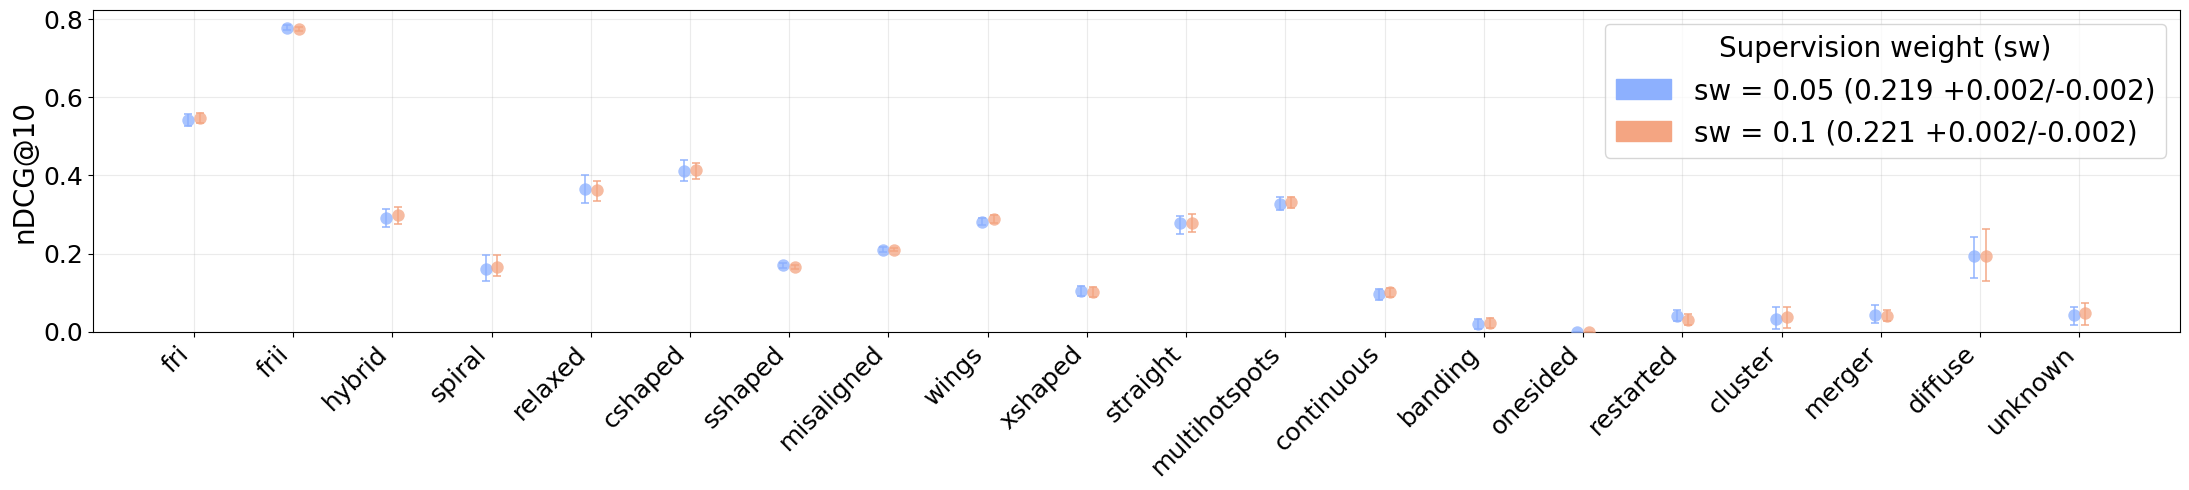

Saved → /users/mbredber/p3_SUPLAT/outputs/figures/classification/ndcg_overview_f0.05.pdf
f = 0.1


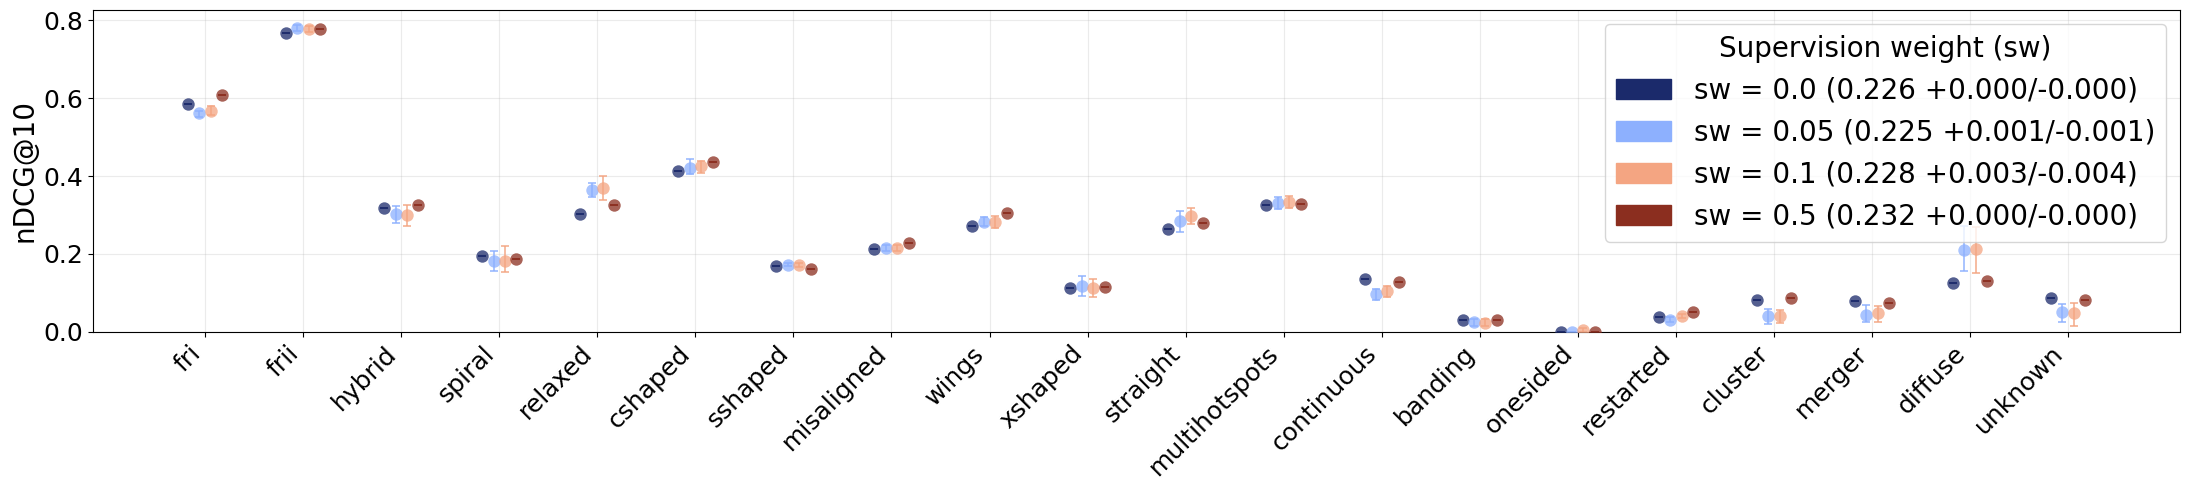

Saved → /users/mbredber/p3_SUPLAT/outputs/figures/classification/ndcg_overview_f0.1.pdf
f = 0.25


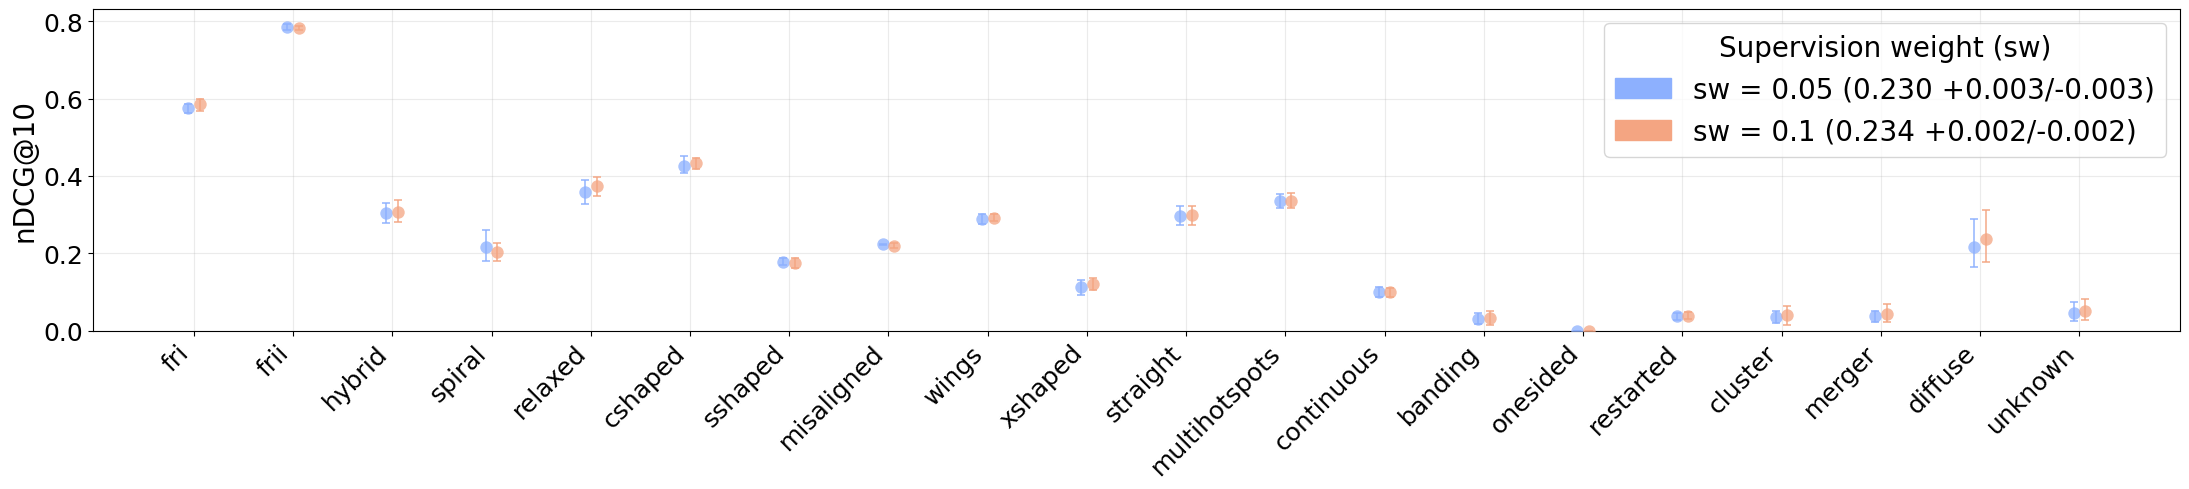

Saved → /users/mbredber/p3_SUPLAT/outputs/figures/classification/ndcg_overview_f0.25.pdf
f = 0.5


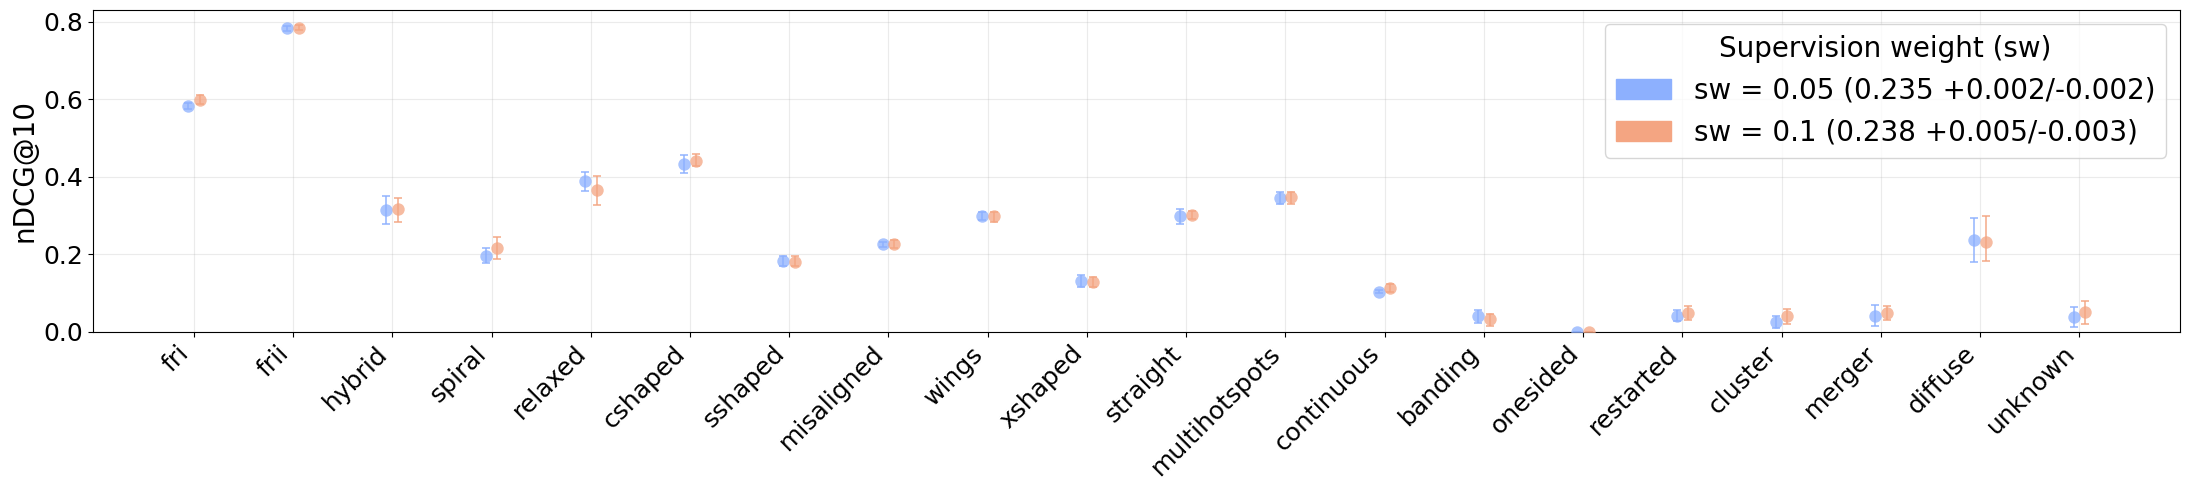

Saved → /users/mbredber/p3_SUPLAT/outputs/figures/classification/ndcg_overview_f0.5.pdf
f = 1


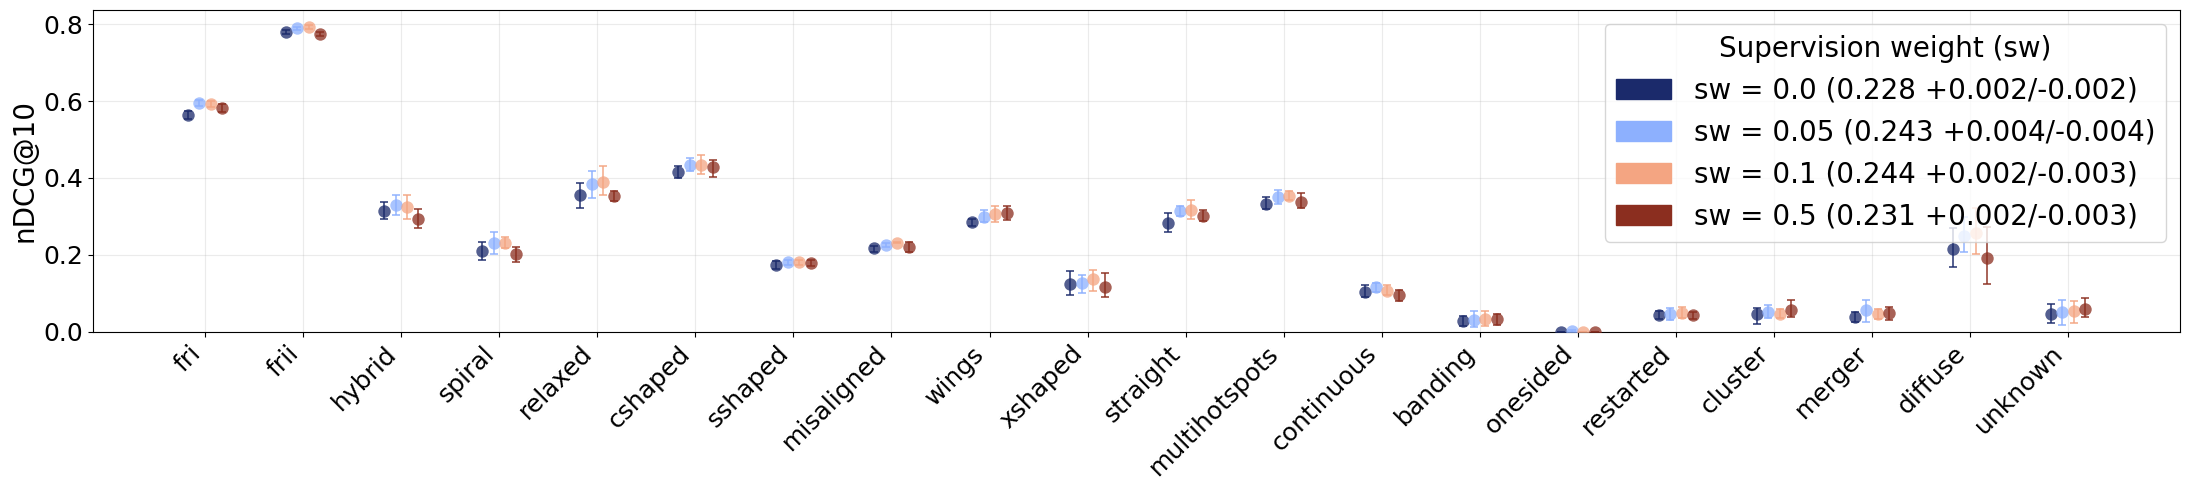

Saved → /users/mbredber/p3_SUPLAT/outputs/figures/classification/ndcg_overview_f1.pdf


In [12]:
_SW_EXCLUDE = {1.0}

f_vals  = sorted(set(r['f']  for r in run_results))
sw_vals = sorted(set(r['sw'] for r in run_results if r['sw'] not in _SW_EXCLUDE))

if not run_results:
    print("No run results found — skipping nDCG plot.")
else:
    sw_color = {sw: _SW_PALETTE[i % len(_SW_PALETTE)] for i, sw in enumerate(sw_vals)}

    _fig_dir = Path(OUT_DIR)
    _fig_dir.mkdir(parents=True, exist_ok=True)

    S, ALPHA = 80, 0.75
    LFS, AFS, TFS = 20, 20, 18   # legend, axis-label, tick font sizes

    _n_cls     = len(run_results[0]['ndcg'])
    x          = np.arange(_n_cls)
    _n_sw      = len(sw_vals)
    _dodge_max = 0.35
    _offsets   = np.linspace(-_dodge_max / 2, _dodge_max / 2, _n_sw) if _n_sw > 1 else [0.0]
    sw_offset  = {sw: _offsets[i] for i, sw in enumerate(sw_vals)}

    _cls_names = LABEL_COLS if 'LABEL_COLS' in vars() else [str(i) for i in range(_n_cls)]

    for f_val in f_vals:
        print(f"f = {f_val:g}")
        fig, ax = plt.subplots(figsize=(_n_cls * 1.1, 5))

        sw_handles = []
        for sw in sw_vals:
            seeds = [r['ndcg'] for r in run_results
                     if r['f'] == f_val and r['sw'] == sw]
            if not seeds:
                continue
            color  = sw_color[sw]
            dx     = sw_offset[sw]
            xpos   = x + dx
            mat    = np.array(seeds)          # (n_seeds, n_cls)
            mean   = np.nanmean(mat, axis=0)
            lo     = mean - np.nanpercentile(mat, 16, axis=0)
            hi     = np.nanpercentile(mat, 84, axis=0) - mean

            _sw_mean = float(np.nanmean(mean))
            if mat.shape[0] > 1:
                _psm   = np.nanmean(mat, axis=1)
                _sw_lo = float(np.nanmean(_psm) - np.nanpercentile(_psm, 16))
                _sw_hi = float(np.nanpercentile(_psm, 84) - np.nanmean(_psm))
            else:
                _sw_lo, _sw_hi = 0.0, 0.0
            _sw_label = f"sw = {sw} ({_sw_mean:.3f} +{_sw_hi:.3f}/-{_sw_lo:.3f})"
            sw_handles.append(mpatches.Patch(color=color, label=_sw_label))

            ax.errorbar(xpos, mean, yerr=[lo, hi],
                        fmt='none', ecolor=color, elinewidth=1.4,
                        capsize=3, capthick=1.4, zorder=2, alpha=ALPHA)
            ax.scatter(xpos, mean, color=color,
                       marker='o', s=S, linewidths=0, zorder=3, alpha=ALPHA)

        ax.set_ylabel("nDCG@10", fontsize=AFS)
        ax.set_ylim([0, None])
        ax.set_xticks(x)
        ax.set_xticklabels(_cls_names[:_n_cls], rotation=45, ha='right', fontsize=TFS)
        ax.tick_params(axis='y', labelsize=TFS)
        ax.grid(True, alpha=0.25)
        ax.legend(handles=sw_handles, title='Supervision weight (sw)',
                  loc='upper right', framealpha=0.8, fontsize=LFS, title_fontsize=LFS)

        plt.tight_layout()
        _fname = f"ndcg_overview_f{f_val:g}.pdf"
        fig.savefig(_fig_dir / _fname, bbox_inches="tight")
        plt.show()
        print(f"Saved → {_fig_dir / _fname}")

In [13]:
# ── Mean nDCG@10 per sw (averaged across classes and seeds) ──────────────────
print(f"{'f':>6}  {'sw':>6}  {'mean nDCG@10':>14}  {'68% CI':>16}  {'seeds':>6}")
print("-" * 58)
for f_val in f_vals:
    for sw in sw_vals:
        seeds = [r['ndcg'] for r in run_results
                 if r['f'] == f_val and r['sw'] == sw and r['sw'] not in _SW_EXCLUDE]
        if not seeds:
            continue
        mat             = np.array(seeds)           # (n_seeds, n_cls)
        per_seed_means  = np.nanmean(mat, axis=1)   # (n_seeds,)
        mean            = float(np.nanmean(per_seed_means))
        if len(per_seed_means) > 1:
            lo, hi = _ci68(per_seed_means)
            ci_str = f"+{hi:.4f}/-{lo:.4f}"
        else:
            ci_str = "n/a"
        print(f"{f_val:>6g}  {sw:>6g}  {mean:>14.4f}  {ci_str:>16}  {len(seeds):>6d}")


     f      sw    mean nDCG@10            68% CI   seeds
----------------------------------------------------------
  0.05    0.05          0.2193   +0.0019/-0.0023       5
  0.05     0.1          0.2205   +0.0024/-0.0019       5
   0.1       0          0.2256               n/a       1
   0.1    0.05          0.2253   +0.0012/-0.0012       5
   0.1     0.1          0.2276   +0.0030/-0.0040       5
   0.1     0.5          0.2324               n/a       1
  0.25    0.05          0.2303   +0.0034/-0.0033       5
  0.25     0.1          0.2336   +0.0024/-0.0021       5
   0.5    0.05          0.2351   +0.0017/-0.0017       4
   0.5     0.1          0.2384   +0.0048/-0.0034       5
     1       0          0.2285   +0.0021/-0.0021       5
     1    0.05          0.2433   +0.0036/-0.0044       5
     1     0.1          0.2440   +0.0025/-0.0025       5
     1     0.5          0.2313   +0.0024/-0.0025       5


  pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1  sw=0.05  macro-nDCG@10=0.245


  pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1  sw=0.05  macro-nDCG@10=0.250


  pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1  sw=0.05  macro-nDCG@10=0.240


  pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1  sw=0.05  macro-nDCG@10=0.237


  pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1  sw=0.05  macro-nDCG@10=0.244


...

  pd128_qext_v1_wd1e-3_lrconst_sw0.5_f1  sw=0.5  macro-nDCG@10=0.230


  pd128_qext_v1_wd1e-3_lrconst_sw0.5_f1  sw=0.5  macro-nDCG@10=0.237


  pd128_qext_v1_wd1e-3_lrconst_sw0.5_f1  sw=0.5  macro-nDCG@10=0.231


  pd128_qext_v1_wd1e-3_lrconst_sw0.5_f1  sw=0.5  macro-nDCG@10=0.232


  pd128_qext_v1_wd1e-3_lrconst_sw0.5_f1  sw=0.5  macro-nDCG@10=0.227

Collected curves for 4 sw value(s).


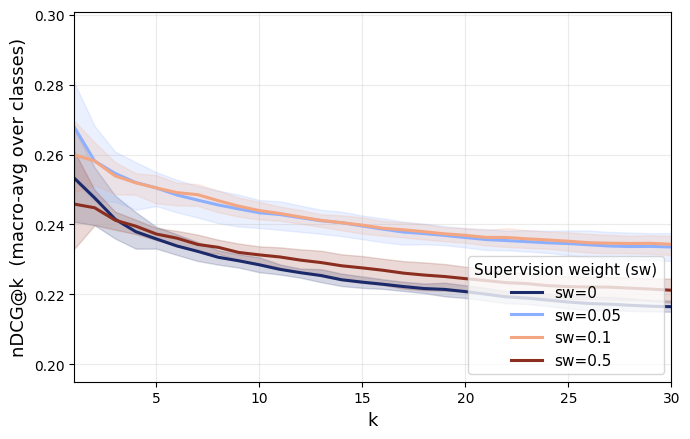

Saved → /users/mbredber/p3_SUPLAT/outputs/figures/classification/ndcg_vs_k_f1.png


In [14]:
# ── nDCG@k vs k curve — macro-avg over initial classes ───────────────────────
# Re-loads projections and computes nDCG for k=1..30, then plots one line per
# sw value (macro-averaged over all initial classes and seeds).
# Only f_label=1 runs are shown.

_K_VALUES_CLS = list(range(1, 31))   # k = 1 … 30


def _nDCGk_avg_vs_k(proj_norm, lab_in, ref_class, k_values):
    """nDCG@k for multiple k values (one class). proj_norm must be L2-normalised.
    Computes similarity matrix once, then reads off all k. Returns (K,) array."""
    mask      = lab_in[:, ref_class].astype(bool)
    class_idx = np.where(mask)[0]
    n_class   = len(class_idx)
    if n_class == 0:
        return np.full(len(k_values), np.nan)
    k_max = max(k_values)
    sim = proj_norm[class_idx] @ proj_norm.T
    sim[np.arange(n_class), class_idx] = -np.inf
    order      = np.argsort(-sim, axis=1)[:, :k_max]     # (n_class, k_max)
    rel_ranked = mask.astype(float)[order]                # (n_class, k_max)
    results = []
    for k in k_values:
        disc  = 1.0 / np.log2(np.arange(2, k + 2))
        n_rel = min(k, n_class - 1)
        idcg  = disc[:n_rel].sum() if n_rel > 0 else 0.0
        if idcg == 0:
            results.append(0.0)
            continue
        dcg = (rel_ranked[:, :k] * disc).sum(axis=1)
        results.append(float((dcg / idcg).mean()))
    return np.array(results)


def _nDCGk_macro_vs_k(proj_norm, labels, k_values):
    """Macro-avg nDCG over all initial classes for each k. Returns (K,) array."""
    rows = [_nDCGk_avg_vs_k(proj_norm, labels, c, k_values)
            for c in range(labels.shape[1])]
    return np.nanmean(np.array(rows), axis=0)


# ── Re-load projections and compute curves (f=1 only) ────────────────────────
# Keyed by sw → list of (K,) arrays (one per seed/run)
_k_curves = {}

for rd in run_dirs:
    _name_for_regex = rd.parent.parent.name
    m = re.search(r'_sw([\d.]+)_f([\d.]+)', _name_for_regex)
    if not m:
        continue
    sw_val = float(m.group(1))
    f_val  = float(m.group(2))
    if sw_val in _SW_EXCLUDE or abs(f_val - 1.0) > 1e-9:
        continue

    proj_path = rd / "data" / "byol" / f"{EVAL_SPLIT}_projections.npy"
    if not proj_path.exists():
        proj_path = rd / "data" / f"{EVAL_SPLIT}_projections.npy"
    if not proj_path.exists():
        continue

    try:
        ckpt = torch.load(rd / "byol_model_best.pt", map_location="cpu", weights_only=False)
        _ds  = int(ckpt["config"]["data_seed"])
    except Exception:
        _ds = 42
    labels_path = OUTPUTS_ROOT / "data_splits" / str(_ds) / f"{EVAL_SPLIT}_labels.npy"
    if not labels_path.exists():
        continue

    proj   = np.load(proj_path)
    labels = np.load(labels_path)
    if proj.shape[0] != labels.shape[0]:
        test_idx_path = OUTPUTS_ROOT / "data_splits" / str(_ds) / "test_idx.npy"
        if not test_idx_path.exists():
            continue
        proj = proj[np.load(test_idx_path)]
    if proj.shape[0] != labels.shape[0]:
        continue

    norms     = np.linalg.norm(proj, axis=1, keepdims=True)
    proj_norm = proj / np.maximum(norms, 1e-10)

    curve = _nDCGk_macro_vs_k(proj_norm, labels, _K_VALUES_CLS)
    _k_curves.setdefault(sw_val, []).append(curve)
    print(f"  {_name_for_regex}  sw={sw_val:g}  macro-nDCG@{NDCG_K}={curve[NDCG_K - 1]:.3f}")

print(f"\nCollected curves for {len(_k_curves)} sw value(s).")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))

_all_vals = []
for sw in sorted(_k_curves):
    arr   = np.array(_k_curves[sw])   # (n_seeds, K)
    mean  = arr.mean(axis=0)
    color = sw_color.get(sw, "grey")
    ax.plot(_K_VALUES_CLS, mean, color=color, lw=2.2, label=f"sw={sw:g}")
    if len(arr) > 1:
        _lo = np.percentile(arr, 16, axis=0)
        _hi = np.percentile(arr, 84, axis=0)
        ax.fill_between(_K_VALUES_CLS, _lo, _hi, color=color, alpha=0.18)
        _all_vals.extend(_lo.tolist() + _hi.tolist())
    _all_vals.extend(mean.tolist())

ax.set_xlabel('k', fontsize=13)
ax.set_ylabel('nDCG@k  (macro-avg over classes)', fontsize=13)
ax.set_xlim(1, max(_K_VALUES_CLS))
if _all_vals:
    _ymin = max(0.0, min(_all_vals) - 0.02)
    _ymax = min(1.0, max(_all_vals) + 0.02)
    ax.set_ylim(_ymin, _ymax)
ax.legend(title='Supervision weight (sw)', fontsize=11, title_fontsize=11,
          loc='lower right', framealpha=0.8)
ax.grid(True, alpha=0.25)
plt.tight_layout()

_fname = f"ndcg_vs_k_f1.png"
fig.savefig(_fig_dir / _fname, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {_fig_dir / _fname}")

## 3. Downstream Classifiers

Fits LR, RF, and KNN classifiers on frozen BYOL projections and reports test-set metrics on the configured eval label set.

Results are loaded from `data/classifiers/simple_downstream/` when available; missing classifiers are trained on the fly (pure label sets only). Cross-evaluation metrics (when `eval_label_set ≠ train_label_set`) are derived from `test_probs.npy` and cached as `{clf}_projections_{eval_label_set}_eval.json`.

In [15]:
def run_linear_probe(cache_entry, n_classes):
    """Fit logistic regression on train projections, report val & test metrics.

    Val is optional — skipped when split_ids contains no 1s (e.g. BYOL split).
    Returns dict with keys "test" (and "val" if present), plus "clf" and "scaler".
    """
    projs     = cache_entry["projs"]
    labels    = cache_entry["labels"]
    split_ids = cache_entry["split_ids"]

    X = {s: projs[split_ids == i]  for s, i in [("train",0),("val",1),("test",2)]}
    y = {s: labels[split_ids == i] for s, i in [("train",0),("val",1),("test",2)]}

    scaler     = StandardScaler()
    X["train"] = scaler.fit_transform(X["train"])
    if len(X["val"]):
        X["val"] = scaler.transform(X["val"])
    X["test"]  = scaler.transform(X["test"])

    clf = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
    clf.fit(X["train"], y["train"])

    results = {}
    for split in ("val", "test"):
        if len(X[split]) == 0:
            continue
        y_pred = clf.predict(X[split])
        y_prob = clf.predict_proba(X[split])
        acc    = accuracy_score(y[split], y_pred)
        f1     = f1_score(y[split], y_pred, average="macro", zero_division=0)
        rec    = recall_score(y[split], y_pred, average="macro", zero_division=0)
        if n_classes == 2:
            auc = roc_auc_score(y[split], y_prob[:, 1])
        else:
            auc = roc_auc_score(
                label_binarize(y[split], classes=list(range(n_classes))),
                y_prob, multi_class="ovr", average="macro",
            )
        results[split] = {"accuracy": acc, "f1": f1, "recall": rec, "auc": auc, "n": len(y[split])}

    results["clf"]    = clf
    results["scaler"] = scaler
    return results


In [16]:
def run_classifier_suite(cache_entry, n_classes,
                         n_neighbors=15, n_estimators=200):
    """
    Train KNN and Random Forest on train-split BYOL projections.
    Returns dict keyed by classifier name, each with accuracy/f1/recall/auc/n.
    """
    projs     = cache_entry["projs"]
    labels    = cache_entry["labels"]
    split_ids = cache_entry["split_ids"]

    X = {s: projs[split_ids == i]  for s, i in [("train", 0), ("val", 1), ("test", 2)]}
    y = {s: labels[split_ids == i] for s, i in [("train", 0), ("val", 1), ("test", 2)]}

    scaler     = StandardScaler()
    X["train"] = scaler.fit_transform(X["train"])
    if len(X["val"]):
        X["val"] = scaler.transform(X["val"])
    X["test"]  = scaler.transform(X["test"])

    def _metrics(y_true, y_pred, y_prob):
        acc = accuracy_score(y_true, y_pred)
        f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)
        rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
        if n_classes == 2:
            auc = roc_auc_score(y_true, y_prob[:, 1])
        else:
            auc = roc_auc_score(
                label_binarize(y_true, classes=list(range(n_classes))),
                y_prob, multi_class="ovr", average="macro",
            )
        return {"accuracy": acc, "f1": f1, "recall": rec, "auc": auc, "n": len(y_true)}

    results = {}

    # ── KNN ──────────────────────────────────────────────────────────────────
    print("  KNN...", end=" ", flush=True)
    knn = KNeighborsClassifier(n_neighbors=n_neighbors, metric="euclidean", n_jobs=-1)
    knn.fit(X["train"], y["train"])
    y_pred = knn.predict(X["test"])
    y_prob = knn.predict_proba(X["test"])
    results["knn"] = _metrics(y["test"], y_pred, y_prob)
    print(f"F1={results['knn']['f1']:.3f}")

    # ── Random Forest ─────────────────────────────────────────────────────────
    print("  Random Forest...", end=" ", flush=True)
    rf = RandomForestClassifier(n_estimators=n_estimators, random_state=SEED, n_jobs=-1)
    rf.fit(X["train"], y["train"])
    y_pred = rf.predict(X["test"])
    y_prob = rf.predict_proba(X["test"])
    results["random_forest"] = _metrics(y["test"], y_pred, y_prob)
    print(f"F1={results['random_forest']['f1']:.3f}")

    return results


In [17]:
_tls = CONFIG["train_label_set"]
_els = CONFIG["eval_label_set"]
_cw     = CONFIG.get("class_weight", "")
_cw_tag = f"cw{_cw}" if _cw else "cwNone"

_PURE_SETS_XEVAL = {"initial_pure", "classical_pure", "morphology_pure", "environment_pure", "full_pure"}

def _cross_eval_metrics(probs, labels_20, train_ls, eval_ls):
    """Compute eval_ls metrics from probs trained on train_ls.
    probs     : (N, n_train_classes)
    labels_20 : (N, 20)  full multi-hot labels
    """
    from sklearn.metrics import (f1_score as _f1s, roc_auc_score as _aucs,
                                  accuracy_score as _accs, recall_score as _recs)
    from sklearn.preprocessing import label_binarize as _lb

    _train_cols = LABEL_SETS[train_ls]
    _eval_cols  = LABEL_SETS[eval_ls]

    # Map eval columns into probe output space
    _col_map = [_train_cols.index(c) for c in _eval_cols if c in _train_cols]
    if len(_col_map) != len(_eval_cols):
        raise ValueError(f"eval_label_set '{eval_ls}' contains classes not in train_label_set '{train_ls}'")

    _p = probs[:, _col_map]       # (N, n_eval_classes)
    _y = labels_20[:, _eval_cols] # (N, n_eval_classes)

    if eval_ls in _PURE_SETS_XEVAL:
        _mask = _y.sum(axis=1) == 1
        _p, _y = _p[_mask], _y[_mask]
        if len(_p) == 0:
            raise ValueError("No pure-set rows after filtering")
        _p_norm  = _p / _p.sum(axis=1, keepdims=True).clip(min=1e-9)
        _y_int   = _y.argmax(axis=1)
        _yp_int  = _p_norm.argmax(axis=1)
        _n_cls   = _p.shape[1]
        try:
            _auc_v = _aucs(_lb(_y_int, classes=list(range(_n_cls))),
                           _p_norm, multi_class="ovr", average="macro")
        except Exception:
            _auc_v = float("nan")
        return {"f1_macro": float(_f1s(_y_int, _yp_int, average="macro", zero_division=0)),
                "auc_macro": _auc_v,
                "accuracy":  float(_accs(_y_int, _yp_int)),
                "recall_macro": float(_recs(_y_int, _yp_int, average="macro", zero_division=0)),
                "n_test": int(len(_p))}
    else:
        _yp = (_p >= 0.5).astype(int)
        try:
            _auc_cols = [_aucs(_y[:, i], _p[:, i])
                         for i in range(_y.shape[1]) if len(np.unique(_y[:, i])) >= 2]
            _auc_v = float(np.mean(_auc_cols)) if _auc_cols else float("nan")
        except Exception:
            _auc_v = float("nan")
        # _binary sets: element-wise accuracy (each label column independently)
        _acc = float((_y == _yp).mean()) if eval_ls.endswith("_binary") else float(_accs(_y, _yp))
        return {"f1_macro": float(_f1s(_y, _yp, average="macro", zero_division=0)),
                "auc_macro": _auc_v,
                "accuracy":  _acc,
                "recall_macro": float(_recs(_y, _yp, average="macro", zero_division=0)),
                "n_test": int(len(_p))}

In [18]:
_run_dir   = Path(CONFIG["checkpoint"]).parent
_feat      = "projections"
_tls       = CONFIG["train_label_set"]   # where classifier files live
_els       = CONFIG["eval_label_set"]    # which label set metrics are shown for
_cw     = CONFIG.get("class_weight", "")
_cw_tag = f"cw{_cw}" if _cw else "cwNone"
_cache_key = f"lotss_{_els}"

# ── Resolve fold dirs (CV) or single run dir (non-CV) ────────────────────────
_fold_dirs_24 = _get_fold_dirs(_run_dir)
_n_folds      = len(_fold_dirs_24)

def _fd_clf_dir(fd):
    _n = fd / "data" / "classifiers" / "simple_downstream" / f"{_tls}_{_cw_tag}"
    _o = fd / "data" / "classifiers" / "simple_downstream" / _tls
    return _n if _n.exists() else _o

# _clf_dir → first fold (used by §3.1 encodings cell)
_clf_dir = _fd_clf_dir(_fold_dirs_24[0])

print(f"Path : {_clf_dir}  ({'CV — ' + str(_n_folds) + ' folds' if _n_folds > 1 else 'non-CV'})")
print(f"Eval : {_els}  (classifiers trained on '{_tls}')")

suite_results = {_cache_key: {}}

# ── Load pre-computed results (mean across folds for CV) ──────────────────────
for _clf_name, _suite_key in [("rf", "random_forest"), ("knn", "knn"), ("lr", "lr")]:
    _fold_jsons = []
    for _fd in _fold_dirs_24:
        _jp = (_fd_clf_dir(_fd) / (f"{_clf_name}_{_feat}.json" if _tls == _els
                                   else f"{_clf_name}_{_feat}_{_els}_eval.json"))
        if _jp.exists():
            with open(_jp) as _f:
                _fold_jsons.append(json.load(_f))
    if _fold_jsons:
        _r = {
            "f1":       float(np.mean([d["f1_macro"]     for d in _fold_jsons])),
            "auc":      float(np.mean([d["auc_macro"]    for d in _fold_jsons])),
            "accuracy": float(np.mean([d["accuracy"]     for d in _fold_jsons])),
            "recall":   float(np.mean([d["recall_macro"] for d in _fold_jsons])),
            "n":        float(np.mean([d.get("n_test", float("nan")) for d in _fold_jsons])),
        }
        suite_results[_cache_key][_suite_key] = _r
        _sfx = f" (mean {len(_fold_jsons)}/{_n_folds} folds)" if _n_folds > 1 else ""
        print(f"  {_clf_name.upper()}: F1={_r['f1']:.3f}  AUC={_r['auc']:.3f}  Acc={_r['accuracy']:.3f}{_sfx}")
    else:
        print(f"  {_clf_name.upper()}: not found in any fold")

# ── Linear probe (LR) ─────────────────────────────────────────────────────────
_need_suite = [k for k in ("knn", "random_forest") if k not in suite_results[_cache_key]]
if _need_suite:
    print(f"  {_need_suite} not found in any fold — run train_byol_classifiers.py --cv-fold K")
if "lr" not in suite_results[_cache_key]:
    print(f"  LR not found — run train_byol_classifiers.py to generate JSON results.")
if "lr" in suite_results[_cache_key]:
    _lr = suite_results[_cache_key]["lr"]
    if "f1" in _lr:
        print(f"  LR (linear probe): F1={_lr['f1']:.3f}  AUC={_lr['auc']:.3f}  Acc={_lr['accuracy']:.3f}")
    else:
        print(f"  LR (linear probe): result incomplete — missing keys: {sorted(set(['f1','auc','accuracy']) - set(_lr))}")
        del suite_results[_cache_key]["lr"]

# ── Multi-run summary (RF) ────────────────────────────────────────────────────
_multirun_dir = _clf_dir / f"multirun_{_tls}_{_feat}"
_summary_path = _multirun_dir / "run_summary.json"
if _summary_path.exists():
    with open(_summary_path) as _f:
        _mr = json.load(_f)
    suite_results[_cache_key]["random_forest_multirun"] = {
        "f1":       _mr["f1_macro_mean"],
        "auc":      _mr["auc_macro_mean"],
        "accuracy": _mr["accuracy_mean"],
        "recall":   _mr["recall_macro_mean"],
        "f1_std":   _mr.get("f1_macro_std"),
        "n_runs":   _mr.get("n_runs", "?"),
    }
    _top5 = _mr.get("top5_ensemble", {})
    print(f"  RF ({_mr['n_runs']} runs): "
          f"F1={_mr['f1_macro_mean']:.3f}±{_mr.get('f1_macro_std', float('nan')):.3f}  "
          f"AUC={_mr['auc_macro_mean']:.3f}")
    if _top5:
        print(f"  RF top-5 ensemble: F1={_top5['f1_macro']:.3f}  AUC={_top5['auc_macro']:.3f}")

Path : ../outputs/byol_runs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1/data_seed_2/training_seed_2/cross_val_0/data/classifiers/simple_downstream/initial_pure_cwNone  (CV — 5 folds)
Eval : initial_pure  (classifiers trained on 'initial_pure')


  RF: F1=0.639  AUC=0.939  Acc=0.816 (mean 5/5 folds)
  KNN: F1=0.657  AUC=0.905  Acc=0.814 (mean 5/5 folds)


  LR: F1=0.718  AUC=0.946  Acc=0.837 (mean 5/5 folds)
  LR (linear probe): F1=0.718  AUC=0.946  Acc=0.837


### 3.1 Encodings vs Projections

Repeats the downstream evaluation using raw encoder output (before the projection head) to quantify how much the projection head contributes to downstream classification quality.

In [19]:
# ── Encodings vs Projections comparison ──────────────────────────────────────
# Loads encoder-output features and runs the same LR / KNN / RF classifiers,
# then plots a side-by-side comparison with the projections results from above.

_feat_enc = "encodings"
_enc_results = {}

_X_tr_enc = np.load(_byol_dir / f"labelled_train_{_feat_enc}.npy").astype(np.float32)
_X_te_enc = np.load(_byol_dir / f"test_{_feat_enc}.npy").astype(np.float32)
print(f"Encodings dim : {_X_tr_enc.shape[1]}   Projections dim : {_X_train.shape[1]}")

# Load pre-computed JSONs if available, otherwise train on site
for _clf_name, _suite_key in [("lr", "lr"), ("knn", "knn"), ("rf", "random_forest")]:
    if _tls == _els:
        _json_path = _clf_dir / f"{_clf_name}_{_feat_enc}.json"
    else:
        _json_path = _clf_dir / f"{_clf_name}_{_feat_enc}_{_els}_eval.json"
    if _json_path.exists():
        with open(_json_path) as _f:
            _d = json.load(_f)
        _enc_results[_suite_key] = {
            "f1": _d["f1_macro"], "auc": _d["auc_macro"],
            "accuracy": _d["accuracy"], "recall": _d["recall_macro"],
        }
        print(f"  {_clf_name.upper()} (enc, loaded): F1={_d['f1_macro']:.3f}  AUC={_d['auc_macro']:.3f}")

_missing_enc = [k for k in ("lr", "knn", "random_forest") if k not in _enc_results]
if _missing_enc:
    print(f"  Training on site for encodings: {_missing_enc}...")

# ── Side-by-side bar chart ────────────────────────────────────────────────────
_metrics_show = [("f1", "Macro F1"), ("auc", "Macro AUC"), ("accuracy", "Accuracy")]
_clfs_show    = [("lr", "LR"), ("knn", "KNN"), ("random_forest", "RF")]
_clfs_avail   = [(k, lbl) for k, lbl in _clfs_show
                 if k in suite_results[_cache_key] and k in _enc_results]

if _clfs_avail:
    _n_metrics = len(_metrics_show)
    _n_clfs    = len(_clfs_avail)
    fig, axes  = plt.subplots(1, _n_metrics, figsize=(4.5 * _n_metrics, 4.0), sharey=False)
    if _n_metrics == 1:
        axes = [axes]

    _bar_w  = 0.35
    _x      = np.arange(_n_clfs)
    _colors = {"projections": "#4c72b0", "encodings": "#dd8452"}

    for _ax, (mkey, mlabel) in zip(axes, _metrics_show):
        _proj_vals = [suite_results[_cache_key][k].get(mkey, float("nan")) for k, _ in _clfs_avail]
        _enc_vals  = [_enc_results[k].get(mkey, float("nan"))              for k, _ in _clfs_avail]

        _ax.bar(_x - _bar_w / 2, _proj_vals, _bar_w,
                label="Projections", color=_colors["projections"], alpha=0.85)
        _ax.bar(_x + _bar_w / 2, _enc_vals,  _bar_w,
                label="Encodings",   color=_colors["encodings"],   alpha=0.85)

        for _xi, (_pv, _ev) in enumerate(zip(_proj_vals, _enc_vals)):
            _ax.text(_xi - _bar_w / 2, _pv + 0.005, f"{_pv:.3f}", ha="center", va="bottom", fontsize=9)
            _ax.text(_xi + _bar_w / 2, _ev + 0.005, f"{_ev:.3f}", ha="center", va="bottom", fontsize=9)

        _all_vals = [v for v in _proj_vals + _enc_vals if not np.isnan(v)]
        _ymin = max(0, min(_all_vals) - 0.08) if _all_vals else 0
        _ymax = min(1, max(_all_vals) + 0.06) if _all_vals else 1
        _ax.set_ylim(_ymin, _ymax)
        _ax.set_xticks(_x)
        _ax.set_xticklabels([lbl for _, lbl in _clfs_avail])
        _ax.set_title(mlabel, fontsize=13)
        _ax.set_ylabel(mlabel, fontsize=11)
        if _ax is axes[0]:
            _ax.legend(fontsize=10)
        _ax.grid(axis="y", alpha=0.35)

    fig.suptitle(f"Encodings vs Projections — {_els} (train: {_tls})", fontsize=14)
    plt.tight_layout()
    _enc_out = Path(OUT_DIR) / f"enc_vs_proj_{_run_dir.parent.parent.name}_{_els}.pdf"
    fig.savefig(_enc_out, bbox_inches="tight")
    print(f"Saved → {_enc_out}")
    plt.show()
else:
    print("No classifiers available for both feature types — skipping comparison plot.")

# ── Summary table ─────────────────────────────────────────────────────────────
_metrics_tbl = [("f1", "Macro F1"), ("auc", "Macro AUC"), ("accuracy", "Accuracy")]
_clfs_tbl    = [("lr", "LR"), ("knn", "KNN"), ("random_forest", "RF")]

_tbl_rows = []
for _clf_k, _clf_lbl in _clfs_tbl:
    _proj = suite_results[_cache_key].get(_clf_k, {})
    _enc  = _enc_results.get(_clf_k, {})
    _row  = {"Classifier": _clf_lbl}
    for _mkey, _mlbl in _metrics_tbl:
        _row[("Projections", _mlbl)] = f"{_proj[_mkey]:.3f}" if _mkey in _proj else "—"
        _row[("Encodings",   _mlbl)] = f"{_enc[_mkey]:.3f}"  if _mkey in _enc  else "—"
    _tbl_rows.append(_row)

_df_enc_vs_proj = pd.DataFrame(_tbl_rows).set_index("Classifier")
_df_enc_vs_proj.columns = pd.MultiIndex.from_tuples(_df_enc_vs_proj.columns)
display(_df_enc_vs_proj)

Encodings dim : 1280   Projections dim : 128
  Training on site for encodings: ['lr', 'knn', 'random_forest']...
No classifiers available for both feature types — skipping comparison plot.


,Projections,Encodings,Projections,Encodings,Projections,Encodings
,Macro F1,Macro F1,Macro AUC,Macro AUC,Accuracy,Accuracy
Classifier,,,,,,
LR,0.718,—,0.946,—,0.837,—
KNN,0.657,—,0.905,—,0.814,—
RF,0.639,—,0.939,—,0.816,—


## 4. Hyperparameter Sweep

Reads pre-computed classifier results from `data/classifiers/` across all BYOL run
directories and produces sweep line plots. The reference run (from `CONFIG["checkpoint"]`) pins
all hyperparameters except the two sweep axes (`axis_x` / `axis_y`).

Configure sweep axes, classifier, and run search pattern in `GRID_CONFIG` (Section 0).
Each plot shows metric vs. one sweep variable, with lines coloured by the other variable
and linestyle indicating the downstream classifier (RF / KNN / LR).

Fixed params: {}
Reference augmentation: None  LR schedule: lrconst


  rf: 10 run(s) found


  knn: 10 run(s) found


  lr: 10 run(s) found
Sweep: f  |  initial_pure (train=initial_pure), projections, cwNone  |  fixed: {}
Sweep: sw  |  initial_pure (train=initial_pure), projections, cwNone  |  fixed: {}


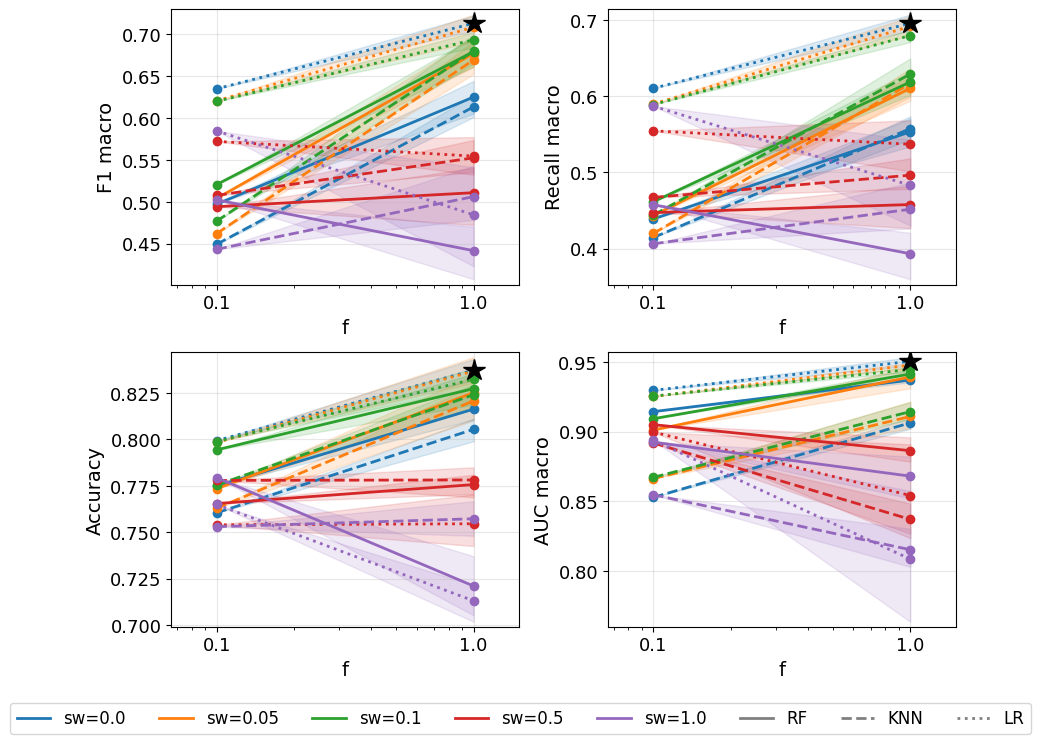

Saved → /users/mbredber/p3_SUPLAT/outputs/figures/classification/sweep_lines_pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1_f_initial_pure.pdf


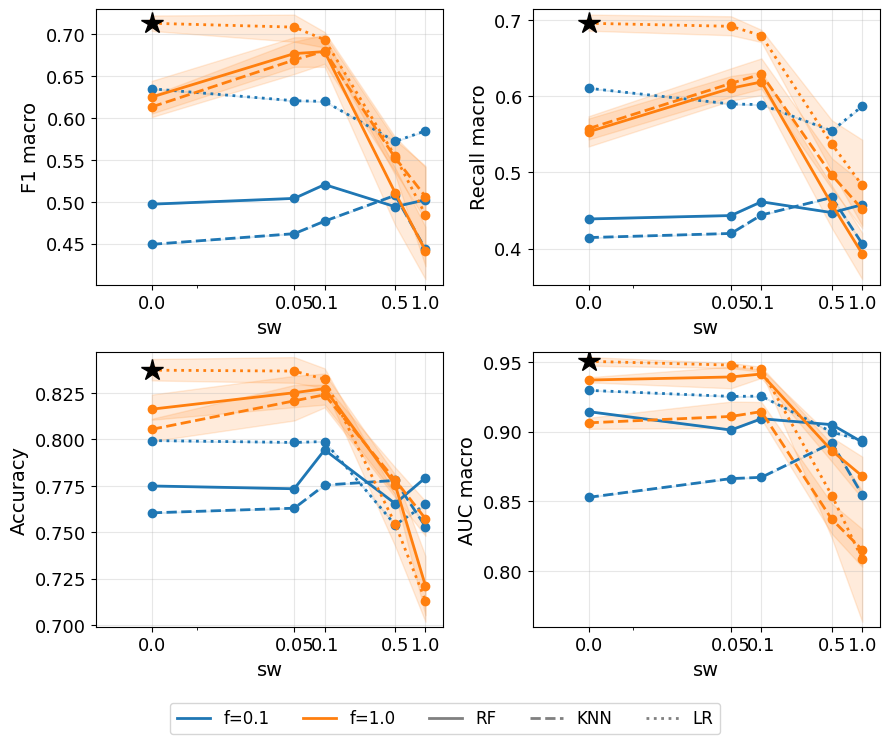

Saved → /users/mbredber/p3_SUPLAT/outputs/figures/classification/sweep_lines_pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1_sw_initial_pure.pdf


In [20]:
# ── Parseable hyperparameter patterns ─────────────────────────────────────────
_PARAM_RE = {
    "f":         r"_f([\d.]+)_",
    "sw":        r"_sw([\d.]+)_",
    "vicregvar": r"_vicregvar([\d.]+)_",
    "cov":       r"_cov([\d.]+)_",
    "gamma":     r"_gamma([\d.]+)_",
    "ema":       r"_ema([\d.]+)_",
}

def _parse_param(name, param):
    m = re.search(_PARAM_RE[param], name + "_")
    return float(m.group(1)) if m else None

# ── Infer fixed params from the reference run ──────────────────────────────────
_BYOL_SEED = int(Path(CONFIG["checkpoint"]).parent.name.split("_")[-1])
_ref_name  = Path(CONFIG["checkpoint"]).parent.parent.parent.name
_axis_x    = GRID_CONFIG["axis_x"]
_axis_y    = GRID_CONFIG["axis_y"]
_fixed = {
    p: _parse_param(_ref_name, p)
    for p in _PARAM_RE
    if p not in (_axis_x, _axis_y) and _parse_param(_ref_name, p) is not None
}
print("Fixed params:", _fixed)

# ── Scan run directories ────────────────────────────────────────────────────────
_root     = Path(GRID_CONFIG["outputs_root"])
_run_dirs = sorted(_root.glob(GRID_CONFIG["run_glob"]))
_run_dirs = [rd for rd in _run_dirs if re.search(r"_sw[\d.]+_f[\d.]+", rd.name)]

# ── Fix augmentation and LR schedule to match the reference run ───────────────
_KNOWN_AUG     = ["augquart_ext", "augquart", "augextended", "augbaronperez", "standard"]
_KNOWN_LR_TYPE = ["lrcosine", "lrconst", "lrcyclical"]

def _parse_aug(name):
    for aug in _KNOWN_AUG:
        if f"_{aug}_" in name or name.endswith(f"_{aug}"):
            return aug
    return None

def _parse_lr_type(name):
    _n = re.sub(r'_\d{8}_\d{4}$', '', name)
    for lr in _KNOWN_LR_TYPE:
        if f"_{lr}" in _n:
            return lr
    return None

_ref_aug     = _parse_aug(_ref_name)
_ref_lr_type = _parse_lr_type(_ref_name)
print(f"Reference augmentation: {_ref_aug}  LR schedule: {_ref_lr_type}")

_run_dirs = [
    rd for rd in _run_dirs
    if (_ref_aug     is None or _parse_aug(rd.name)     == _ref_aug)
    and (_ref_lr_type is None or _parse_lr_type(rd.name) == _ref_lr_type)
]
_target_runs = [
    rd for rd in _run_dirs
    if all(
        _parse_param(rd.name, k) is not None and abs(_parse_param(rd.name, k) - v) < 1e-9
        for k, v in _fixed.items()
    )
]

# ── Defaults for per-class scatter (cell 6.1); overridden by cell 7 with data-driven values ──
_EXCLUDE_F    = set()
_EXCLUDE_SW   = {'1.0', '0.5'}
_EXCLUDE_FRAC = set()

def _skip_label(lbl):
    f_m = re.search(r'f=([\d.]+)', lbl); sw_m = re.search(r'sw=([\d.]+)', lbl)
    return (f_m and f_m.group(1) in _EXCLUDE_F) or (sw_m and sw_m.group(1) in _EXCLUDE_SW)

def _skip_ft_label(lbl):
    return _skip_label(lbl)

_BYOL_CLF_PRIORITY = ["GP", "LogReg", "LR", "RF", "KNN"]
_sw_color_map      = {}   # populated by cell 7 after loading results

_CLFS  = ["rf", "knn", "lr"]
_CLF_STYLES = {"rf": "-", "knn": "--", "lr": ":"}
_CLF_LABELS = {"rf": "RF", "knn": "KNN", "lr": "LR"}
_tls   = CONFIG["train_label_set"]
_els   = CONFIG["eval_label_set"]
_feat  = GRID_CONFIG["feature_type"]
_gcw   = CONFIG.get("class_weight", "")
_gcw_tag = f"cw{_gcw}" if _gcw else "cwNone"

# Build records per classifier
# Build records per classifier — aggregate across all available BYOL seeds
_records = {}
def _get_clf_json(ts_dir, clf):
    _sd = ts_dir / "data" / "classifiers" / "simple_downstream"
    _cd = _sd / f"{_tls}_{_gcw_tag}"
    if not _cd.exists():
        _cd = _sd / _tls
    p = (_cd / f"{clf}_{_feat}.json" if _tls == _els
         else _cd / f"{clf}_{_feat}_{_els}_eval.json")
    return p if p.exists() else None

_METRIC_FIELDS = [("f1", "f1_macro"), ("auc", "auc_macro"),
                  ("acc", "accuracy"), ("rec", "recall_macro")]

for _clf in _CLFS:
    _records[_clf] = []
    for rd in _run_dirs:
        params = {p: _parse_param(rd.name, p) for p in _PARAM_RE}
        if not all(
            params.get(k) is not None and abs(params[k] - v) < 1e-9
            for k, v in _fixed.items()
        ):
            continue
        _seed_vals = {mk: [] for mk, _ in _METRIC_FIELDS}
        for _ts_dir in _get_seed_dirs(rd):
            _jp = _get_clf_json(_ts_dir, _clf)
            if _jp is None:
                continue
            with open(_jp) as _fh:
                _d = json.load(_fh)
            for mk, fld in _METRIC_FIELDS:
                v = _d.get(fld, float("nan"))
                if v == v:
                    _seed_vals[mk].append(v)
        if not any(_seed_vals.values()):
            continue
        _rec = {"x": params[_axis_x], "y": params[_axis_y]}
        for mk, _ in _METRIC_FIELDS:
            vs = _seed_vals[mk]
            _rec[mk] = float(np.mean(vs)) if vs else float("nan")
            if len(vs) > 1:
                _lo, _hi = _ci68(vs)
                _rec[f"{mk}_lo"], _rec[f"{mk}_hi"] = float(_lo), float(_hi)
            else:
                _rec[f"{mk}_lo"], _rec[f"{mk}_hi"] = 0.0, 0.0
        _records[_clf].append(_rec)
    print(f"  {_clf}: {len(_records[_clf])} run(s) found")

_grids = {_clf: {(r["x"], r["y"]): r for r in recs}
          for _clf, recs in _records.items()}
_all_recs = [r for recs in _records.values() for r in recs]
_xs = sorted(set(r["x"] for r in _all_recs))
_ys = sorted(set(r["y"] for r in _all_recs))

_METRICS   = [("f1", "F1 macro"), ("rec", "Recall macro"),
              ("acc", "Accuracy"), ("auc", "AUC macro")]
_line_cmap = plt.cm.tab10

# Print sweep summary once (outside the widget function so it stays above the plot)
for sweep_var, sweep_vals in [(_axis_x, _xs), (_axis_y, _ys)]:
    if len(sweep_vals) < 2:
        print(f"Skipping {sweep_var} sweep (only {len(sweep_vals)} value(s))")
    else:
        print(f"Sweep: {sweep_var}  |  {_els} (train={_tls}), {_feat}, {_gcw_tag}  |  fixed: {_fixed}")

# ── Plot ───────────────────────────────────────────────────────────────────────
for sweep_var, group_var, sweep_vals, group_vals, axis_is_x in [
    (_axis_x, _axis_y, _xs, _ys, True),
    (_axis_y, _axis_x, _ys, _xs, False),
]:
    if len(sweep_vals) < 2:
        continue

    fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharey=False)

    for ax, (mkey, mlabel) in zip(axes.flat, _METRICS):
        # Collect all plotted (x, y) values to find the global max
        _all_plot_pts = []
        _yall = []

        for gi, gv in enumerate(group_vals):
            color = _line_cmap(gi % 10)
            for _clf in _CLFS:
                xs_plot, ys_plot, los_plot, his_plot = [], [], [], []
                for sv in sweep_vals:
                    key = (sv, gv) if axis_is_x else (gv, sv)
                    rec = _grids[_clf].get(key)
                    val = rec[mkey] if rec is not None else float("nan")
                    if val == val:
                        xs_plot.append(sv)
                        ys_plot.append(val)
                        los_plot.append(rec.get(f"{mkey}_lo", 0.0))
                        his_plot.append(rec.get(f"{mkey}_hi", 0.0))
                if not xs_plot:
                    continue
                ax.plot(xs_plot, ys_plot,
                        marker="o", markersize=6, linewidth=2.0,
                        linestyle=_CLF_STYLES[_clf],
                        color=color,
                        label=f"{group_var}={gv} / {_CLF_LABELS[_clf]}")
                ax.fill_between(xs_plot,
                                [y - lo for y, lo in zip(ys_plot, los_plot)],
                                [y + hi for y, hi in zip(ys_plot, his_plot)],
                                alpha=0.15, color=color)
                _all_plot_pts.extend(zip(xs_plot, ys_plot))
                _yall.extend(y - lo for y, lo in zip(ys_plot, los_plot) if np.isfinite(y))
                _yall.extend(y + hi for y, hi in zip(ys_plot, his_plot) if np.isfinite(y))

        # Mark the highest point with a star
        if _all_plot_pts:
            _best_x, _best_y = max(_all_plot_pts, key=lambda p: p[1])
            ax.plot(_best_x, _best_y, marker="*", markersize=16,
                    color="black", zorder=10, linestyle="none")

        ax.set_xlabel(sweep_var, fontsize=14)
        ax.set_ylabel(mlabel, fontsize=14)
        _sv_min, _sv_max = min(sweep_vals), max(sweep_vals)
        _has_zero = _sv_min == 0
        if _has_zero:
            _nonzero = [v for v in sweep_vals if v != 0]
            _linthresh = min(_nonzero) / 2 if _nonzero else 0.01
            ax.set_xscale("symlog", linthresh=_linthresh)
            ax.set_xlim(-_linthresh * 0.5, _sv_max * 1.5)
        else:
            ax.set_xscale("log")
            ax.set_xlim(_sv_min / 1.5, _sv_max * 1.5)
        ax.set_xticks(sweep_vals)
        ax.set_xticklabels([str(v) for v in sweep_vals], fontsize=11)
        ax.tick_params(axis="both", labelsize=13)
        if _yall:
            _pad = 0.02 * (max(_yall) - min(_yall))
            ax.set_ylim(min(_yall) - _pad, max(_yall) + _pad)
        ax.grid(True, alpha=0.3)

    _color_handles = [
        plt.Line2D([0], [0], color=_line_cmap(gi % 10), linewidth=2, label=f"{group_var}={gv}")
        for gi, gv in enumerate(group_vals)
    ]
    _style_handles = [
        plt.Line2D([0], [0], color="grey", linewidth=2,
                   linestyle=_CLF_STYLES[c], label=_CLF_LABELS[c])
        for c in _CLFS
    ]
    fig.legend(
        handles=_color_handles + _style_handles,
        loc="upper center", ncol=len(group_vals) + len(_CLFS),
        fontsize=12, bbox_to_anchor=(0.5, 0),
        frameon=True,
    )

    plt.tight_layout()
    _out = f"{OUT_DIR}/sweep_lines_{_ref_name}_{sweep_var}_{_els}.pdf"
    plt.savefig(_out, bbox_inches="tight")
    plt.show()
    print(f"Saved → {_out}")

## 5. Fine-tuning Comparison

Per-class and macro F1 / AUC / Recall / Accuracy for fine-tuned encoder variants.
Reads `finetuning_metrics.json` from each run's fine-tuning subdirectory.

- Mode 1: frozen encoder + projector, linear head only
- Mode 2: frozen encoder, fine-tune projector + linear head
- Mode 3: fine-tune encoder + projector + linear head end-to-end

Paths:
  ../outputs/byol_runs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1/data_seed_2/training_seed_2/
Finetuning types found: ['initial_pure_cwNone0.0_mode2_lr1e-2_ep40', 'initial_pure_cwNone0.0_mode3_lr1e-2_ep40']
Eval : initial_pure


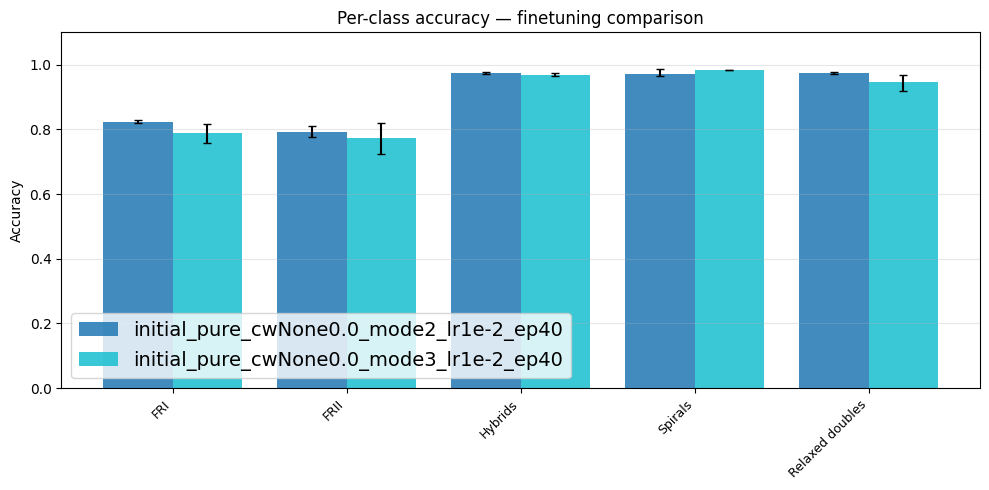

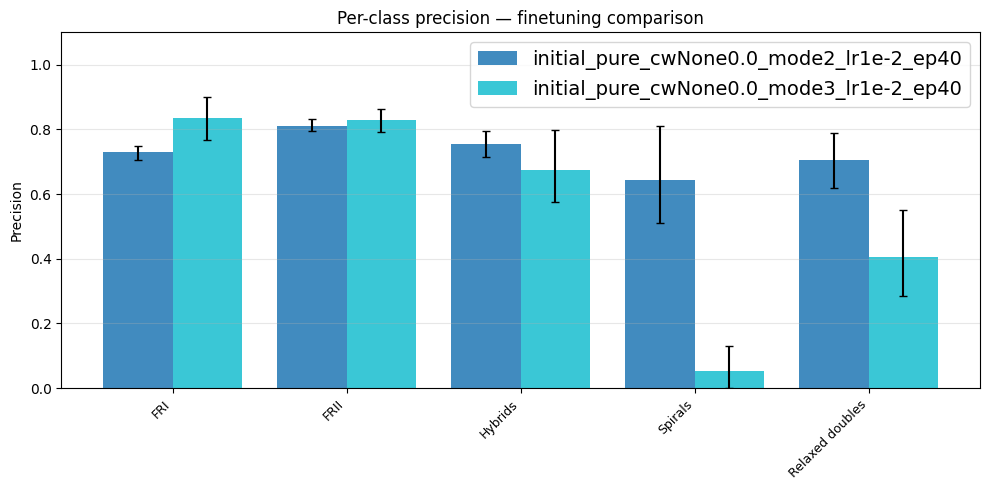

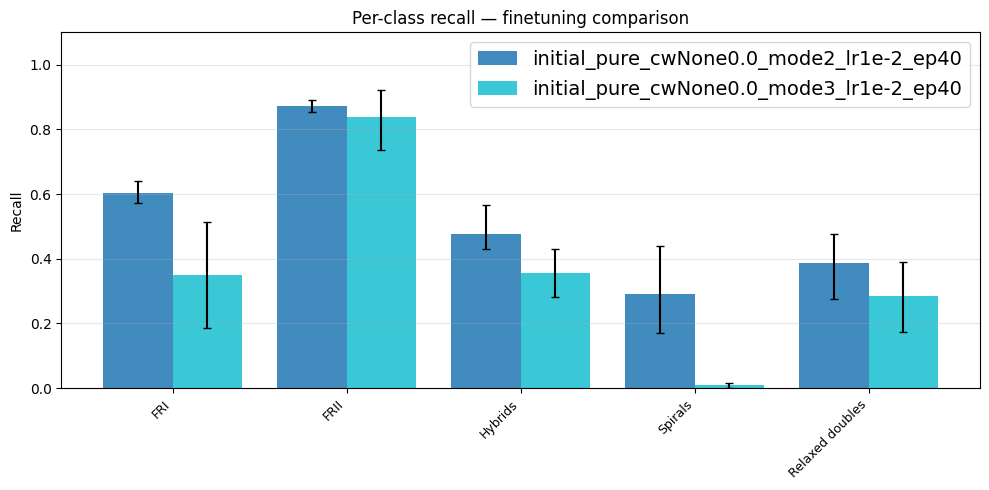

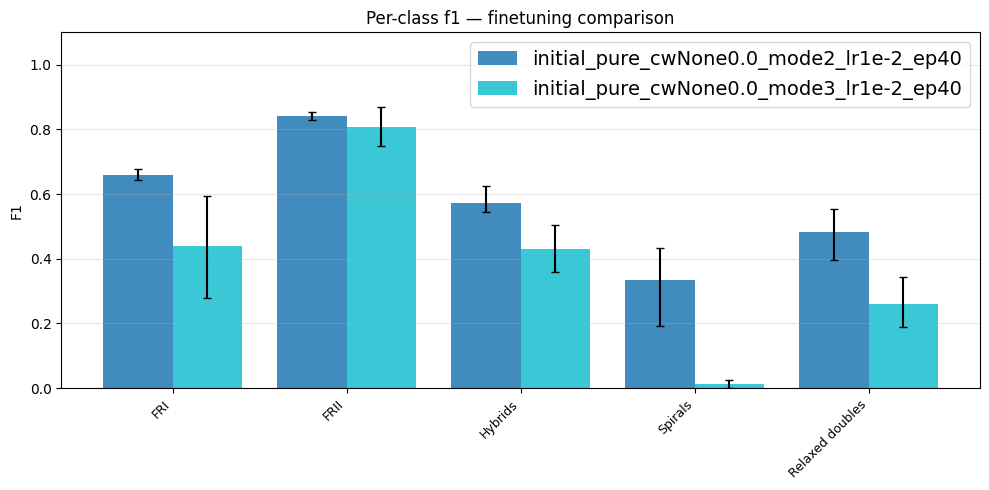

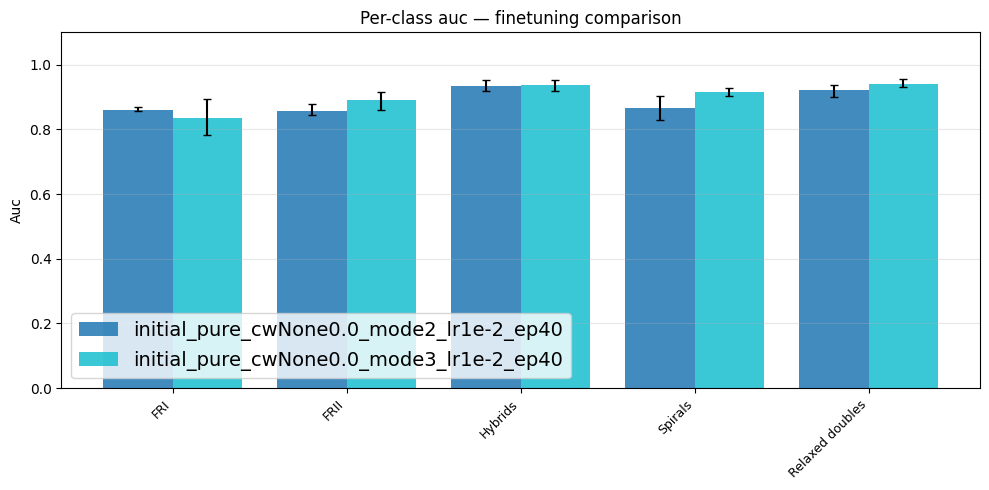

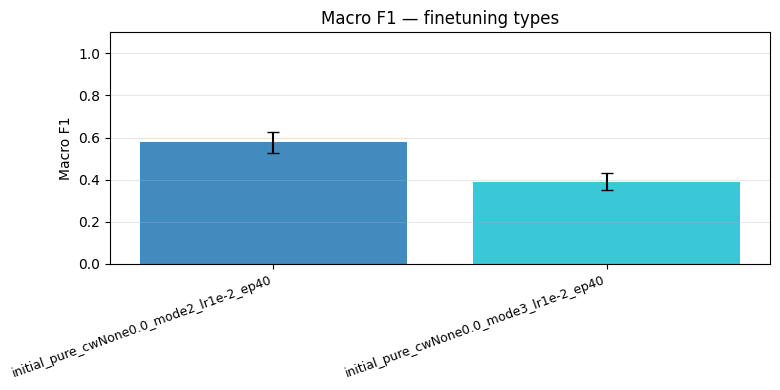

In [21]:
# ── Discover finetuning dirs from config ──────────────────────────────────────
_cw        = CONFIG.get("class_weight", "")
_cw_tag    = f"cw{_cw}" if _cw else "cwNone"
_tls       = CONFIG["train_label_set"]
_ft_prefix = f"{_tls}_{_cw_tag}"

model_paths      = CONFIG["finetuning_runs"]
finetune_types   = []
_ft_dirs_by_type = {}   # type_name -> [Path, ...]

for _rp in model_paths:
    _rp_path = Path(_rp)
    _search_bases = [_rp_path / "data" / "classifiers" / "finetuning"]
    for _cv in sorted(_rp_path.glob("cross_val_*")):
        _search_bases.append(_cv / "data" / "classifiers" / "finetuning")
    for _clf_base in _search_bases:
        if not _clf_base.exists():
            continue
        for _d in sorted(_clf_base.glob(f"{_ft_prefix}*")):
            _tname = _d.name
            if _tname not in _ft_dirs_by_type:
                finetune_types.append(_tname)
                _ft_dirs_by_type[_tname] = []
            _ft_dirs_by_type[_tname].append(_d)

print("Paths:")
for _p in model_paths:
    print(f"  {_p}")
print(f"Finetuning types found: {finetune_types or '(none yet)'}")
print(f"Eval : {CONFIG['eval_label_set']}")

per_class_metrics = ["accuracy", "precision", "recall", "f1", "auc"]


def _extract_per_class_metric_ft(metrics, metric_name):
    """Mean per-class array from finetuning_metrics.json test split."""
    for _mkey in [metric_name, f"{metric_name}_macro"]:
        if _mkey not in metrics:
            continue
        _v = metrics[_mkey]
        if isinstance(_v, dict) and "test" in _v:
            _arr = np.asarray(_v["test"], dtype=np.float32)
            if _arr.ndim == 2:          # (n_runs, n_classes)
                return _arr.mean(axis=0)
            if _arr.ndim == 1:
                return _arr
    return None


def _extract_macro_f1_ft(metrics):
    """Scalar macro F1 (mean over runs) from finetuning_metrics.json."""
    for _mkey in ["macro_f1", "f1_macro"]:
        if _mkey not in metrics:
            continue
        _v = metrics[_mkey]
        if isinstance(_v, dict) and "test" in _v:
            _arr = np.asarray(_v["test"], dtype=np.float32).flatten()
            if _arr.size > 0:
                return float(_arr.mean())
    return None


metrics_by_type = {m: {} for m in per_class_metrics}
macro_f1_results = {}

for ftype in finetune_types:
    _pc_vals  = {m: [] for m in per_class_metrics}
    _mf1_vals = []
    for _d in _ft_dirs_by_type.get(ftype, []):
        _mf = _d / "finetuning_metrics.json"
        if not _mf.exists():
            continue
        with open(_mf) as _f:
            _m = json.load(_f)
        for metric in per_class_metrics:
            _arr = _extract_per_class_metric_ft(_m, metric)
            if _arr is not None:
                _pc_vals[metric].append(_arr)
        _mf1 = _extract_macro_f1_ft(_m)
        if _mf1 is not None:
            _mf1_vals.append(_mf1)
    for metric in per_class_metrics:
        if _pc_vals[metric]:
            metrics_by_type[metric][ftype] = _pc_vals[metric]
    if _mf1_vals:
        macro_f1_results[ftype] = _mf1_vals

# ── Per-class metric plots ────────────────────────────────────────────────────
_class_names_plot = ([ALL_CLASS_NAMES[i] for i in LABEL_SETS[CONFIG["eval_label_set"]]]
                     if CONFIG["eval_label_set"] in LABEL_SETS else [])

if not finetune_types:
    print("No finetuning results found — run finetuning jobs first.")
else:
    for metric_name in per_class_metrics:
        _all_data = {ft: metrics_by_type[metric_name].get(ft, []) for ft in finetune_types}
        if not any(_all_data.values()):
            print(f"Skipping {metric_name}: no data.")
            continue
        _n_cls = max((a.shape[0] for runs in _all_data.values() for a in runs), default=0)
        if _n_cls == 0:
            continue

        _fig, _ax = plt.subplots(figsize=(max(10, _n_cls * 0.8), 5))
        _x = np.arange(_n_cls)
        _w = 0.8 / max(len(finetune_types), 1)
        _colors = plt.cm.tab10(np.linspace(0, 0.9, len(finetune_types)))

        for _i, ft in enumerate(finetune_types):
            _runs = _all_data[ft]
            if not _runs:
                continue
            _stack = np.stack(_runs, axis=0)
            _mean  = _stack.mean(axis=0)
            if len(_runs) > 1:
                _lo_err, _hi_err = _ci68(_stack, axis=0)
            else:
                _lo_err = _hi_err = np.zeros(_n_cls)
            _ax.bar(_x + _i * _w, _mean, _w, yerr=[_lo_err, _hi_err], label=ft,
                    color=_colors[_i], capsize=3, alpha=0.85)

        _ax.set_xticks(_x + _w * (len(finetune_types) - 1) / 2)
        if _class_names_plot and len(_class_names_plot) == _n_cls:
            _ax.set_xticklabels(_class_names_plot, rotation=45, ha="right", fontsize=9)
        else:
            _ax.set_xticklabels([str(i) for i in range(_n_cls)], rotation=45, ha="right", fontsize=9)
        _ax.set_ylabel(metric_name.capitalize())
        _ax.set_ylim(0, 1.1)
        _ax.legend(fontsize=14)
        _ax.set_title(f"Per-class {metric_name} — finetuning comparison")
        _ax.grid(axis="y", alpha=0.3)
        _fig.tight_layout()
        plt.show()

    # ── Macro F1 summary ──────────────────────────────────────────────────────────
    if not macro_f1_results:
        print("Skipping macro_f1 plot: no data.")
    else:
        _fig, _ax = plt.subplots(figsize=(8, 4))
        _colors = plt.cm.tab10(np.linspace(0, 0.9, len(finetune_types)))
        for _i, ft in enumerate(finetune_types):
            _vals = macro_f1_results.get(ft, [])
            if not _vals:
                continue
            _mean = float(np.mean(_vals))
            if len(_vals) > 1:
                _lo_err, _hi_err = _ci68(_vals)
            else:
                _lo_err = _hi_err = 0.0
            _ax.bar(_i, _mean, yerr=[[_lo_err], [_hi_err]], color=_colors[_i], capsize=4, alpha=0.85, label=ft)
        _ax.set_xticks(range(len(finetune_types)))
        _ax.set_xticklabels(finetune_types, rotation=20, ha="right", fontsize=9)
        _ax.set_ylabel("Macro F1")
        _ax.set_ylim(0, 1.1)
        _ax.set_title("Macro F1 — finetuning types")
        _ax.grid(axis="y", alpha=0.3)
        _fig.tight_layout()
        plt.show()


## 6. Supervised Classifier Results

Loads pre-trained supervised classifier results from `CONFIG["baselines_dir"]`
and compares against BYOL classifiers on the configured `eval_label_set` test split.

Path : ../outputs/supervised_baseline_classifiers/without_generative
Eval : initial_pure
CW   : cwNone


  enb0 (initial_pure): 15 run(s)  F1=0.642 +0.012/-0.010
Loaded 1 baseline group(s): ['enb0 (initial_pure)']
  FT initial_pure m2 lr=1e-2: 5 run(s)  F1=0.507 +0.008/-0.011
  FT initial_pure m3 lr=1e-2: 5 run(s)  F1=0.447 +0.041/-0.030
Loaded 2 finetuning group(s): ['FT initial_pure m2 lr=1e-2', 'FT initial_pure m3 lr=1e-2']

initial_pure Classification — BYOL vs Supervised Baselines (LoTSS test split)


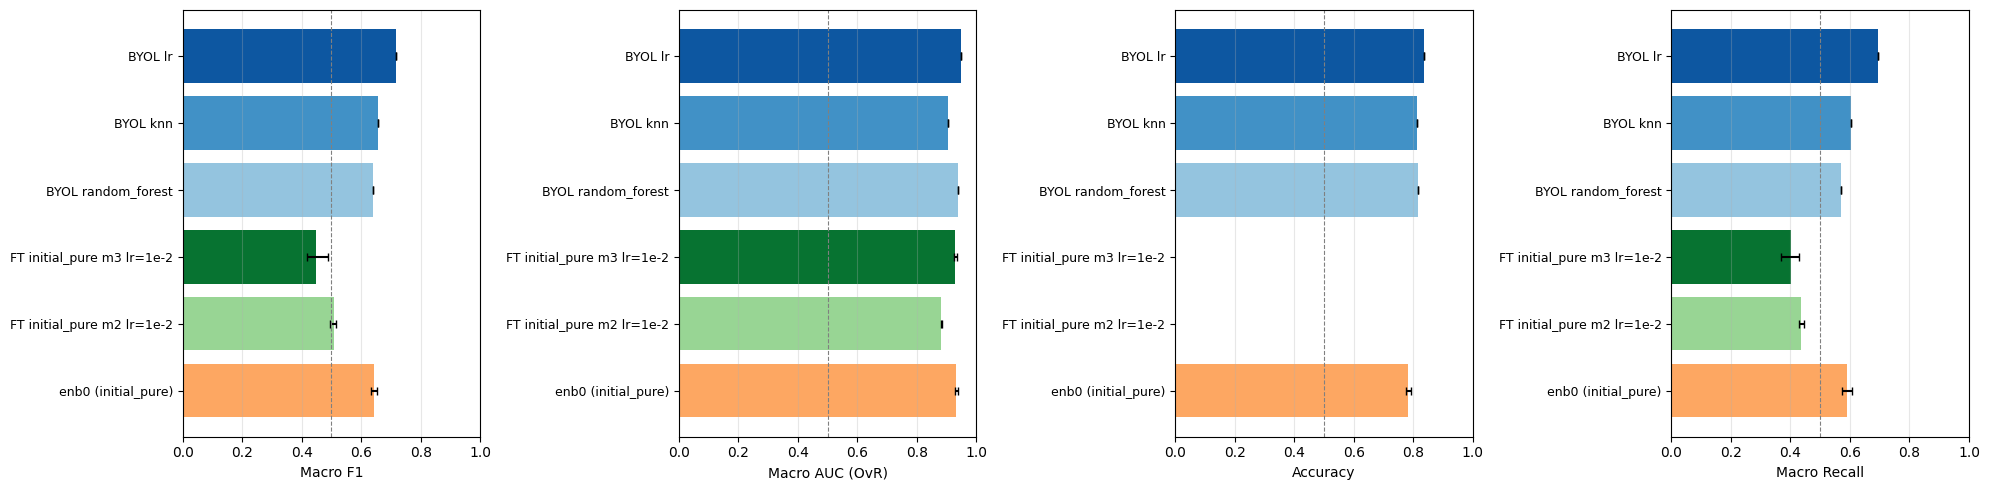

In [22]:
_KNOWN_MODELS = ("enb0", "dualssn", "vit", "cnn", "scatternet", "simplescatternet")


_baselines_dir = Path(CONFIG.get("baselines_dir", "../outputs/supervised_baseline_classifiers"))
_baselines_search_dir = (_baselines_dir / "without_generative"
                         if (_baselines_dir / "without_generative").exists()
                         else _baselines_dir)
_els = CONFIG["eval_label_set"]
_cw_bl     = CONFIG.get("class_weight", "")
_cw_tag_bl = f"cw{_cw_bl}" if _cw_bl else "cwNone"

print(f"Path : {_baselines_search_dir}")
print(f"Eval : {_els}")
print(f"CW   : {_cw_tag_bl}")

baseline_results = {}

if _baselines_dir.exists():
    # Only look in top-level dirs whose name contains the configured cw tag
    _bl_top_dirs = [
        d for d in sorted(_baselines_search_dir.iterdir())
        if d.is_dir() and (
            d.name.endswith(f"_{_cw_tag_bl}") or f"_{_cw_tag_bl}_" in d.name
            # Also match lowercase + optional 0.0 suffix (old job-script naming)
            or d.name.lower().endswith(f"_{_cw_tag_bl.lower()}") or f"_{_cw_tag_bl.lower()}_" in d.name.lower()
            or d.name.lower().endswith(f"_{_cw_tag_bl.lower()}0.0") or f"_{_cw_tag_bl.lower()}0.0_" in d.name.lower()
        )
    ]
    # Keep only diagonal runs (data_seed == training_seed)
    def _is_diag(d):
        _m = __import__('re').search(r'_s(\d+)_ds(\d+)$', d.name)
        return _m is None or _m.group(1) == _m.group(2)
    _bl_top_dirs = [d for d in _bl_top_dirs if _is_diag(d)]

    # Group run dirs by (model, label_set, ES-flag), one group per top-level output dir
    _model_runs = {}
    for _top_dir in _bl_top_dirs:
        for _path in sorted(_top_dir.rglob("results.json")):
            _sp = str(_path)
            if "frac_" in _sp or "gen_aug" in _sp:
                continue          # skip fraction-sweep results
            with open(_path) as _f:
                _res = json.load(_f)
            if not _res.get("class_names"):
                continue
            # Resolve run dir: parent is run-dir (run\d+) → go up one level
            _parent = _path.parent
            _resolved_top = _parent.parent if re.match(r"run\d+$", _parent.name) else _parent
            _model = next((m for m in _KNOWN_MODELS if m in _resolved_top.name.lower()), "unknown")
            _ls    = _res.get("label_set", "?")
            _es    = " ES" if "_ES_" in _resolved_top.name or _resolved_top.name.endswith("_ES") else ""
            _key   = f"{_model} ({_ls}{_es})"
            _model_runs.setdefault(_key, []).append((_parent, _res))

    for _key, _runs in _model_runs.items():
        _metrics_list = [r for _, r in _runs]
        for _m in ("f1_macro", "auc_macro", "accuracy", "recall_macro"):
            _vals = [r[_m] for r in _metrics_list if _m in r]
            baseline_results.setdefault(_key, {})[_m + "_mean"] = float(np.mean(_vals))
            if len(_vals) > 1:
                _bl_lo, _bl_hi = _ci68(_vals)
                baseline_results[_key][_m + "_lo"] = float(_bl_lo)
                baseline_results[_key][_m + "_hi"] = float(_bl_hi)
            else:
                baseline_results[_key][_m + "_lo"] = None
                baseline_results[_key][_m + "_hi"] = None

        # Top-5 ensemble: sort by f1_macro, average probs from top-5 runs
        _sorted_runs = sorted(_runs, key=lambda x: x[1].get("f1_macro", 0), reverse=True)
        _top_k = _sorted_runs[:min(5, len(_sorted_runs))]
        _prob_list, _y_true = [], None
        for _rd, _ in _top_k:
            _p = _rd / "test_probs.npy"
            _l = _rd / "test_labels.npy"
            if _p.exists() and _l.exists():
                _prob_list.append(np.load(_p))
                if _y_true is None:
                    _y_true = np.load(_l)
        # Only average runs whose test-probs shape matches the first one
        if _prob_list:
            _ref_shape = _prob_list[0].shape
            _prob_list = [p for p in _prob_list if p.shape == _ref_shape]
        if _prob_list and _y_true is not None and _y_true.shape[0] == _prob_list[0].shape[0]:
            _ens_prob = np.mean(_prob_list, axis=0)
            _ens_pred = (_ens_prob >= 0.5).astype(int)
            from sklearn.metrics import f1_score as _f1s, roc_auc_score as _aucs
            try:
                _ens_f1  = _f1s(_y_true, _ens_pred, average="macro", zero_division=0)
                _ens_auc = _aucs(_y_true, _ens_prob, average="macro")
            except Exception:
                _ens_f1, _ens_auc = float("nan"), float("nan")
            baseline_results[_key]["top5_f1_macro"] = _ens_f1
            baseline_results[_key]["top5_auc_macro"] = _ens_auc

        _n = len(_runs)
        _f1m  = baseline_results[_key]["f1_macro_mean"]
        _f1_lo_v = baseline_results[_key]["f1_macro_lo"]
        _f1_hi_v = baseline_results[_key]["f1_macro_hi"]
        _f1_rng  = f"+{_f1_hi_v:.3f}/-{_f1_lo_v:.3f}" if _f1_lo_v is not None else ""
        print(f"  {_key}: {_n} run(s)  F1={_f1m:.3f} {_f1_rng}")
    print(f"Loaded {len(baseline_results)} baseline group(s): {list(baseline_results.keys())}")

else:
    print(f"Baselines directory not found: {_baselines_dir}")

# ── Finetuning results ────────────────────────────────────────────────────────
def _ft_label(type_name):
    """Concise display label from a finetuning type dir name."""
    _ls_m   = re.search(r"(?:finetuning_)?(\w+?)_cw", type_name)
    _ls     = _ls_m.group(1) if _ls_m else "?"
    _es     = " ES" if "_ES_" in type_name else ""
    _mode_m = re.search(r"mode(\d+)", type_name)
    _mode   = f" m{_mode_m.group(1)}" if _mode_m else ""
    _lr_m   = re.search(r"lr([\de.-]+)", type_name)
    _lr     = f" lr={_lr_m.group(1)}" if _lr_m else ""
    return f"FT {_ls}{_es}{_mode}{_lr}"

finetuning_results = {}
_cw_ft     = CONFIG.get("class_weight", "")
_cw_tag_ft = f"cw{_cw_ft}" if _cw_ft else "cwNone"
_ft_glob   = f"{CONFIG['train_label_set']}_{_cw_tag_ft}*"
for _ft_run_path in CONFIG.get("finetuning_runs", []):
    _ft_run_dir = Path(_ft_run_path)
    for _ft_dir in sorted((_ft_run_dir / "data" / "classifiers" / "finetuning").glob(_ft_glob)):
        _ftm_path = _ft_dir / "finetuning_metrics.json"
        if not _ftm_path.exists():
            continue
        with open(_ftm_path) as _f:
            _ftm = json.load(_f)

        _key = _ft_label(_ft_dir.name)

        # macro F1: stored directly as [[val], [val], ...]
        _f1_vals  = [v[0] for v in _ftm.get("macro_f1", {}).get("test", []) if v]
        # macro AUC: mean of per-class AUCs per run
        _auc_vals = [float(np.mean(v)) for v in _ftm.get("auc",  {}).get("test", []) if v]
        # macro recall: mean of per-class recalls per run
        _rec_vals = [float(np.mean(v)) for v in _ftm.get("recall", {}).get("test", []) if v]
        # accuracy: compute argmax accuracy from saved predictions per run
        _acc_vals = []
        for _rd in sorted(_ft_dir.glob("run*")):
            _pp, _lp = _rd / "test_preds.npy", _rd / "test_labels.npy"
            if _pp.exists() and _lp.exists():
                _pr, _lb = np.load(_pp), np.load(_lp)
                if _pr.ndim == 2:
                    _acc_vals.append((_pr.argmax(1) == _lb.argmax(1)).mean())
                else:
                    _acc_vals.append((_pr == _lb).mean())

        def _agg(vals):
            if not vals:
                return float("nan"), None, None
            mean = float(np.mean(vals))
            if len(vals) > 1:
                _lo, _hi = _ci68(vals)
                return mean, float(_lo), float(_hi)
            return mean, None, None

        _f1_m,  _f1_l,  _f1_h  = _agg(_f1_vals)
        _auc_m, _auc_l, _auc_h = _agg(_auc_vals)
        _rec_m, _rec_l, _rec_h = _agg(_rec_vals)
        _acc_m, _acc_l, _acc_h = _agg(_acc_vals)

        finetuning_results[_key] = {
            "f1_macro_mean":     _f1_m,  "f1_macro_lo":     _f1_l,  "f1_macro_hi":     _f1_h,
            "auc_macro_mean":    _auc_m, "auc_macro_lo":    _auc_l, "auc_macro_hi":    _auc_h,
            "recall_macro_mean": _rec_m, "recall_macro_lo": _rec_l, "recall_macro_hi": _rec_h,
            "accuracy_mean":     _acc_m, "accuracy_lo":     _acc_l, "accuracy_hi":     _acc_h,
        }
        _f1_rng = f"+{_f1_h:.3f}/-{_f1_l:.3f}" if _f1_l is not None else "n/a"
        print(f"  {_key}: {len(_f1_vals)} run(s)  F1={_f1_m:.3f} {_f1_rng}")

print(f"Loaded {len(finetuning_results)} finetuning group(s): {list(finetuning_results.keys())}")

# ── Plot ──────────────────────────────────────────────────────────────────────
_metrics_to_plot = [
    ("f1_macro",     "Macro F1"),
    ("auc_macro",    "Macro AUC (OvR)"),
    ("accuracy",     "Accuracy"),
    ("recall_macro", "Macro Recall"),
]

_byol_results = suite_results.get(f"lotss_{_els}", {})
_n_groups     = len(baseline_results) + len(_byol_results) + len(finetuning_results)
if _n_groups == 0:
    print("No results to plot.")
else:
    _fig, _axes = plt.subplots(1, len(_metrics_to_plot), figsize=(5 * len(_metrics_to_plot), 5))
    if len(_metrics_to_plot) == 1:
        _axes = [_axes]

    _byol_palette = plt.cm.Blues(np.linspace(0.4, 0.85, max(len(_byol_results), 1)))
    _bl_palette   = plt.cm.Oranges(np.linspace(0.4, 0.85, max(len(baseline_results), 1)))
    _ft_palette   = plt.cm.Greens(np.linspace(0.4, 0.85, max(len(finetuning_results), 1)))

    for _ax, (_mkey, _mlabel) in zip(_axes, _metrics_to_plot):
        _x, _labels, _colors, _errs = [], [], [], []
        for _i, (_bk, _bv) in enumerate(baseline_results.items()):
            _val = _bv.get(f"{_mkey}_mean", float("nan"))
            _lo  = _bv.get(f"{_mkey}_lo") or 0.0
            _hi  = _bv.get(f"{_mkey}_hi") or 0.0
            _x.append(_val); _labels.append(_bk); _errs.append((_lo, _hi))
            _colors.append(_bl_palette[_i])
        for _i, (_ftk, _ftv) in enumerate(finetuning_results.items()):
            _val = _ftv.get(f"{_mkey}_mean", float("nan"))
            _lo  = _ftv.get(f"{_mkey}_lo") or 0.0
            _hi  = _ftv.get(f"{_mkey}_hi") or 0.0
            _x.append(_val); _labels.append(_ftk); _errs.append((_lo, _hi))
            _colors.append(_ft_palette[_i])
        for _i, (_ck, _cv) in enumerate(_byol_results.items()):
            _val = _cv.get("f1" if _mkey == "f1_macro" else
                           "auc" if _mkey == "auc_macro" else
                           "accuracy" if _mkey == "accuracy" else "recall", float("nan"))
            _x.append(_val); _labels.append(f"BYOL {_ck}"); _errs.append((0.0, 0.0))
            _colors.append(_byol_palette[_i])

        _ys   = range(len(_labels))
        _xerr = [[e[0] for e in _errs], [e[1] for e in _errs]]
        _ax.barh(_ys, _x, color=_colors, xerr=_xerr, capsize=3)
        _ax.set_yticks(list(_ys)); _ax.set_yticklabels(_labels, fontsize=9)
        _ax.set_xlabel(_mlabel); _ax.set_xlim(0, 1)
        _ax.axvline(0.5, color="grey", linewidth=0.8, linestyle="--")
        _ax.grid(axis="x", alpha=0.3)

    print(f"\n{_els} Classification — BYOL vs Supervised Baselines (LoTSS test split)")
    _fig.tight_layout()
    plt.show()

### 6.1 Per-class Metrics

BYOL LR sw=0.05 f1: 9 seed/fold(s) → std available
BYOL LR sw=0.05 recall: 9 seed/fold(s) → std available
BYOL LR sw=0.05 auc: 9 seed/fold(s) → std available
BYOL LR sw=0.05 accuracy: 9 seed/fold(s) → std available
BYOL LR sw=0.0 f1: 9 seed/fold(s) → std available
BYOL LR sw=0.0 recall: 9 seed/fold(s) → std available
BYOL LR sw=0.0 auc: 9 seed/fold(s) → std available
BYOL LR sw=0.0 accuracy: 9 seed/fold(s) → std available
BYOL LR sw=0.1 f1: 9 seed/fold(s) → std available
BYOL LR sw=0.1 recall: 9 seed/fold(s) → std available
BYOL LR sw=0.1 auc: 9 seed/fold(s) → std available
BYOL LR sw=0.1 accuracy: 9 seed/fold(s) → std available


FT sw=0.05 f1: 45 run(s) → std available
FT sw=0.05 recall: 45 run(s) → std available
FT sw=0.05 accuracy: 45 run(s) → std available
FT sw=0.05 auc: 45 run(s) → std available
FT sw=0.0 f1: 45 run(s) → std available
FT sw=0.0 recall: 45 run(s) → std available
FT sw=0.0 accuracy: 45 run(s) → std available
FT sw=0.0 auc: 45 run(s) → std available
FT sw=0.1 f1: 45 run(s) → std available
FT sw=0.1 recall: 45 run(s) → std available
FT sw=0.1 accuracy: 45 run(s) → std available
FT sw=0.1 auc: 45 run(s) → std available


Baseline enb0 (initial_pure) f1: 15 run(s) → std available
Baseline enb0 (initial_pure) recall: 15 run(s) → std available
Baseline enb0 (initial_pure) accuracy: 15 run(s) → std available
Baseline enb0 (initial_pure) auc: 15 run(s) → std available


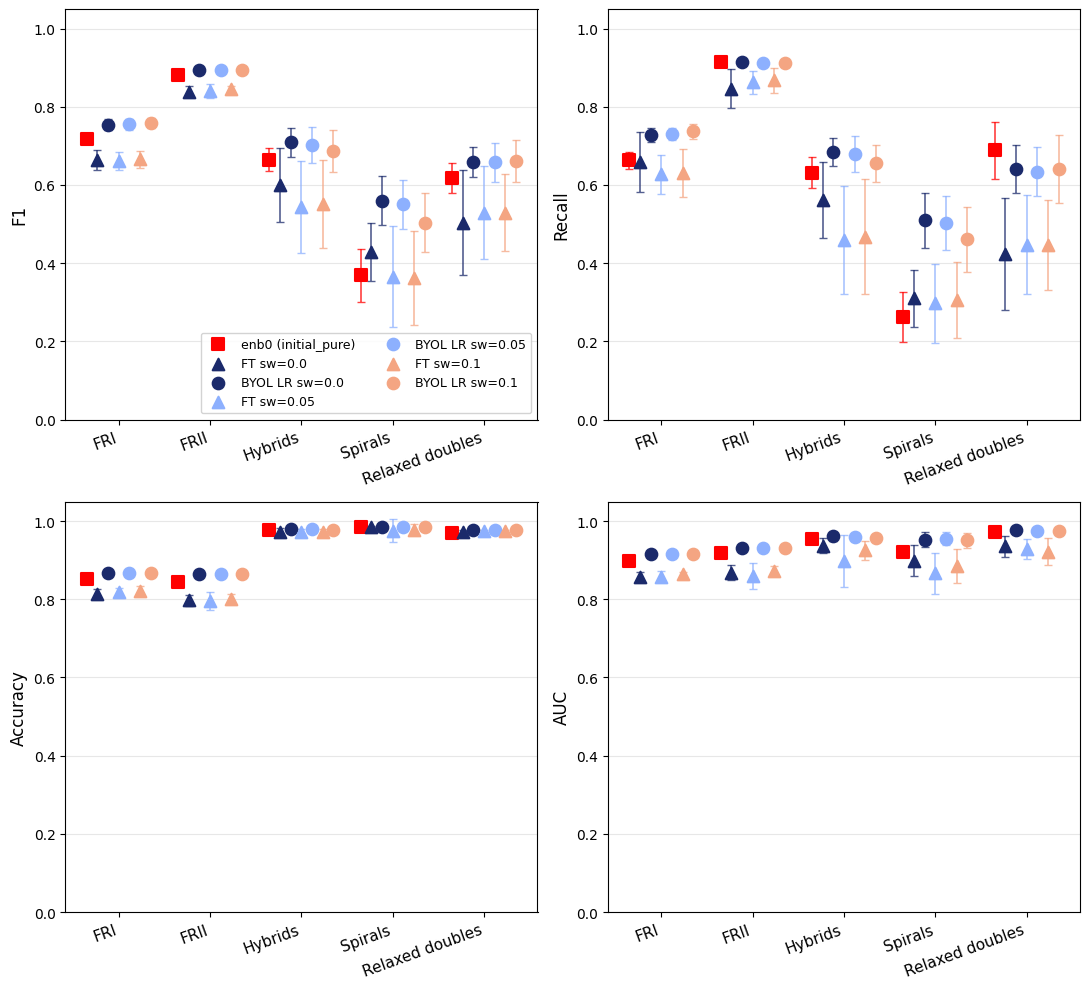

In [23]:
# ── Per-class metrics grouped scatter plot (F1, Recall, Accuracy, AUC) ───────
# Configurable
_PC_F_SELECT = 1.0    # only show runs at this label fraction
_PC_FT_MODE  = 2      # finetuning mode (2 = linear probe on frozen BYOL features)

from sklearn.metrics import (f1_score as _pc_f1_score,
                              recall_score as _pc_rec_score,
                              roc_auc_score as _pc_auc_score,
                              accuracy_score as _pc_acc_score)

_clf_fname  = {"GP": "gp", "LogReg": "lr", "LR": "lr", "RF": "rf", "KNN": "knn"}
_PC_METRICS = [("f1", "F1"), ("recall", "Recall"), ("accuracy", "Accuracy"), ("auc", "AUC")]
_PC_MKS     = [m for m, _ in _PC_METRICS]

# ── Helper: find classifier dir, tolerating cw-tag variants ──────────────────
def _pc_clf_dir(base_dir):
    _sd = base_dir / "data" / "classifiers" / "simple_downstream"
    for _sub in [f"{_tls}_{_cw_tag}", f"{_tls}_cwNone", _tls]:
        _d = _sd / _sub
        if _d.exists():
            return _d
    return _sd / f"{_tls}_{_cw_tag}"  # non-existent fallback

def _pc_load_pjson(base_dir):
    """Load the best-available *_projections.json from base_dir's clf dir."""
    _cd = _pc_clf_dir(base_dir)
    for _ck in _BYOL_CLF_PRIORITY:
        _ckey = _clf_fname[_ck]
        _p = _cd / f"{_ckey}_projections.json"
        if _p.exists():
            _d = json.loads(_p.read_text())
            if "f1_per_class" in _d and "class_names" in _d:
                # Compute recall/accuracy per class from saved .npy files when absent
                # (old runs pre-date saving these fields; new runs include them directly)
                if "recall_per_class" not in _d or "accuracy_per_class" not in _d:
                    _preds_f = _cd / f"{_ckey}_projections_test_preds.npy"
                    _lbls_f  = _cd / "projections_test_labels.npy"
                    if _preds_f.exists() and _lbls_f.exists():
                        _yt = np.load(_lbls_f)
                        _yp = np.load(_preds_f)
                        if _yt.ndim == 2:
                            _yt = _yt.argmax(axis=1)
                        if _yp.ndim == 2:
                            _yp = _yp.argmax(axis=1)
                        _nc = len(_d["class_names"])
                        from sklearn.metrics import recall_score as _rs
                        _d.setdefault("recall_per_class",
                            _rs(_yt, _yp, average=None, labels=list(range(_nc)),
                                zero_division=0).tolist())
                        _d.setdefault("accuracy_per_class",
                            [float(_pc_acc_score((_yt == c).astype(int),
                                                  (_yp == c).astype(int)))
                             for c in range(_nc)])
                return _d
    return None

def _pc_iter_base_dirs(run_name_dir):
    """Yield all seed/fold leaf dirs to aggregate over."""
    for _s in _get_available_seeds(run_name_dir):
        _seed_dir = run_name_dir / f"data_seed_{_s}" / f"training_seed_{_s}"
        _folds = sorted(_seed_dir.glob("cross_val_*"))
        if _folds:
            yield from _folds
        else:
            yield _seed_dir

# ── Step 1: Load BYOL LR per-class — all seeds/folds for each sw ─────────────
_byol_pc_runs = {}   # {sw: {metric: [array, ...]}}
_class_names  = None

for _rd in _target_runs:
    _f_val  = _parse_param(_rd.name, "f")
    _sw_val = _parse_param(_rd.name, "sw")
    if _f_val is None or _sw_val is None:
        continue
    if _skip_label(f"f={_f_val} sw={_sw_val}"):
        continue
    if _PC_F_SELECT is not None and abs(_f_val - _PC_F_SELECT) > 1e-9:
        continue

    for _base in _pc_iter_base_dirs(_rd):
        _d = _pc_load_pjson(_base)
        if _d is None:
            continue
        if _class_names is None:
            _class_names = _d["class_names"]
        _n = len(_d["f1_per_class"])
        _entry = {
            "f1":       np.array(_d["f1_per_class"]),
            "recall":   np.array(_d["recall_per_class"])   if "recall_per_class"   in _d else np.full(_n, np.nan),
            "auc":      np.array(_d["auc_per_class"])      if "auc_per_class"      in _d else np.full(_n, np.nan),
            "accuracy": np.array(_d["accuracy_per_class"]) if "accuracy_per_class" in _d else np.full(_n, np.nan),
        }
        for _mk, _arr in _entry.items():
            _byol_pc_runs.setdefault(_sw_val, {}).setdefault(_mk, []).append(_arr)

# mean ± std across seeds/folds
_byol_pc = {}
for _sw_val, _mk_dict in _byol_pc_runs.items():
    _byol_pc[_sw_val] = {}
    for _mk, _arrs in _mk_dict.items():
        _stk = np.stack(_arrs)
        _byol_pc[_sw_val][_mk]          = np.nanmean(_stk, axis=0)
        _byol_pc[_sw_val][_mk + "_std"] = (np.nanstd(_stk, axis=0)
                                            if len(_arrs) > 1
                                            else np.zeros(_stk.shape[1]))
        if len(_arrs) > 1:
            print(f"BYOL LR sw={_sw_val} {_mk}: {len(_arrs)} seed/fold(s) → std available")

# ── Step 2: Load finetuning per-class — pool runs across all seeds/folds ──────
_ft_pc_runs = {}   # {sw: {metric: [array_per_run_x_seed]}}

for _rd in _target_runs:
    _f_val  = _parse_param(_rd.name, "f")
    _sw_val = _parse_param(_rd.name, "sw")
    if _f_val is None or _sw_val is None:
        continue
    if _skip_label(f"f={_f_val} sw={_sw_val}"):
        continue
    if _PC_F_SELECT is not None and abs(_f_val - _PC_F_SELECT) > 1e-9:
        continue

    for _base in _pc_iter_base_dirs(_rd):
        _ft_base = _base / "data" / "classifiers" / "finetuning"
        _ft_jsons = sorted(_ft_base.glob(
            f"{_tls}_cwNone0.0_mode{_PC_FT_MODE}_*/finetuning_metrics.json"))
        if not _ft_jsons:
            _ft_jsons = sorted(_ft_base.glob(
                f"{_tls}_cwNone_mode{_PC_FT_MODE}_*/finetuning_metrics.json"))
        if not _ft_jsons:
            continue
        _d = json.loads(_ft_jsons[-1].read_text())
        for _mk_raw, _mk_key in [("f1","f1"), ("recall","recall"), ("accuracy","accuracy"), ("auc","auc")]:
            _v = _d.get(_mk_raw, {}).get("test")
            if _v:
                for _row in _v:   # each row = one run's per-class values
                    _ft_pc_runs.setdefault(_sw_val, {}).setdefault(_mk_key, []).append(
                        np.array(_row))

_ft_pc = {}
for _sw_val, _mk_dict in _ft_pc_runs.items():
    _n_ft = len(next(iter(_mk_dict.values())))
    _ft_pc[_sw_val] = {}
    for _mk in _PC_MKS:
        _arrs = _mk_dict.get(_mk)
        if _arrs:
            _stk = np.stack(_arrs)
            _ft_pc[_sw_val][_mk]          = np.nanmean(_stk, axis=0)
            _ft_pc[_sw_val][_mk + "_std"] = (np.nanstd(_stk, axis=0)
                                              if len(_arrs) > 1
                                              else np.zeros(_stk.shape[1]))
            if len(_arrs) > 1:
                print(f"FT sw={_sw_val} {_mk}: {len(_arrs)} run(s) → std available")
        else:
            _n = len(_ft_pc[_sw_val].get("f1", np.array([])))
            _ft_pc[_sw_val][_mk]          = np.full(_n or 1, np.nan)
            _ft_pc[_sw_val][_mk + "_std"] = np.zeros(_n or 1)

# ── Step 3: Load supervised baseline per-class — per-run then std ────────────
_bl_pc = {}

for _bl_key, _bl_runs in _model_runs.items():
    _run_metrics = {_mk: [] for _mk in _PC_MKS}

    for _run_rd, _ in _bl_runs:
        _p_path = _run_rd / "test_probs.npy"
        _l_path = _run_rd / "test_labels.npy"
        if not (_p_path.exists() and _l_path.exists()):
            continue
        _p = np.load(_p_path)
        _l = np.load(_l_path)
        if _l.shape[0] != _p.shape[0]:
            continue
        _n_cls = _p.shape[1]
        _lbls  = list(range(_n_cls))
        _yt = _l.argmax(axis=1) if _l.ndim == 2 else _l
        _yp = _p.argmax(axis=1)
        try:
            _run_metrics["f1"].append(
                _pc_f1_score(_yt, _yp, average=None, labels=_lbls, zero_division=0))
            _run_metrics["recall"].append(
                _pc_rec_score(_yt, _yp, average=None, labels=_lbls, zero_division=0))
            _run_metrics["accuracy"].append(np.array([
                _pc_acc_score((_yt == c).astype(int), (_yp == c).astype(int))
                for c in _lbls]))
            try:
                _run_metrics["auc"].append(
                    _pc_auc_score(np.eye(_n_cls)[_yt], _p,
                                  multi_class="ovr", average=None))
            except Exception:
                _run_metrics["auc"].append(np.full(_n_cls, np.nan))
        except Exception:
            pass

    if not _run_metrics["f1"]:
        continue
    _bl_entry = {}
    for _mk in _PC_MKS:
        _arrs = _run_metrics[_mk]
        if _arrs:
            _stk = np.stack(_arrs)
            _bl_entry[_mk]          = np.nanmean(_stk, axis=0)
            _bl_entry[_mk + "_std"] = (np.nanstd(_stk, axis=0)
                                       if len(_arrs) > 1
                                       else np.zeros(_stk.shape[1]))
            if len(_arrs) > 1:
                print(f"Baseline {_bl_key} {_mk}: {len(_arrs)} run(s) → std available")
        else:
            _n = len(_bl_entry.get("f1", np.array([])))
            _bl_entry[_mk]          = np.full(_n or 1, np.nan)
            _bl_entry[_mk + "_std"] = np.zeros(_n or 1)
    _bl_pc[_bl_key] = _bl_entry

# ── Build local sw colour map (sw_color_map may still be empty here) ────────
_sw_all_pc   = sorted(set(list(_byol_pc) + list(_ft_pc)))
_sw_color_pc = {sw: _SW_PALETTE[i % len(_SW_PALETTE)]
                for i, sw in enumerate(_sw_all_pc)}

# ── Step 4: Plot 2×2 grid ─────────────────────────────────────────────────────
if _class_names is None and _bl_pc:
    _n_fallback = list(_bl_pc.values())[0]["f1"].shape[0]
    _class_names = [str(i) for i in range(_n_fallback)]

if _class_names is None:
    print("Per-class metrics: no class names found — skipping plot "
          "(run train_byol_classifiers.py to generate projections.json)")
else:
    _n_classes = len(_class_names)
    _x_base    = np.arange(_n_classes)

    _fig_pc, _axes_pc = plt.subplots(2, 2, figsize=(max(10, _n_classes * 2.2), 10))
    _axes_pc = _axes_pc.flatten()

    for _ax_idx, (_ax_pc, (_mkey, _mlabel)) in enumerate(zip(_axes_pc, _PC_METRICS)):
        _series = []   # (label, marker, facecolor, edgecolor, err_color, mean, std)
        for _bl_lbl, _bl_d in sorted(_bl_pc.items()):
            _mean = _bl_d.get(_mkey)
            _std  = _bl_d.get(_mkey + "_std")
            if _mean is not None:
                _series.append((_bl_lbl, "s", "red", "red", "red", _mean, _std))
        for _sw_v in sorted(set(list(_ft_pc) + list(_byol_pc))):
            _col = _sw_color_pc.get(_sw_v, "grey")
            if _sw_v in _ft_pc:
                _mean = _ft_pc[_sw_v].get(_mkey)
                _std  = _ft_pc[_sw_v].get(_mkey + "_std")
                if _mean is not None:
                    _series.append((f"FT sw={_sw_v}", "^", _col, _col, _col, _mean, _std))
            if _sw_v in _byol_pc:
                _mean = _byol_pc[_sw_v].get(_mkey)
                _std  = _byol_pc[_sw_v].get(_mkey + "_std")
                if _mean is not None:
                    _series.append((f"BYOL LR sw={_sw_v}", "o", _col, _col, _col, _mean, _std))

        if not _series:
                continue

        _n_series = len(_series)
        _offsets  = np.linspace(-0.35, 0.35, _n_series) if _n_series > 1 else [0.0]

        for _off, (_lbl, _mkr, _fc, _ec, _errc, _mean, _std) in zip(_offsets, _series):
            _xs    = _x_base + _off
            _valid = ~np.isnan(_mean.astype(float))
            _ax_pc.scatter(
                _xs[_valid], _mean[_valid],
                marker=_mkr, s=70,
                facecolors=_fc, edgecolors=_ec, linewidths=1.5,
                label=_lbl, zorder=4,
            )
            if _std is not None:
                _has_err = _valid & (_std > 0)
                if _has_err.any():
                    _ax_pc.errorbar(
                        _xs[_has_err], _mean[_has_err], yerr=_std[_has_err],
                        fmt="none", ecolor=_errc,
                        elinewidth=1.2, capsize=3, alpha=0.75, zorder=3,
                    )

        _ax_pc.set_xticks(_x_base)
        _ax_pc.set_xticklabels(_class_names, rotation=20, ha="right", fontsize=11)
        _ax_pc.set_ylabel(_mlabel, fontsize=12)
        _ax_pc.set_ylim(0, 1.05)
        _ax_pc.axhline(0, color="grey", linewidth=0.5, linestyle=":")
        _ax_pc.grid(axis="y", alpha=0.3)
        if _ax_idx == 0:
            _ax_pc.legend(loc="lower right", fontsize=9, ncol=2, framealpha=0.85)

    plt.tight_layout()
    plt.show()


### 6.2 LR Macro F1 by Label Set

One dot per SW value, one tick per label set (train = eval). Results are averaged across all available seeds / CV folds.  
Set `_LSCOMP_CLF` below to switch to a different classifier.

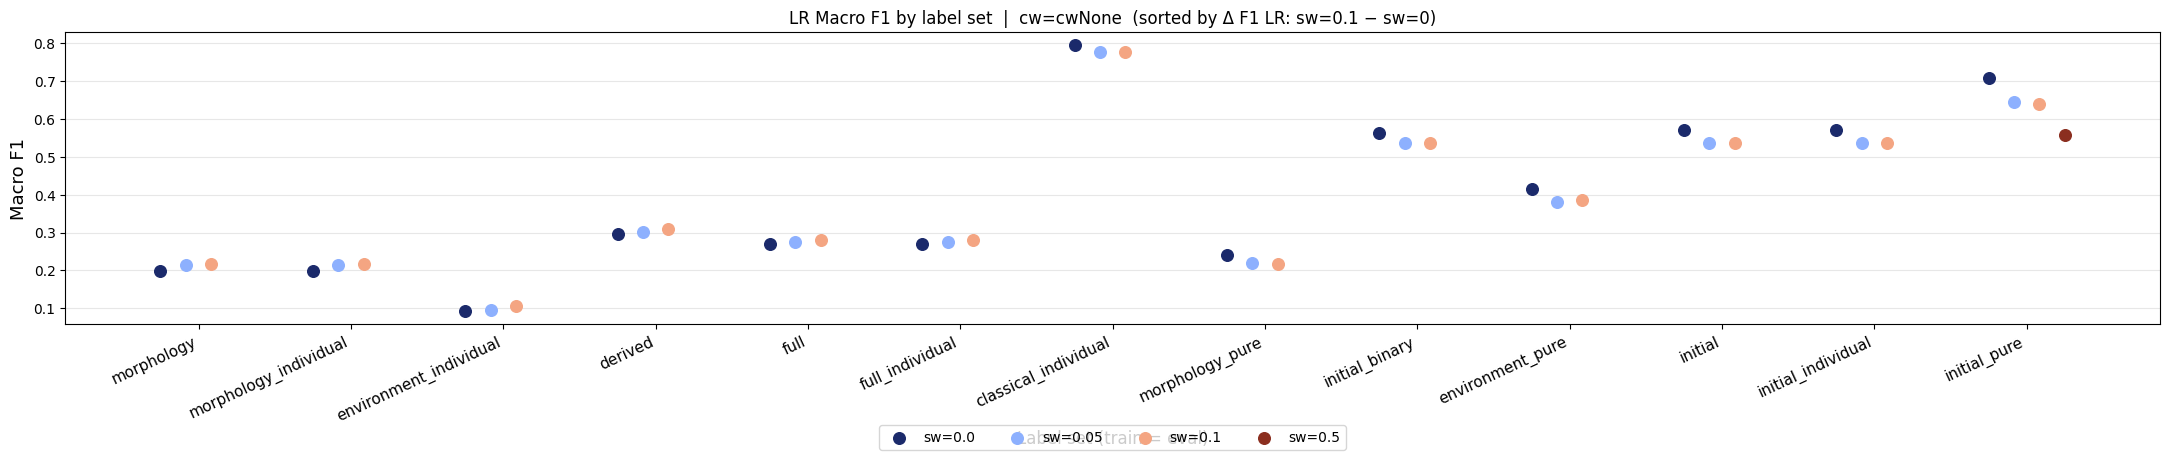

Saved → /users/mbredber/p3_SUPLAT/outputs/figures/classification/lr_labelset_comparison_pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1.pdf


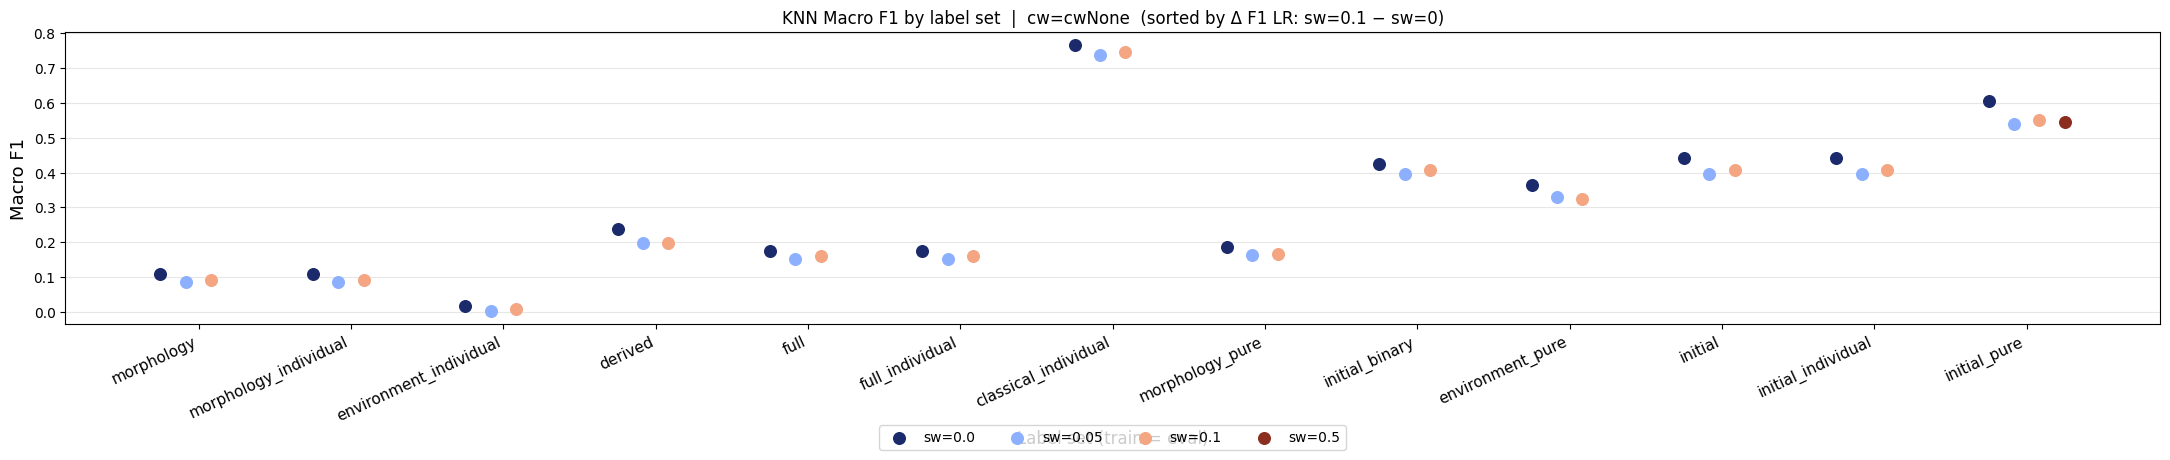

Saved → /users/mbredber/p3_SUPLAT/outputs/figures/classification/knn_labelset_comparison_pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1.pdf


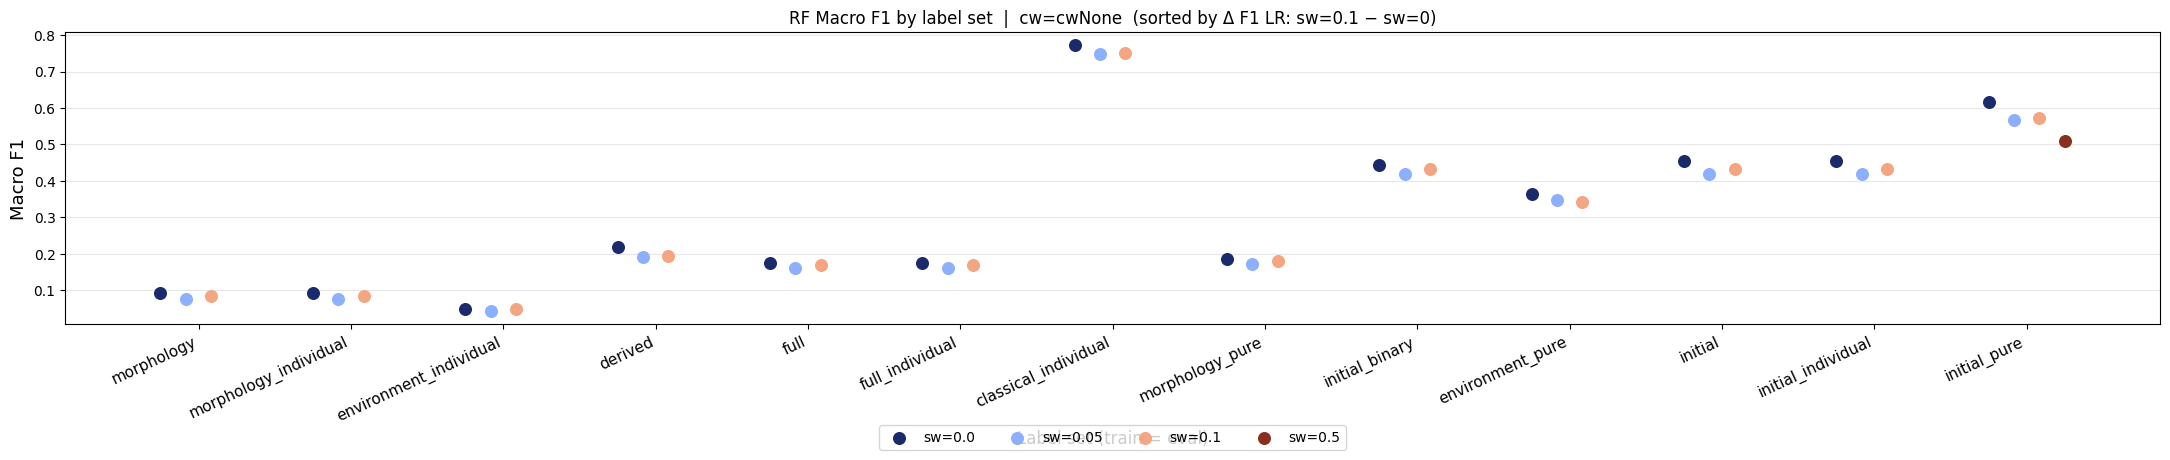

Saved → /users/mbredber/p3_SUPLAT/outputs/figures/classification/rf_labelset_comparison_pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1.pdf


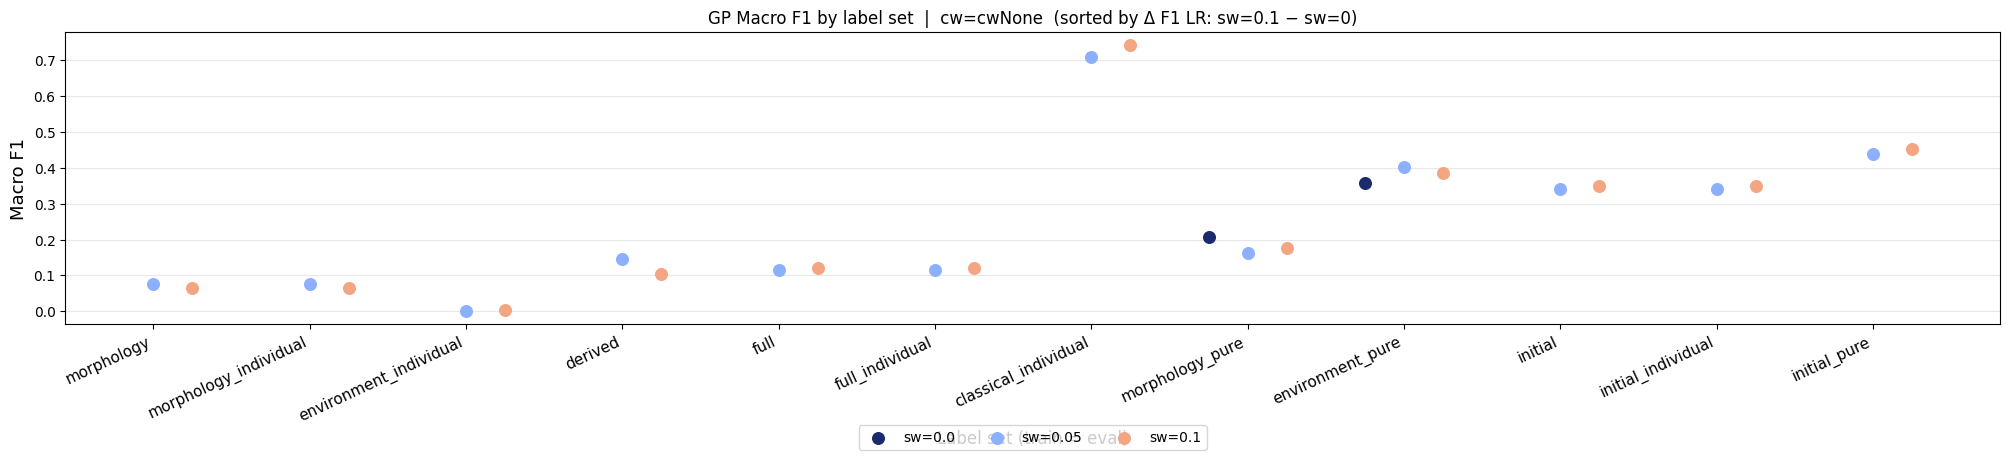

Saved → /users/mbredber/p3_SUPLAT/outputs/figures/classification/gp_labelset_comparison_pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1.pdf


In [24]:
# ── Macro F1 by Label Set — one figure per classifier ────────────────────────
_LSCOMP_CLFS    = ["lr", "knn", "rf", "gp"]   # classifiers to plot
_LSCOMP_CW      = "cwNone"                     # class-weight tag to select
_LSCOMP_FEAT    = "projections"
_LSCOMP_EXCL_SW = {1.0}                        # sw values to hide

# ── Single-pass disk scan: {clf → {ls → {sw → [f1, ...]}}} ──────────────────
_lscomp_all = {clf: {} for clf in _LSCOMP_CLFS}

for _rd in _target_runs:
    _sw = _parse_param(_rd.name, "sw")
    if _sw is None or _sw in _LSCOMP_EXCL_SW:
        continue
    for _base in _pc_iter_base_dirs(_rd):
        _clf_root = _base / "data" / "classifiers" / "simple_downstream"
        if not _clf_root.exists():
            continue
        for _sub in sorted(_clf_root.iterdir()):
            if not _sub.is_dir():
                continue
            # Parse label_set name by stripping trailing _cw<tag>
            _m = re.search(r'_cw\w+$', _sub.name)
            if _m:
                _ls = _sub.name[: _m.start()]
                _cw = _sub.name[_m.start() + 1:]
            else:
                _ls = _sub.name
                _cw = "cwNone"
            if _cw != _LSCOMP_CW:
                continue
            for _clf in _LSCOMP_CLFS:
                _p = _sub / f"{_clf}_{_LSCOMP_FEAT}.json"
                if not _p.exists():
                    continue
                _d  = json.loads(_p.read_text())
                _f1 = _d.get("f1_macro", float("nan"))
                if _f1 == _f1:
                    _lscomp_all[_clf].setdefault(_ls, {}).setdefault(_sw, []).append(_f1)

# ── Sort key shared across all classifiers: Δ F1(sw=0.1 − sw=0) for LR ──────
def _lscomp_delta_for(results_by_ls):
    def _key(ls):
        d = results_by_ls.get(ls, {})
        a = np.mean(d.get(0.1, [float("nan")]))
        b = np.mean(d.get(0.0, [float("nan")]))
        return (a - b) if (a == a and b == b) else float("-inf")
    return _key

_lscomp_sort_ref = _lscomp_all.get("lr") or next(iter(_lscomp_all.values()), {})
_lscomp_ls_order = sorted(
    set(ls for clf_d in _lscomp_all.values() for ls in clf_d),
    key=_lscomp_delta_for(_lscomp_sort_ref),
    reverse=True,
)

# ── One figure per classifier ─────────────────────────────────────────────────
for _clf in _LSCOMP_CLFS:
    _clf_results = _lscomp_all[_clf]
    if not _clf_results:
        print(f"{_clf}: no results found — skipping")
        continue

    _lscomp_mean = {
        _ls: {_sw: float(np.mean(_vs)) for _sw, _vs in _sw_dict.items()}
        for _ls, _sw_dict in _clf_results.items()
    }

    # Use the shared label-set order (LR sort), keeping only labels with data
    _ls_labels  = [ls for ls in _lscomp_ls_order if ls in _lscomp_mean]
    _sw_vals_lc = sorted(set(sw for d in _lscomp_mean.values() for sw in d))
    _lscomp_colors = {sw: _SW_PALETTE[i % len(_SW_PALETTE)]
                      for i, sw in enumerate(_sw_vals_lc)}

    _x_pos   = np.arange(len(_ls_labels))
    _n_sw    = len(_sw_vals_lc)
    _offsets = np.linspace(-0.25, 0.25, _n_sw) if _n_sw > 1 else [0.0]

    fig, ax = plt.subplots(figsize=(max(6, len(_ls_labels) * 1.6 + 1), 5))

    for _off, _sw in zip(_offsets, _sw_vals_lc):
        _col = _lscomp_colors[_sw]
        _ys  = [_lscomp_mean[_ls].get(_sw, float("nan")) for _ls in _ls_labels]
        ax.scatter(_x_pos + _off, _ys, color=_col, s=70, zorder=4, label=f"sw={_sw}")

    ax.set_xticks(_x_pos)
    ax.set_xticklabels(_ls_labels, rotation=25, ha="right", fontsize=11)
    ax.set_ylabel("Macro F1", fontsize=13)
    ax.set_xlabel("Label set (train = eval)", fontsize=12)
    ax.set_title(f"{_clf.upper()} Macro F1 by label set  |  cw={_LSCOMP_CW}  "
                 f"(sorted by Δ F1 LR: sw=0.1 − sw=0)", fontsize=12)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=10, ncol=_n_sw, loc="upper center",
              bbox_to_anchor=(0.5, -0.32), frameon=True)
    plt.tight_layout()

    _out = f"{OUT_DIR}/{_clf}_labelset_comparison_{_ref_name}.pdf"
    plt.savefig(_out, bbox_inches="tight")
    plt.show()
    print(f"Saved → {_out}")

## 7. Label Fraction

Performance as a function of labelled training fraction for three model families:

- **BYOL + LR** (dotted, hollow circles) — logistic regression on frozen projections
- **BYOL + FT** (dashed, filled circles) — fine-tuned encoder
- **Supervised** (solid, squares) — end-to-end supervised classifier with ±1 std band

Supervision weight `sw` is colour-coded via `_SW_PALETTE`. Section 7.1 shows Macro F1 only; Section 7.2 shows all four metrics side-by-side.

In [25]:
# ── Setup (self-contained; does not depend on Section 8) ─────────────────────
_PARAM_RE = {
    "f":         r"_f([\d.]+)_",
    "sw":        r"_sw([\d.]+)_",
    "vicregvar": r"_vicregvar([\d.]+)_",
    "cov":       r"_cov([\d.]+)_",
    "gamma":     r"_gamma([\d.]+)_",
    "ema":       r"_ema([\d.]+)_",
}


_BYOL_SEED = CONFIG["training_seed"]
_ref_name  = Path(CONFIG["checkpoint"]).parent.parent.parent.name
_byol_root = Path(CONFIG["byol_runs_dir"])
_run_dirs  = sorted(_byol_root.glob("pd128_*"))
_run_dirs  = [rd for rd in _run_dirs if re.search(r"_sw[\d.]+_f[\d.]+", rd.name)]
_fixed = {
    p: _parse_param(_ref_name, p)
    for p in _PARAM_RE
    if p not in ("f", "sw") and _parse_param(_ref_name, p) is not None
}
print(f"Reference run : {_ref_name}")
print(f"Fixed params  : {_fixed}")
print(f"Candidate runs: {len(_run_dirs)}")

# ── Find runs in the vicinity of the configured checkpoint ────────────────────
# "Vicinity" = same fixed hyperparams (vicregvar, cov, gamma, ema)
#              AND same aug type AND same LR schedule type.


_ref_aug     = _parse_aug(_ref_name)
_ref_lr_type = _parse_lr_type(_ref_name)

_target_runs = [
    rd for rd in _run_dirs
    if all(
        _parse_param(rd.name, k) is not None and abs(_parse_param(rd.name, k) - v) < 1e-9
        for k, v in _fixed.items()
    )
    and (_ref_aug     is None or _parse_aug(rd.name)     == _ref_aug)
    and (_ref_lr_type is None or _parse_lr_type(rd.name) == _ref_lr_type)
]
print(f"Found {len(_target_runs)} runs (fixed={_fixed}, aug={_ref_aug}, lr={_ref_lr_type})")

# ── Load pre-computed label-fraction metrics (BYOL runs) ──────────────────────
fractions   = [0.01, 0.05, 0.10, 0.25, 0.50, 1.0]
_CACHE_FILE = "label_fraction_metrics.json"
_tls    = CONFIG["train_label_set"]  # path key — files saved under train_label_set dir
_els    = CONFIG["eval_label_set"]
_cw     = CONFIG.get("class_weight", "")
_cw_tag = f"cw{_cw}" if _cw else "cwNone"


# Maps run label → Path of the classifier file actually used
_clf_paths: dict = {}

def _load_metrics(run_dir, seed=None):
    """Load label_fraction_metrics.json from data_seed_s/training_seed_s/ directly.
    Returns (data_dict, path) or (None, None). Cross-val folds are handled
    per-fold in the main loop to preserve per-fold variance for CI computation.
    Falls back to cwNone dir if the exact CW-tagged dir doesn't exist.
    """
    _s = seed if seed is not None else _BYOL_SEED
    _seed_dir = run_dir / f"data_seed_{_s}" / f"training_seed_{_s}"
    _sd = _seed_dir / "data" / "classifiers" / "simple_downstream"
    _new = _sd / f"{_tls}_{_cw_tag}"
    _fb  = _sd / f"{_tls}_cwNone"
    _clf_d = _new if _new.exists() else (_fb if _fb.exists() else _sd / _tls)
    _p = (_clf_d / f"label_fraction_metrics_{_els}_eval.json"
          if _tls != _els else _clf_d / _CACHE_FILE)
    if not _p.exists():
        return None, None
    with open(_p) as fp:
        raw = json.load(fp)
    loaded = {float(f): v for f, v in raw.items()}
    if set(loaded.keys()) != set(fractions):
        return None, None
    return loaded, _p


def _load_metrics_cv_fold(fold_dir):
    """Load label_fraction_metrics.json from a single cross_val_K dir.
    Returns (data_dict, path) or (None, None).
    """
    _sd = fold_dir / "data" / "classifiers" / "simple_downstream"
    _new = _sd / f"{_tls}_{_cw_tag}"
    _fb  = _sd / f"{_tls}_cwNone"
    _clf_d = _new if _new.exists() else (_fb if _fb.exists() else _sd / _tls)
    _p = (_clf_d / f"label_fraction_metrics_{_els}_eval.json"
          if _tls != _els else _clf_d / _CACHE_FILE)
    if not _p.exists():
        return None, None
    with open(_p) as fp:
        raw = json.load(fp)
    loaded = {float(f): v for f, v in raw.items()}
    if set(loaded.keys()) != set(fractions):
        return None, None
    return loaded, _p

def _load_single_point(run_dir):
    """Fall back to lr projections.json (or cross-eval JSON) for the 100% point.

    Always reads from the tls-trained classifier directory.
    Falls back to the cwNone directory if the exact CW-tagged dir doesn't exist.
    Returns (metrics_dict, path) or (None, None).
    """
    _seed_dir = run_dir / f"data_seed_{_BYOL_SEED}" / f"training_seed_{_BYOL_SEED}"
    _sd    = _seed_dir / "data" / "classifiers" / "simple_downstream"
    _new   = _sd / f"{_tls}_{_cw_tag}"
    _fallback = _sd / f"{_tls}_cwNone"
    _clf_d = _new if _new.exists() else (_fallback if _fallback.exists() else _sd / _tls)
    p = (_clf_d / "lr_projections.json" if _tls == _els
         else _clf_d / f"lr_projections_{_els}_eval.json")
    if not p.exists():
        return None, None
    with open(p) as fp:
        d = json.load(fp)
    return {
        "f1":       d.get("f1_macro",     float("nan")),
        "auc":      d.get("auc_macro",    float("nan")),
        "accuracy": d.get("accuracy",     float("nan")),
        "recall":   d.get("recall_macro", float("nan")),
    }, p
# Classifier priority for picking a single metric value from a fraction dict
_CLF_PRIORITY_CI = ["GP", "LogReg", "LR", "RF", "KNN"]

def _pick_clf_metric(frac_data, metric):
    for _c in _CLF_PRIORITY_CI:
        if _c in frac_data and metric in frac_data[_c]:
            return frac_data[_c][metric]
    return float("nan")

all_frac_results  = {}  # {label: {f: {clf_name: {metric}}}} — mean over all diagonal seeds
all_frac_ci       = {}  # {label: {f: {metric: (lo, hi)}}}   — 68% CI from seed variation
single_pt_results = {}  # {label: {metric}}  — 100%-only star marker

def _unique_label(base, existing):
    """Append a counter suffix if base label already used."""
    if base not in existing:
        return base
    i = 2
    while f"{base} ({i})" in existing:
        i += 1
    return f"{base} ({i})"

for rd in _target_runs:
    f_val  = _parse_param(rd.name, "f")
    sw_val = _parse_param(rd.name, "sw")
    _base_lbl = f"f={f_val} sw={sw_val}"

    # Collect data from all available seeds; for cross-val runs each fold is a
    # separate entry so CI is computed across the 5 folds, not collapsed to one.
    _available_seeds = _get_available_seeds(rd)
    _seed_data = {}  # str key -> (metrics_dict, path)
    for _s in _available_seeds:
        _d, _p = _load_metrics(rd, seed=_s)
        if _d is not None:
            _seed_data[str(_s)] = (_d, _p)
            continue
        # Cross-val: add each fold as a separate entry for CI computation
        _seed_dir = rd / f"data_seed_{_s}" / f"training_seed_{_s}"
        for _cv in sorted(_seed_dir.glob("cross_val_*")):
            _k = int(_cv.name.split("_")[-1])
            _fd, _fp = _load_metrics_cv_fold(_cv)
            if _fd is not None:
                _seed_data[f"s{_s}_k{_k}"] = (_fd, _fp)

    if not _seed_data:
        # No fraction curve — try single-point fallback (uses _BYOL_SEED only)
        sp, sp_path = _load_single_point(rd)
        if sp is not None:
            label = _unique_label(_base_lbl, {**all_frac_results, **single_pt_results})
            single_pt_results[label] = sp
            _clf_paths[label] = sp_path
            print(f"★ {label}  (100% only — run train_byol_classifiers.py to get full curve)")
        else:
            print(f"✗ {_base_lbl}  no cache")
        continue

    # Average metric values over all available seeds/folds (mean line)
    _ref_seed = (str(_BYOL_SEED) if str(_BYOL_SEED) in _seed_data
                 else next(iter(_seed_data)))
    _mean_cached = {}
    for _f in fractions:
        _mean_cached[_f] = {}
        _all_clf_keys = set(
            k for _sd, _ in _seed_data.values() if _f in _sd for k in _sd[_f]
        )
        for _ck in _all_clf_keys:
            _mean_cached[_f][_ck] = {}
            for _m in ("f1", "auc", "accuracy", "recall"):
                _mv = [_sd[_f][_ck][_m]
                       for _sd, _ in _seed_data.values()
                       if _f in _sd and _ck in _sd[_f] and _m in _sd[_f][_ck]]
                if _mv:
                    _mean_cached[_f][_ck][_m] = float(np.mean(_mv))
    label = _unique_label(_base_lbl, all_frac_results)
    all_frac_results[label] = _mean_cached
    _clf_paths[label] = _seed_data[_ref_seed][1]
    print(f"→ {label}  ({len(_seed_data)} entry/entries: {list(_seed_data)})")

    # Compute 68% CI across seeds (only meaningful with ≥2 seeds)
    if len(_seed_data) > 1:
        _ci = {}
        for _f in fractions:
            _ci[_f] = {}
            for _m in ("f1", "auc", "accuracy", "recall"):
                _vals = [_pick_clf_metric(_sd[_f], _m)
                         for _sd, _ in _seed_data.values()
                         if _f in _sd]
                _vals = [v for v in _vals if v == v]  # drop NaN
                if len(_vals) > 1:
                    _lo, _hi = _ci68(_vals)
                    _ci[_f][_m] = (float(_lo), float(_hi))
        all_frac_ci[label] = _ci

# ── Supervised baselines — fraction curves ────────────────────────────────────
# Each baseline run dir saves its own label_fraction_metrics.json (one per run).
# We rglob all of them, group by model label, and compute mean ± std across runs.
# Only dirs whose name contains _{_tls}_cw are considered (label-set match).
# Among those, the latest by timestamp is used.
_baselines_dir = Path(CONFIG["baselines_dir"])
_baselines_search_dir = (_baselines_dir / "without_generative"
                         if (_baselines_dir / "without_generative").exists()
                         else _baselines_dir)
baseline_frac_results = {}  # {model_label: {f: {"Supervised": {metric, metric_std}}}}
baseline_scalars      = {}  # {model_label: {metric, metric_std}} — fallback (no fraction data)

if _baselines_dir.exists():
    _cw_tag_lc = _cw_tag.lower()
    _bl_top_dirs = sorted(
        d for d in _baselines_search_dir.iterdir()
        if d.is_dir()
        and (
            d.name.endswith(f"_{_tls}_{_cw_tag}") or f"_{_tls}_{_cw_tag}_" in d.name
            # Also match lowercase + optional 0.0 suffix (old job-script naming)
            or d.name.lower().endswith(f"_{_tls}_{_cw_tag_lc}") or f"_{_tls}_{_cw_tag_lc}_" in d.name.lower()
            or d.name.lower().endswith(f"_{_tls}_{_cw_tag_lc}0.0") or f"_{_tls}_{_cw_tag_lc}0.0_" in d.name.lower()
        )
    )
    # Keep only diagonal runs (data_seed == training_seed)
    _bl_top_dirs = [d for d in _bl_top_dirs
                    if not (_m2 := re.search(r'_s(\d+)_ds(\d+)$', d.name))
                    or _m2.group(1) == _m2.group(2)]
    # Also collect from cross_val_K subdirs (CV baseline runs)
    def _bl_dir_matches(d):
        _n = d.name.lower()
        return (
            d.name.endswith(f"_{_tls}_{_cw_tag}") or f"_{_tls}_{_cw_tag}_" in d.name
            or _n.endswith(f"_{_tls}_{_cw_tag_lc}") or f"_{_tls}_{_cw_tag_lc}_" in _n
            or _n.endswith(f"_{_tls}_{_cw_tag_lc}0.0") or f"_{_tls}_{_cw_tag_lc}0.0_" in _n
        )
    for _cv_k in sorted(_baselines_dir.glob("cross_val_*")):
        _cv_wg = _cv_k / "without_generative"
        if not _cv_wg.exists():
            continue
        for _d in sorted(_cv_wg.iterdir()):
            if not _d.is_dir() or not _bl_dir_matches(_d):
                continue
            _m2 = re.search(r'_s(\d+)_ds(\d+)$', _d.name)
            if _m2 and _m2.group(1) != _m2.group(2):
                continue
            if _d not in _bl_top_dirs:
                _bl_top_dirs.append(_d)
    _latest_bl_dir = _bl_top_dirs[-1] if _bl_top_dirs else None
    # ── Compute cross-eval fraction metrics for baselines if missing ──────────
    if _latest_bl_dir and _tls != _els and _els in {"initial_pure", "classical_pure",
                                                      "morphology_pure", "environment_pure",
                                                      "full_pure"}:
        for _bl_run_dir in sorted(_latest_bl_dir.iterdir()):
            if not _bl_run_dir.is_dir() or not _bl_run_dir.name.startswith("run"):
                continue
            _bl_xeval_cache = _bl_run_dir / f"label_fraction_metrics_{_els}_eval.json"
            if _bl_xeval_cache.exists():
                continue

            _bl_frac_xeval = {}

            # Collect per-fraction data from frac_*/run*/test_probs.npy (if present)
            for _frac_d in sorted(_bl_run_dir.glob("frac_*")):
                try:
                    _fv = float(_frac_d.name.replace("frac_", ""))
                except ValueError:
                    continue
                _run_metrics = []
                for _rr in sorted(_frac_d.glob("run*")):
                    _pb = _rr / "test_probs.npy"
                    _lb = _rr / "test_labels_20.npy"
                    if not _pb.exists() or not _lb.exists():
                        continue
                    try:
                        _m = _cross_eval_metrics(np.load(_pb), np.load(_lb), _tls, _els)
                        _run_metrics.append(_m)
                    except Exception:
                        pass
                if _run_metrics:
                    _bl_frac_xeval[str(_fv)] = {"Supervised": {
                        "f1":       float(np.mean([m["f1_macro"]     for m in _run_metrics])),
                        "auc":      float(np.mean([m["auc_macro"]    for m in _run_metrics])),
                        "accuracy": float(np.mean([m["accuracy"]     for m in _run_metrics])),
                        "recall":   float(np.mean([m["recall_macro"] for m in _run_metrics])),
                    }}

            # 100% point from run-level test_probs.npy / test_labels_20.npy
            _pb100 = _bl_run_dir / "test_probs.npy"
            _lb100 = _bl_run_dir / "test_labels_20.npy"
            if _pb100.exists() and _lb100.exists() and "1.0" not in _bl_frac_xeval:
                try:
                    _m = _cross_eval_metrics(np.load(_pb100), np.load(_lb100), _tls, _els)
                    _bl_frac_xeval["1.0"] = {"Supervised": {
                        "f1":       float(_m["f1_macro"]),
                        "auc":      float(_m["auc_macro"]),
                        "accuracy": float(_m["accuracy"]),
                        "recall":   float(_m["recall_macro"]),
                    }}
                except Exception:
                    pass

            if _bl_frac_xeval:
                with open(_bl_xeval_cache, "w") as _jf:
                    json.dump(_bl_frac_xeval, _jf, indent=2)

    _bl_frac_by_model: dict = {}
    if _bl_top_dirs:
        print(f"Using {len(_bl_top_dirs)} baseline dir(s): {[d.name for d in _bl_top_dirs]}")
        _bl_cache_name = (_CACHE_FILE if _tls == _els
                          else f"label_fraction_metrics_{_els}_eval.json")
        for _rj in sorted(p for _d in _bl_top_dirs for p in _d.rglob(_bl_cache_name)):
            with open(_rj) as _f:
                _frd = json.load(_f)
            if not _frd:
                continue
            _first = next(iter(_frd.values()))
            if "Supervised" not in _first:
                continue
            _bl_frac_by_model.setdefault("EffNet-B0", []).append(_frd)
    else:
        print(f"No baseline dir found for '{_tls}', {_cw_tag} in {_baselines_search_dir}")

    for _mk, _frd_list in _bl_frac_by_model.items():
        _all_fs = sorted({float(k) for _fd in _frd_list for k in _fd})
        _agg = {}
        for _fs in _all_fs:
            _vals = [_fd[str(_fs)]["Supervised"]
                     for _fd in _frd_list
                     if str(_fs) in _fd and "Supervised" in _fd.get(str(_fs), {})]
            if not _vals:
                continue
            _agg[_fs] = {"Supervised": {
                m: float(np.mean([v[m] for v in _vals]))
                for m in ("f1", "auc", "accuracy", "recall")
            }}
            for m in ("f1", "auc", "accuracy", "recall"):
                _raw = [v[m] for v in _vals]
                if len(_raw) > 1:
                    _blo, _bhi = _ci68(_raw)
                    _agg[_fs]["Supervised"][f"{m}_lo"] = float(_blo)
                    _agg[_fs]["Supervised"][f"{m}_hi"] = float(_bhi)
                else:
                    _agg[_fs]["Supervised"][f"{m}_lo"] = None
                    _agg[_fs]["Supervised"][f"{m}_hi"] = None
        if _agg:
            baseline_frac_results[_mk] = _agg
            print(f"Baseline fraction curve: {_mk} ({len(_frd_list)} run(s), "
                  f"{len(_agg)} fractions)")

    # Scalar fallback: use the same _latest_bl_dir as fraction-curve loading.
    _bl_scalar_runs = []
    if _latest_bl_dir:
        for _rj in sorted(_latest_bl_dir.rglob("results.json")):
            if "frac_" in str(_rj):
                continue
            with open(_rj) as _f:
                _r = json.load(_f)
            if _r.get("class_names"):
                _bl_scalar_runs.append(_r)
    if _bl_scalar_runs and not baseline_frac_results:
        _f1s  = [r["f1_macro"]     for r in _bl_scalar_runs]
        _aucs = [r["auc_macro"]    for r in _bl_scalar_runs]
        _accs = [r["accuracy"]     for r in _bl_scalar_runs]
        _recs = [r["recall_macro"] for r in _bl_scalar_runs]
        def _bl_ci(vals):
            if len(vals) > 1:
                lo, hi = _ci68(vals)
                return float(lo), float(hi)
            return None, None
        _f1_lo, _f1_hi   = _bl_ci(_f1s)
        _auc_lo, _auc_hi = _bl_ci(_aucs)
        _acc_lo, _acc_hi = _bl_ci(_accs)
        _rec_lo, _rec_hi = _bl_ci(_recs)
        baseline_scalars["EffNet-B0"] = {
            "f1":         float(np.mean(_f1s)),  "f1_lo":         _f1_lo,  "f1_hi":         _f1_hi,
            "auc":        float(np.mean(_aucs)), "auc_lo":        _auc_lo, "auc_hi":        _auc_hi,
            "accuracy":   float(np.mean(_accs)), "accuracy_lo":   _acc_lo, "accuracy_hi":   _acc_hi,
            "recall":     float(np.mean(_recs)), "recall_lo":     _rec_lo, "recall_hi":     _rec_hi,
        }
        _f1_rng = f"+{_f1_hi:.3f}/-{_f1_lo:.3f}" if _f1_lo is not None else ""
        print(f"Baseline scalar (fallback): {len(_bl_scalar_runs)} run(s)  "
              f"F1={np.mean(_f1s):.3f} {_f1_rng}")
else:
    print(f"Baselines dir not found: {_baselines_dir}")

# ── Finetuning results — load from per-run test_probs.npy ────────────────────
# Structure produced by train_finetuning.py:
#   data/classifiers/finetuning/{name}/run{i}/test_probs.npy   ← 100% label fraction
#   data/classifiers/finetuning/{name}/frac_{f:.2f}/run{i}/test_probs.npy  ← sweep fractions
#
# For each finetuning variant we build:
#   finetuning_points      {label: {metric: mean, metric_std: std}} — 100% only
#   finetuning_frac_curves {label: {frac: {metric: mean, metric_std: std}}}
from sklearn.metrics import (f1_score as _f1_score, accuracy_score as _acc_score,
                              roc_auc_score as _auc_score, recall_score as _rec_score)
from sklearn.preprocessing import label_binarize as _label_binarize

_FT_METRICS = ("f1", "accuracy", "recall", "auc")

def _probs_to_metrics(prob_path):
    """Load test_probs/labels, return metrics dict for the configured eval_label_set."""
    _lab_path = prob_path.parent / "test_labels.npy"
    if not _lab_path.exists():
        return None
    _p = np.load(prob_path)
    _l = np.load(_lab_path)
    _eval_ls = CONFIG.get("eval_label_set", "full")
    _pure_sets = {"initial_pure", "classical_pure", "morphology_pure", "environment_pure", "full_pure"}
    if _eval_ls in _pure_sets:
        # Single-label multiclass: apply pure-set filter, argmax.
        # "full_pure": mask on all model output columns (exactly one of 20 labels set).
        # All other pure sets: mask on first 5 columns (initial class set).
        if _eval_ls == "full_pure":
            _n_cls = _p.shape[1]
            if _l.ndim == 2:
                _mask = _l[:, :_n_cls].sum(axis=1) == 1
            elif _l.ndim == 1:
                _mask = np.ones(len(_l), dtype=bool)
            else:
                return None
        else:
            _n_cls = 5
            if _l.ndim == 2 and _l.shape[1] >= 5:
                _mask = _l[:, :5].sum(axis=1) == 1
            elif _l.ndim == 1:
                _mask = np.ones(len(_l), dtype=bool)
            else:
                return None
        _p_pure = _p[_mask, :_n_cls]
        _l_pure = _l[_mask, :_n_cls] if _l.ndim == 2 else _l[_mask]
        if len(_p_pure) == 0:
            return None
        _yt = _l_pure.argmax(axis=1) if _l_pure.ndim == 2 else _l_pure
        _yp = _p_pure.argmax(axis=1)
        try:
            _auc_v = _auc_score(
                _label_binarize(_yt, classes=list(range(_p_pure.shape[1]))),
                _p_pure, multi_class="ovr", average="macro")
        except Exception:
            _auc_v = float("nan")
        return {
            "f1":       _f1_score(_yt, _yp, average="macro", zero_division=0),
            "accuracy": _acc_score(_yt, _yp),
            "recall":   _rec_score(_yt, _yp, average="macro", zero_division=0),
            "auc":      _auc_v,
        }
    else:
        # Multi-label: sigmoid threshold 0.5
        if _l.ndim != 2 or _p.ndim != 2 or _l.shape[1] != _p.shape[1]:
            return None
        _yp_bin = (_p >= 0.5).astype(int)
        try:
            _aucs = [_auc_score(_l[:, _i], _p[:, _i])
                     for _i in range(_l.shape[1]) if len(np.unique(_l[:, _i])) >= 2]
            _auc_v = float(np.mean(_aucs)) if _aucs else float("nan")
        except Exception:
            _auc_v = float("nan")
        return {
            "f1":       _f1_score(_l, _yp_bin, average="macro", zero_division=0),
            "accuracy": float((_l == _yp_bin).mean()),  # element-wise, not exact-match
            "recall":   _rec_score(_l, _yp_bin, average="macro", zero_division=0),
            "auc":      _auc_v,
        }

def _aggregate_runs(run_metrics_list):
    """Aggregate a list of per-run metric dicts into mean + 68% CI half-widths."""
    _agg = {m: float(np.mean([r[m] for r in run_metrics_list])) for m in _FT_METRICS}
    if len(run_metrics_list) > 1:
        for m in _FT_METRICS:
            _lo, _hi = _ci68([r[m] for r in run_metrics_list])
            _agg[f"{m}_lo"] = float(_lo)
            _agg[f"{m}_hi"] = float(_hi)
    return _agg

def _find_ft_dir(base, tls, cw_tag, es_tag, spec):
    """Return the first existing finetuning dir, tolerating cw_tag aliases.

    Handles two common mismatches saved by different script versions:
      cwNone   ↔ cwNone0.0
      cwall0.3 ↔ cwall        (trailing numeric suffix optional)
    """
    _candidates = [f"{tls}_{cw_tag}{es_tag}_{spec}"]
    # Strip trailing digits/decimal from cw_tag (e.g. "cwall0.3" → "cwall")
    _stripped = re.sub(r'[\d.]+$', '', cw_tag)
    if _stripped != cw_tag:
        _candidates.append(f"{tls}_{_stripped}{es_tag}_{spec}")
    # Add "0.0" suffix if cw_tag has no digits (e.g. "cwNone" → "cwNone0.0")
    if not re.search(r'[\d.]', cw_tag):
        _candidates.append(f"{tls}_{cw_tag}0.0{es_tag}_{spec}")
    for _name in _candidates:
        _d = base / _name
        if _d.exists():
            return _d
    return None

finetuning_points      = {}  # {label: {metric: mean, ...}}
finetuning_frac_curves = {}  # {label: {frac: {metric: mean, ...}}}

_cw_tag_ft = f"cw{_cw}" if _cw else "cwNone"
_es_tag    = ""

def _collect_ft_dirs(rd, spec):
    """Return flat list of finetuning spec dirs across all seeds and cv folds."""
    _dirs = []
    for _s in _get_available_seeds(rd):
        _seed_dir = rd / f"data_seed_{_s}" / f"training_seed_{_s}"
        _d = _find_ft_dir(_seed_dir / "data" / "classifiers" / "finetuning",
                          _tls, _cw_tag_ft, _es_tag, spec)
        if _d is not None:
            _dirs.append(_d)
            continue
        # f<1 runs: finetuning lives inside each cross_val_K subdir
        for _cv in sorted(_seed_dir.glob("cross_val_*")):
            _cd = _find_ft_dir(_cv / "data" / "classifiers" / "finetuning",
                               _tls, _cw_tag_ft, _es_tag, spec)
            if _cd is not None:
                _dirs.append(_cd)
    return _dirs

for rd in _target_runs:
    f_val  = _parse_param(rd.name, "f")
    sw_val = _parse_param(rd.name, "sw")

    _all_ft_dirs = _collect_ft_dirs(rd, CONFIG['finetuning_spec'])
    if not _all_ft_dirs:
        continue

    _lbl = f"f={f_val} sw={sw_val} [{_all_ft_dirs[0].name}]"

    # 100% point — aggregate run*/test_probs.npy across all dirs
    _run_ms_all = []
    for _fdir in _all_ft_dirs:
        _run_ms_all.extend(
            m for pp in sorted(_fdir.glob("run*/test_probs.npy"))
            if (m := _probs_to_metrics(pp)) is not None
        )
    if _run_ms_all:
        finetuning_points[_lbl] = _aggregate_runs(_run_ms_all)
        print(f"Finetuning 100%: {_lbl}  F1={finetuning_points[_lbl]['f1']:.3f}"
              f"  ({len(_run_ms_all)} run(s) across {len(_all_ft_dirs)} dir(s))")

    # Sub-100% sweep — aggregate frac_*/run*/test_probs.npy across all dirs
    _frac_curve = {}
    _all_frac_vals = set()
    for _fdir in _all_ft_dirs:
        for _fsd in _fdir.glob("frac_*"):
            try:
                _all_frac_vals.add(float(_fsd.name.replace("frac_", "")))
            except ValueError:
                pass
    for _fv in sorted(_all_frac_vals):
        _fms_all = []
        for _fdir in _all_ft_dirs:
            _fsd = _fdir / f"frac_{_fv:.2f}"
            if _fsd.exists():
                _fms_all.extend(
                    m for pp in sorted(_fsd.glob("run*/test_probs.npy"))
                    if (m := _probs_to_metrics(pp)) is not None
                )
        if _fms_all:
            _frac_curve[_fv] = _aggregate_runs(_fms_all)
    if _frac_curve:
        if _lbl in finetuning_points:
            _frac_curve[1.0] = finetuning_points[_lbl]
        finetuning_frac_curves[_lbl] = _frac_curve
        print(f"Finetuning curve: {_lbl}  fractions={sorted(_frac_curve.keys())}")


Reference run : pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1
Fixed params  : {}
Candidate runs: 16
Found 16 runs (fixed={}, aug=None, lr=lrconst)
→ f=0.05 sw=0.05  (5 entry/entries: ['s2_k0', 's2_k1', 's2_k2', 's2_k3', 's2_k4'])
→ f=0.1 sw=0.05  (1 entry/entries: ['2'])


→ f=0.25 sw=0.05  (5 entry/entries: ['s2_k0', 's2_k1', 's2_k2', 's2_k3', 's2_k4'])


→ f=0.5 sw=0.05  (5 entry/entries: ['s2_k0', 's2_k1', 's2_k2', 's2_k3', 's2_k4'])
→ f=1.0 sw=0.05  (5 entry/entries: ['2', '3', '4', '5', '6'])
→ f=0.1 sw=0.0  (1 entry/entries: ['2'])


→ f=1.0 sw=0.0  (5 entry/entries: ['2', '3', '4', '5', '6'])


→ f=0.05 sw=0.1  (5 entry/entries: ['s2_k0', 's2_k1', 's2_k2', 's2_k3', 's2_k4'])
→ f=0.1 sw=0.1  (1 entry/entries: ['2'])
→ f=0.25 sw=0.1  (5 entry/entries: ['s2_k0', 's2_k1', 's2_k2', 's2_k3', 's2_k4'])


...

Finetuning curve: f=0.25 sw=0.1 [initial_pure_cwNone0.0_mode2_lr1e-2_ep40]  fractions=[0.01, 0.05, 0.1, 0.25, 0.5, 1.0]


Finetuning curve: f=0.5 sw=0.1 [initial_pure_cwNone0.0_mode2_lr1e-2_ep40]  fractions=[0.01, 0.05, 0.1, 0.25, 0.5, 1.0]


Finetuning curve: f=1.0 sw=0.1 [initial_pure_cwNone0.0_mode2_lr1e-2_ep40]  fractions=[0.01, 0.05, 0.1, 0.25, 0.5, 1.0]


Finetuning curve: f=1.0 sw=0.5 [initial_pure_cwNone0.0_mode2_lr1e-2_ep40]  fractions=[0.01, 0.05, 0.1, 0.25, 0.5, 1.0]


Finetuning curve: f=1.0 sw=1.0 [initial_pure_cwNone0.0_mode2_lr1e-2_ep40]  fractions=[0.01, 0.05, 0.1, 0.25, 0.5, 1.0]


In [26]:
# ── Mode 3 (retrained encoder) results ───────────────────────────────────────
finetuning_points_m3      = {}  # mode3: full encoder retrain
finetuning_frac_curves_m3 = {}

_ft_spec_m3 = CONFIG.get("finetuning_spec_retrained")
if _ft_spec_m3:
    for rd in _target_runs:
        f_val  = _parse_param(rd.name, "f")
        sw_val = _parse_param(rd.name, "sw")

        _all_ft_dirs_m3 = _collect_ft_dirs(rd, _ft_spec_m3)
        if not _all_ft_dirs_m3:
            continue

        _lbl_m3 = f"f={f_val} sw={sw_val} [{_all_ft_dirs_m3[0].name}]"

        _run_ms_m3 = []
        for _fdir in _all_ft_dirs_m3:
            _run_ms_m3.extend(
                m for pp in sorted(_fdir.glob("run*/test_probs.npy"))
                if (m := _probs_to_metrics(pp)) is not None
            )
        if _run_ms_m3:
            finetuning_points_m3[_lbl_m3] = _aggregate_runs(_run_ms_m3)
            print(f"Retrained 100%: {_lbl_m3}  F1={finetuning_points_m3[_lbl_m3]['f1']:.3f}"
                  f"  ({len(_run_ms_m3)} run(s) across {len(_all_ft_dirs_m3)} dir(s))")

        _frac_curve_m3 = {}
        _all_frac_vals_m3 = set()
        for _fdir in _all_ft_dirs_m3:
            for _fsd in _fdir.glob("frac_*"):
                try:
                    _all_frac_vals_m3.add(float(_fsd.name.replace("frac_", "")))
                except ValueError:
                    pass
        for _fv in sorted(_all_frac_vals_m3):
            _fms_all_m3 = []
            for _fdir in _all_ft_dirs_m3:
                _fsd = _fdir / f"frac_{_fv:.2f}"
                if _fsd.exists():
                    _fms_all_m3.extend(
                        m for pp in sorted(_fsd.glob("run*/test_probs.npy"))
                        if (m := _probs_to_metrics(pp)) is not None
                    )
            if _fms_all_m3:
                _frac_curve_m3[_fv] = _aggregate_runs(_fms_all_m3)
        if _frac_curve_m3:
            if _lbl_m3 in finetuning_points_m3:
                _frac_curve_m3[1.0] = finetuning_points_m3[_lbl_m3]
            finetuning_frac_curves_m3[_lbl_m3] = _frac_curve_m3
            print(f"Retrained curve: {_lbl_m3}  fractions={sorted(_frac_curve_m3.keys())}")
else:
    print("finetuning_spec_retrained not set — skipping mode3 loading.")

print(f"\nLoaded {len(all_frac_results)} BYOL curve(s),  "
      f"{len(single_pt_results)} single-point(s),  "
      f"{len(baseline_frac_results)} baseline curve(s),  "
      f"{len(baseline_scalars)} baseline scalar(s),  "
      f"{len(finetuning_points)} finetuning 100%-point(s),  "
      f"{len(finetuning_frac_curves)} finetuning curve(s),  "
      f"{len(finetuning_points_m3)} retrained 100%-point(s),  "
      f"{len(finetuning_frac_curves_m3)} retrained curve(s).")
print(f"BYOL curves with seed CI: {list(all_frac_ci.keys())}")



Loaded 16 BYOL curve(s),  0 single-point(s),  1 baseline curve(s),  0 baseline scalar(s),  0 finetuning 100%-point(s),  13 finetuning curve(s),  0 retrained 100%-point(s),  0 retrained curve(s).
BYOL curves with seed CI: ['f=0.05 sw=0.05', 'f=0.25 sw=0.05', 'f=0.5 sw=0.05', 'f=1.0 sw=0.05', 'f=1.0 sw=0.0', 'f=0.05 sw=0.1', 'f=0.25 sw=0.1', 'f=0.5 sw=0.1', 'f=1.0 sw=0.1', 'f=1.0 sw=0.5', 'f=1.0 sw=1.0']


### 7.1 Macro F1

Single-panel Macro F1 vs. label fraction. Saved as `label_fraction_{run}_f1.png` for use in presentations.

In [27]:
# ── Load initial_binary classifier results ────────────────────────────────────
# Parallel to the initial_pure results loaded in cell 34.
# Classifiers live in simple_downstream/initial_binary_cwNone/.
# Run jobs/sbatch_byol_classifiers_cv5_binary.sh to generate them.

_ls_bin  = "initial_binary"
_cw_bin  = "cwNone"

def _load_metrics_bin(run_dir, seed=None):
    _s = seed if seed is not None else _BYOL_SEED
    _seed_dir = run_dir / f"data_seed_{_s}" / f"training_seed_{_s}"
    _clf_d = _seed_dir / "data" / "classifiers" / "simple_downstream" / f"{_ls_bin}_{_cw_bin}"
    _p = _clf_d / _CACHE_FILE
    if not _p.exists():
        return None, None
    with open(_p) as fp:
        raw = json.load(fp)
    loaded = {float(f): v for f, v in raw.items()}
    if set(loaded.keys()) != set(fractions):
        return None, None
    return loaded, _p

def _load_metrics_cv_fold_bin(fold_dir):
    _clf_d = fold_dir / "data" / "classifiers" / "simple_downstream" / f"{_ls_bin}_{_cw_bin}"
    _p = _clf_d / _CACHE_FILE
    if not _p.exists():
        return None, None
    with open(_p) as fp:
        raw = json.load(fp)
    loaded = {float(f): v for f, v in raw.items()}
    if set(loaded.keys()) != set(fractions):
        return None, None
    return loaded, _p

all_frac_results_bin  = {}  # {label: {f: {clf: {metric}}}}
all_frac_ci_bin       = {}  # {label: {f: {metric: (lo, hi)}}}
single_pt_results_bin = {}

for rd in _target_runs:
    f_val  = _parse_param(rd.name, "f")
    sw_val = _parse_param(rd.name, "sw")
    _base_lbl = f"f={f_val} sw={sw_val}"

    _available_seeds = _get_available_seeds(rd)
    _seed_data = {}
    for _s in _available_seeds:
        _d, _p = _load_metrics_bin(rd, seed=_s)
        if _d is not None:
            _seed_data[str(_s)] = (_d, _p)
            continue
        _seed_dir = rd / f"data_seed_{_s}" / f"training_seed_{_s}"
        for _cv in sorted(_seed_dir.glob("cross_val_*")):
            _k = int(_cv.name.split("_")[-1])
            _fd, _fp = _load_metrics_cv_fold_bin(_cv)
            if _fd is not None:
                _seed_data[f"s{_s}_k{_k}"] = (_fd, _fp)

    if not _seed_data:
        print(f"✗ binary {_base_lbl}  no cache (run sbatch_byol_classifiers_cv5_binary.sh)")
        continue

    _mean_cached = {}
    for _f in fractions:
        _mean_cached[_f] = {}
        _all_clf_keys = set(
            k for _sd, _ in _seed_data.values() if _f in _sd for k in _sd[_f]
        )
        for _ck in _all_clf_keys:
            _mean_cached[_f][_ck] = {}
            for _m in ("f1", "auc", "accuracy", "recall"):
                _mv = [_sd[_f][_ck][_m]
                       for _sd, _ in _seed_data.values()
                       if _f in _sd and _ck in _sd[_f] and _m in _sd[_f][_ck]]
                if _mv:
                    _mean_cached[_f][_ck][_m] = float(np.mean(_mv))
    label = _unique_label(_base_lbl, all_frac_results_bin)
    all_frac_results_bin[label] = _mean_cached
    print(f"→ binary {label}  ({len(_seed_data)} entry/entries)")

    if len(_seed_data) > 1:
        _ci = {}
        for _f in fractions:
            _ci[_f] = {}
            for _m in ("f1", "auc", "accuracy", "recall"):
                _vals = [_pick_clf_metric(_sd[_f], _m)
                         for _sd, _ in _seed_data.values()
                         if _f in _sd]
                _vals = [v for v in _vals if v == v]
                if len(_vals) > 1:
                    _lo, _hi = _ci68(_vals)
                    _ci[_f][_m] = (float(_lo), float(_hi))
        all_frac_ci_bin[label] = _ci

print(f"\nLoaded {len(all_frac_results_bin)} binary curve(s), "
      f"{len(all_frac_ci_bin)} with CI.")

→ binary f=0.05 sw=0.05  (5 entry/entries)


→ binary f=0.1 sw=0.05  (5 entry/entries)


→ binary f=0.25 sw=0.05  (5 entry/entries)


→ binary f=0.5 sw=0.05  (5 entry/entries)
→ binary f=1.0 sw=0.05  (5 entry/entries)
→ binary f=0.1 sw=0.0  (1 entry/entries)
→ binary f=1.0 sw=0.0  (5 entry/entries)


→ binary f=0.05 sw=0.1  (5 entry/entries)
→ binary f=0.1 sw=0.1  (5 entry/entries)
→ binary f=0.25 sw=0.1  (5 entry/entries)
→ binary f=0.5 sw=0.1  (5 entry/entries)


→ binary f=1.0 sw=0.1  (5 entry/entries)
✗ binary f=0.1 sw=0.5  no cache (run sbatch_byol_classifiers_cv5_binary.sh)
✗ binary f=1.0 sw=0.5  no cache (run sbatch_byol_classifiers_cv5_binary.sh)
✗ binary f=0.1 sw=1.0  no cache (run sbatch_byol_classifiers_cv5_binary.sh)
✗ binary f=1.0 sw=1.0  no cache (run sbatch_byol_classifiers_cv5_binary.sh)

Loaded 12 binary curve(s), 11 with CI.


BYOL: 16 full-curve, 0 100%-only, 0 no data  |  Baselines: 1 curves, 0 scalars  |  Finetuning: 13 result(s)


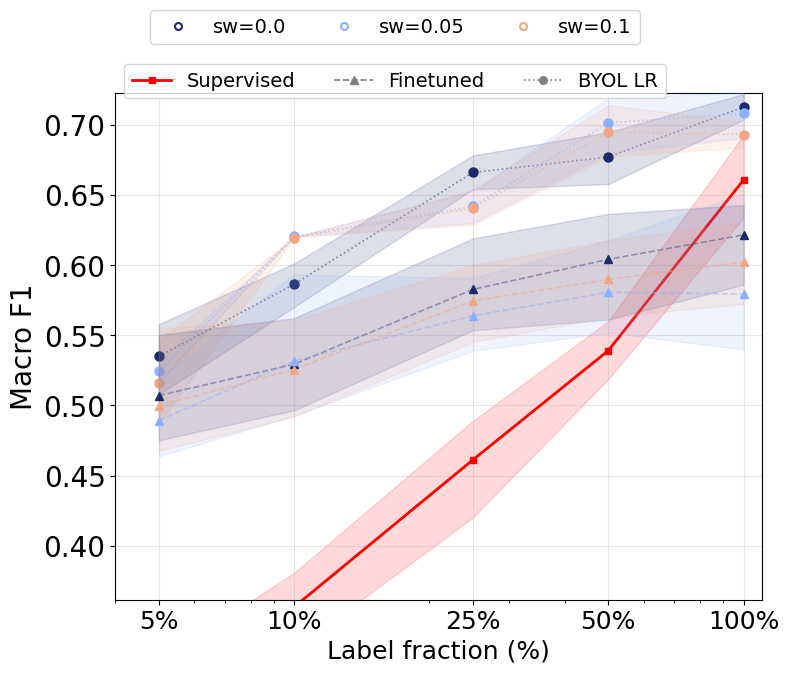

Saved → /users/mbredber/p3_SUPLAT/outputs/figures/classification/label_fraction_pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1_f1.pdf


In [28]:
# ── Compact model path summary ───────────────────────────────────────────────
def _lbl_matches(key, lbl):
    """Exact match or _unique_label suffix match (e.g. 'f=1.0 sw=0.05 (2)')."""
    return key == lbl or key.startswith(lbl + " (")

_ft_all = {**finetuning_points, **finetuning_frac_curves}
_byol_full = sum(1 for rd in _target_runs
                 if any(_lbl_matches(k, f"f={_parse_param(rd.name,'f')} sw={_parse_param(rd.name,'sw')}")
                        for k in all_frac_results))
_byol_sp   = sum(1 for rd in _target_runs
                 if any(_lbl_matches(k, f"f={_parse_param(rd.name,'f')} sw={_parse_param(rd.name,'sw')}")
                        for k in single_pt_results))
_byol_none = len(_target_runs) - _byol_full - _byol_sp
print(f"BYOL: {_byol_full} full-curve, {_byol_sp} 100%-only, {_byol_none} no data  |  "
      f"Baselines: {len(baseline_frac_results)} curves, {len(baseline_scalars)} scalars  |  "
      f"Finetuning: {len(_ft_all)} result(s)")


_metrics    = [("f1", "Macro F1"), ("recall", "Macro Recall"),
               ("accuracy", "Accuracy"), ("auc", "Macro AUC (OvR)")]

# ── Finetuning dicts — mode2 (BYOL finetuned) ───────────────────────────────
_EXCLUDE_F    = set()
_EXCLUDE_SW   = {'1.0', '0.5'}
_EXCLUDE_FRAC = set()   # x-axis label fractions to hide, e.g. {0.1, 0.2}

def _skip_label(lbl):
    f_m  = re.search(r'f=([\d.]+)', lbl)
    sw_m = re.search(r'sw=([\d.]+)', lbl)
    return (f_m and f_m.group(1) in _EXCLUDE_F) or (sw_m and sw_m.group(1) in _EXCLUDE_SW)

def _skip_ft_label(lbl):
    f_m = re.search(r'f=([\d.]+)', lbl)
    sw_m = re.search(r'sw=([\d.]+)', lbl)
    return (f_m and f_m.group(1) in _EXCLUDE_F) or (sw_m and sw_m.group(1) in _EXCLUDE_SW)

_all_frac_results_plot   = {k: v for k, v in all_frac_results.items()      if not _skip_label(k)}
_single_pt_results_plot  = {k: v for k, v in single_pt_results.items()     if not _skip_label(k)}
_all_frac_results_bin_plot = {k: v for k, v in all_frac_results_bin.items() if not _skip_label(k)}
_ft_points_plot    = {k: v for k, v in finetuning_points.items()      if not _skip_ft_label(k)}
_ft_curves_plot    = {k: v for k, v in finetuning_frac_curves.items() if not _skip_ft_label(k)}

# ── Discrete colour mapping: one colour per unique sw value ───────────────────
def _sw_from_label(lbl):
    m = re.search(r'sw=([\d.]+)', lbl)
    return float(m.group(1)) if m else None

def _f_from_label(lbl):
    m = re.search(r'f=([\d.]+)', lbl)
    return float(m.group(1)) if m else None

_all_run_labels = (list(_all_frac_results_plot.keys())
                   + [l for l in _single_pt_results_plot if l not in _all_frac_results_plot]
                   + list(_ft_points_plot.keys())
                   + [l for l in _ft_curves_plot if l not in _ft_points_plot])
_all_sw = [_sw_from_label(l) for l in _all_run_labels]
_sw_vals = [v for v in _all_sw if v is not None]
_sw_vals_unique = sorted(set(_sw_vals)) if _sw_vals else [0.0]
_sw_color_map  = {sw: _SW_PALETTE[i % len(_SW_PALETTE)] for i, sw in enumerate(_sw_vals_unique)}
_sw_color_list = [_sw_color_map[sw] for sw in _sw_vals_unique]

_run_colors    = {lbl: (_sw_color_map.get(sw, "grey") if sw is not None else "grey")
                  for lbl, sw in zip(_all_run_labels, _all_sw)}

_bl_labels  = list(baseline_frac_results.keys()) + list(baseline_scalars.keys())
_bl_all     = sorted(set(_bl_labels))
_bl_palette = ["red"] * max(len(_bl_all), 1)
_bl_colors  = {lbl: _bl_palette[i] for i, lbl in enumerate(_bl_all)}

xs_pct = [f * 100 for f in fractions]

_byol_f_vals = sorted(set(
    _f_from_label(lbl)
    for lbl in list(all_frac_results) + list(single_pt_results)
             + list(all_frac_results_bin)
             + list(finetuning_points) + list(finetuning_frac_curves)
    if _f_from_label(lbl) is not None
))
fractions_plot = [f for f in _byol_f_vals if f not in _EXCLUDE_FRAC]
xs_pct_plot    = [f * 100 for f in fractions_plot]

# ── Classifier priority for BYOL curves ───────────────────────────────────────
_BYOL_CLF_PRIORITY = ["GP", "LogReg", "LR", "RF", "KNN"]

def _pick_clf_val(frac_data, metric):
    for _clf in _BYOL_CLF_PRIORITY:
        if _clf in frac_data:
            return frac_data[_clf].get(metric, float("nan"))
    return float("nan")

# ── Auto-compute y-axis limits from data ─────────────────────────────────────
_metric_keys = [m for m, _ in _metrics]
_all_metric_vals = {m: [] for m in _metric_keys}
for _rl, _rd in _all_frac_results_plot.items():
    _f = _f_from_label(_rl)
    _sw_rl = _sw_from_label(_rl)
    _fs = (sorted(k for k in _rd if isinstance(k, (int, float)))
           if _sw_rl == 0.0 and _f == 1.0 else [_f])
    for _fc in _fs:
        for _m in _metric_keys:
            _v = _pick_clf_val(_rd.get(_fc, {}), _m)
            if _v == _v: _all_metric_vals[_m].append(_v)
for _rl, _rd in _all_frac_results_bin_plot.items():
    _f = _f_from_label(_rl)
    _sw_rl = _sw_from_label(_rl)
    _fs = (sorted(k for k in _rd if isinstance(k, (int, float)))
           if _sw_rl == 0.0 and _f == 1.0 else [_f])
    for _fc in _fs:
        for _m in _metric_keys:
            _v = _pick_clf_val(_rd.get(_fc, {}), _m)
            if _v == _v: _all_metric_vals[_m].append(_v)
for _bl_res in baseline_frac_results.values():
    for _fd in _bl_res.values():
        for _m in _metric_keys:
            _v = _fd.get("Supervised", {}).get(_m)
            if _v is not None: _all_metric_vals[_m].append(_v)
for _bl in baseline_scalars.values():
    for _m in _metric_keys:
        _v = _bl.get(_m)
        if _v is not None: _all_metric_vals[_m].append(_v)
for _rl, _fc in _ft_curves_plot.items():
    _f = _f_from_label(_rl)
    for _m in _metric_keys:
        _v = _fc.get(_f, {}).get(_m)
        if _v is not None: _all_metric_vals[_m].append(_v)
for _ft in _ft_points_plot.values():
    for _m in _metric_keys:
        _v = _ft.get(_m)
        if _v is not None: _all_metric_vals[_m].append(_v)
_ylim_top    = {_m: (max(_vs) + 0.01 if _vs else 1.0) for _m, _vs in _all_metric_vals.items()}
_ylim_bottom = {_m: _t * 0.5 for _m, _t in _ylim_top.items()}

_is_binary_tls = "_binary" in _tls

# ── Macro F1 plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
metric, ylabel = "f1", "Macro F1"

# ── Collect and draw BYOL LR pure points per sw ───────────────────────────────
if not _is_binary_tls:
    _byol_lr_by_sw = {}

    for run_lbl, res in _all_frac_results_plot.items():
        _f_byol = _f_from_label(run_lbl)
        _sw = _sw_from_label(run_lbl)
        if _f_byol is None or _sw is None:
            continue
        if _sw == 0.0:
            if _f_byol != 1.0:
                continue
            for _f_pt in sorted(k for k in res if isinstance(k, (int, float)) and k >= 0.05):
                _x = _f_pt * 100
                y = _pick_clf_val(res.get(_f_pt, {}), metric)
                _byol_lr_by_sw.setdefault(_sw, []).append((_x, y, run_lbl, res, _f_pt))
        else:
            _x = _f_byol * 100
            y = _pick_clf_val(res.get(1.0, {}), metric)
            _byol_lr_by_sw.setdefault(_sw, []).append((_x, y, run_lbl, res, 1.0))

    for sp_lbl, sp in _single_pt_results_plot.items():
        _f_byol = _f_from_label(sp_lbl) or 1.0
        _sw = _sw_from_label(sp_lbl)
        if _sw == 0.0:
            continue
        _x = _f_byol * 100
        v = sp.get(metric, float("nan"))
        if v == v and _sw is not None:
            _byol_lr_by_sw.setdefault(_sw, []).append((_x, v, sp_lbl, None, _f_byol))

    for _sw, _pts in sorted(_byol_lr_by_sw.items()):
        _pts_s = sorted(_pts, key=lambda p: p[0])
        _col   = _sw_color_map.get(_sw, "grey")
        _xs_c  = [p[0] for p in _pts_s]
        _ys_c  = [p[1] for p in _pts_s]
        ax.plot(_xs_c, _ys_c, linestyle=":", color=_col, linewidth=1.2, alpha=0.5, zorder=3)
        _lo_vals, _hi_vals, _has_ci = [], [], False
        for _x, y, run_lbl, res, _f_plot in _pts_s:
            ax.plot(_x, y, marker="o", markersize=6, linestyle="none",
                    color=_col, markeredgewidth=1.5, zorder=4)
            if res is not None and run_lbl in all_frac_ci:
                _ci = all_frac_ci[run_lbl].get(_f_plot, {}).get(metric, (0, 0))
                _lo_vals.append(y - _ci[0])
                _hi_vals.append(y + _ci[1])
                if _ci[0] > 0 or _ci[1] > 0:
                    _has_ci = True
            else:
                _lo_vals.append(y)
                _hi_vals.append(y)
        if _has_ci:
            ax.fill_between(_xs_c, _lo_vals, _hi_vals, color=_col, alpha=0.15, zorder=3)

# ── Collect and draw BYOL LR binary points per sw ─────────────────────────────
if _is_binary_tls:
    _byol_bin_by_sw = {}

    for run_lbl, res in _all_frac_results_bin_plot.items():
        _f_byol = _f_from_label(run_lbl)
        _sw = _sw_from_label(run_lbl)
        if _f_byol is None or _sw is None:
            continue
        if _sw == 0.0:
            if _f_byol != 1.0:
                continue
            for _f_pt in sorted(k for k in res if isinstance(k, (int, float)) and k >= 0.05):
                _x = _f_pt * 100
                y = _pick_clf_val(res.get(_f_pt, {}), metric)
                _byol_bin_by_sw.setdefault(_sw, []).append((_x, y, run_lbl, res, _f_pt))
        else:
            _x = _f_byol * 100
            y = _pick_clf_val(res.get(1.0, {}), metric)
            _byol_bin_by_sw.setdefault(_sw, []).append((_x, y, run_lbl, res, 1.0))

    for _sw, _pts in sorted(_byol_bin_by_sw.items()):
        _pts_s = sorted(_pts, key=lambda p: p[0])
        _col   = _sw_color_map.get(_sw, "grey")
        _xs_c  = [p[0] for p in _pts_s]
        _ys_c  = [p[1] for p in _pts_s]
        ax.plot(_xs_c, _ys_c, linestyle=":", color=_col, linewidth=1.2, alpha=0.5, zorder=3)
        _lo_vals, _hi_vals, _has_ci = [], [], False
        for _x, y, run_lbl, res, _f_plot in _pts_s:
            ax.plot(_x, y, marker="s", markersize=6, linestyle="none",
                    color=_col, markerfacecolor="none", markeredgewidth=1.5, zorder=4)
            if res is not None and run_lbl in all_frac_ci_bin:
                _ci = all_frac_ci_bin[run_lbl].get(_f_plot, {}).get(metric, (0, 0))
                _lo_vals.append(y - _ci[0])
                _hi_vals.append(y + _ci[1])
                if _ci[0] > 0 or _ci[1] > 0:
                    _has_ci = True
            else:
                _lo_vals.append(y)
                _hi_vals.append(y)
        if _has_ci:
            ax.fill_between(_xs_c, _lo_vals, _hi_vals, color=_col, alpha=0.15, zorder=3)

# Supervised baseline fraction curves with shaded std bands
for bl_lbl, bl_res in baseline_frac_results.items():
    bl_fs  = sorted(f for f in bl_res.keys() if f not in _EXCLUDE_FRAC and f >= 0.05)
    bl_xs  = [f * 100 for f in bl_fs]
    ys    = [bl_res[f]["Supervised"].get(metric, float("nan")) for f in bl_fs]
    ys_lo = [bl_res[f]["Supervised"].get(f"{metric}_lo") for f in bl_fs]
    ys_hi = [bl_res[f]["Supervised"].get(f"{metric}_hi") for f in bl_fs]
    col   = _bl_colors[bl_lbl]
    ax.plot(bl_xs, ys, linestyle="-",  color=col, linewidth=2.0, marker="s", markersize=5)
    _lo = [y - (lo if lo is not None else 0) for y, lo in zip(ys, ys_lo)]
    _hi = [y + (hi if hi is not None else 0) for y, hi in zip(ys, ys_hi)]
    if any(v is not None for v in ys_lo):
        ax.fill_between(bl_xs, _lo, _hi, color=col, alpha=0.15)

# Supervised baseline scalar fallback
for bl_lbl, bl in baseline_scalars.items():
    v = bl.get(metric, float("nan"))
    if v == v:
        col = _bl_colors[bl_lbl]
        ax.plot(100, v, marker="s", markersize=8, color=col, linestyle="none", zorder=5)
        _lo_v = bl.get(f"{metric}_lo")
        _hi_v = bl.get(f"{metric}_hi")
        if _lo_v is not None or _hi_v is not None:
            ax.errorbar(100, v, yerr=[[max(0, _lo_v or 0)], [max(0, _hi_v or 0)]], fmt="none", color=col,
                        capsize=4, linewidth=1.5)

# ── Collect and draw finetuned points per sw ──────────────────────────────────
_ft_by_sw = {}

for ft_lbl, ft_curve in _ft_curves_plot.items():
    _f_byol = _f_from_label(ft_lbl)
    _sw = _sw_from_label(ft_lbl)
    if _f_byol is None or _sw is None:
        continue
    if _sw == 0.0 and _f_byol == 1.0:
        # sw=0 label-free: expand internal frac_* sweep across all fraction keys
        for _f_pt in sorted(k for k in ft_curve if isinstance(k, (int, float)) and k >= 0.05):
            _x = _f_pt * 100
            _frac_data = ft_curve.get(_f_pt, {})
            y = _frac_data.get(metric, float("nan"))
            _ft_by_sw.setdefault(_sw, []).append((_x, y, ft_lbl, _frac_data))
    else:
        # sw>0: use 100% of its labeled subset, positioned at f_byol on x-axis
        _x = _f_byol * 100
        _frac_data = ft_curve.get(1.0, {})
        y = _frac_data.get(metric, float("nan"))
        _ft_by_sw.setdefault(_sw, []).append((_x, y, ft_lbl, _frac_data))

for ft_lbl, ft in _ft_points_plot.items():
    if ft_lbl in _ft_curves_plot:
        continue
    _f_byol = _f_from_label(ft_lbl) or 1.0
    _sw = _sw_from_label(ft_lbl)
    _x = _f_byol * 100
    v = ft.get(metric, float("nan"))
    if v == v and _sw is not None:
        _ft_by_sw.setdefault(_sw, []).append((_x, v, ft_lbl, ft))

for _sw, _pts in sorted(_ft_by_sw.items()):
    _pts_s = sorted(_pts, key=lambda p: p[0])
    _col   = _sw_color_map.get(_sw, "grey")
    _xs_c  = [p[0] for p in _pts_s]
    _ys_c  = [p[1] for p in _pts_s]
    ax.plot(_xs_c, _ys_c, linestyle="--", color=_col, linewidth=1.2, alpha=0.5, zorder=5)
    _lo_vals, _hi_vals, _has_ci = [], [], False
    for _x, y, ft_lbl, frac_data in _pts_s:
        ax.plot(_x, y, marker="^", markersize=6, linestyle="none", color=_col, zorder=6)
        _lo_v = frac_data.get(f"{metric}_lo")
        _hi_v = frac_data.get(f"{metric}_hi")
        _lo_vals.append(y - (_lo_v or 0))
        _hi_vals.append(y + (_hi_v or 0))
        if _lo_v is not None or _hi_v is not None:
            _has_ci = True
    if _has_ci:
        ax.fill_between(_xs_c, _lo_vals, _hi_vals, color=_col, alpha=0.15, zorder=5)

ax.set_xscale("log")
ax.set_xlim(xs_pct_plot[0] * 0.8, xs_pct_plot[-1] * 1.1)
ax.set_xlabel("Label fraction (%)", fontsize=18)
ax.set_ylabel(ylabel, fontsize=20)
ax.set_xticks(xs_pct_plot)
ax.set_xticklabels([f"{x:.0f}%" for x in xs_pct_plot], fontsize=18)
ax.tick_params(axis="y", labelsize=20)
ax.margins(y=0.05)
ax.set_ylim(bottom=_ylim_bottom.get(metric), top=_ylim_top.get(metric))
ax.grid(True, alpha=0.3)

plt.tight_layout()

# ── Legend ─────────────────────────────────────────────────────────────────────
_legend_handles = []
for lbl in baseline_frac_results:
    _legend_handles.append(
        plt.Line2D([0], [0], color=_bl_colors[lbl], linestyle="-",
                   linewidth=2.0, marker="s", markersize=5, label="Supervised"))
for lbl in baseline_scalars:
    _legend_handles.append(
        plt.Line2D([0], [0], color=_bl_colors[lbl], linestyle="none",
                   marker="s", markersize=8, label="Supervised (100% only)"))
if _ft_curves_plot or _ft_points_plot:
    _legend_handles.append(
        plt.Line2D([0], [0], color="grey", linestyle="--",
                   linewidth=1.2, marker="^", markersize=6, label="Finetuned"))
_byol_lr_marker = "s" if _is_binary_tls else "o"
_legend_handles.append(
    plt.Line2D([0], [0], color="grey", linestyle=":", linewidth=1.2,
               marker=_byol_lr_marker, markersize=5, markeredgewidth=1.5,
               label="BYOL LR"))
if _legend_handles:
    fig.legend(handles=_legend_handles, loc="upper center",
               ncol=len(_legend_handles), fontsize=14,
               bbox_to_anchor=(0.5, 1.04), frameon=True)

_sw_legend_handles = [
    plt.Line2D([0], [0], color=_sw_color_list[i], linestyle="none",
               marker="o", markersize=5, markerfacecolor="none", markeredgewidth=1.5,
               label=f"sw={v}")
    for i, v in enumerate(_sw_vals_unique)
]
if _sw_legend_handles:
    fig.legend(handles=_sw_legend_handles, loc="upper center",
               ncol=len(_sw_legend_handles), fontsize=14,
               bbox_to_anchor=(0.5, 1.13), frameon=True)

_out = f"{OUT_DIR}/label_fraction_{_ref_name}_f1.pdf"
plt.savefig(_out, bbox_inches="tight")
plt.show()
print(f"Saved → {_out}")


### 7.2 All Metrics

Four-panel plot (Macro F1, Macro Recall, Accuracy, Macro AUC) vs. label fraction. Saved as `label_fraction_{run}.png`.

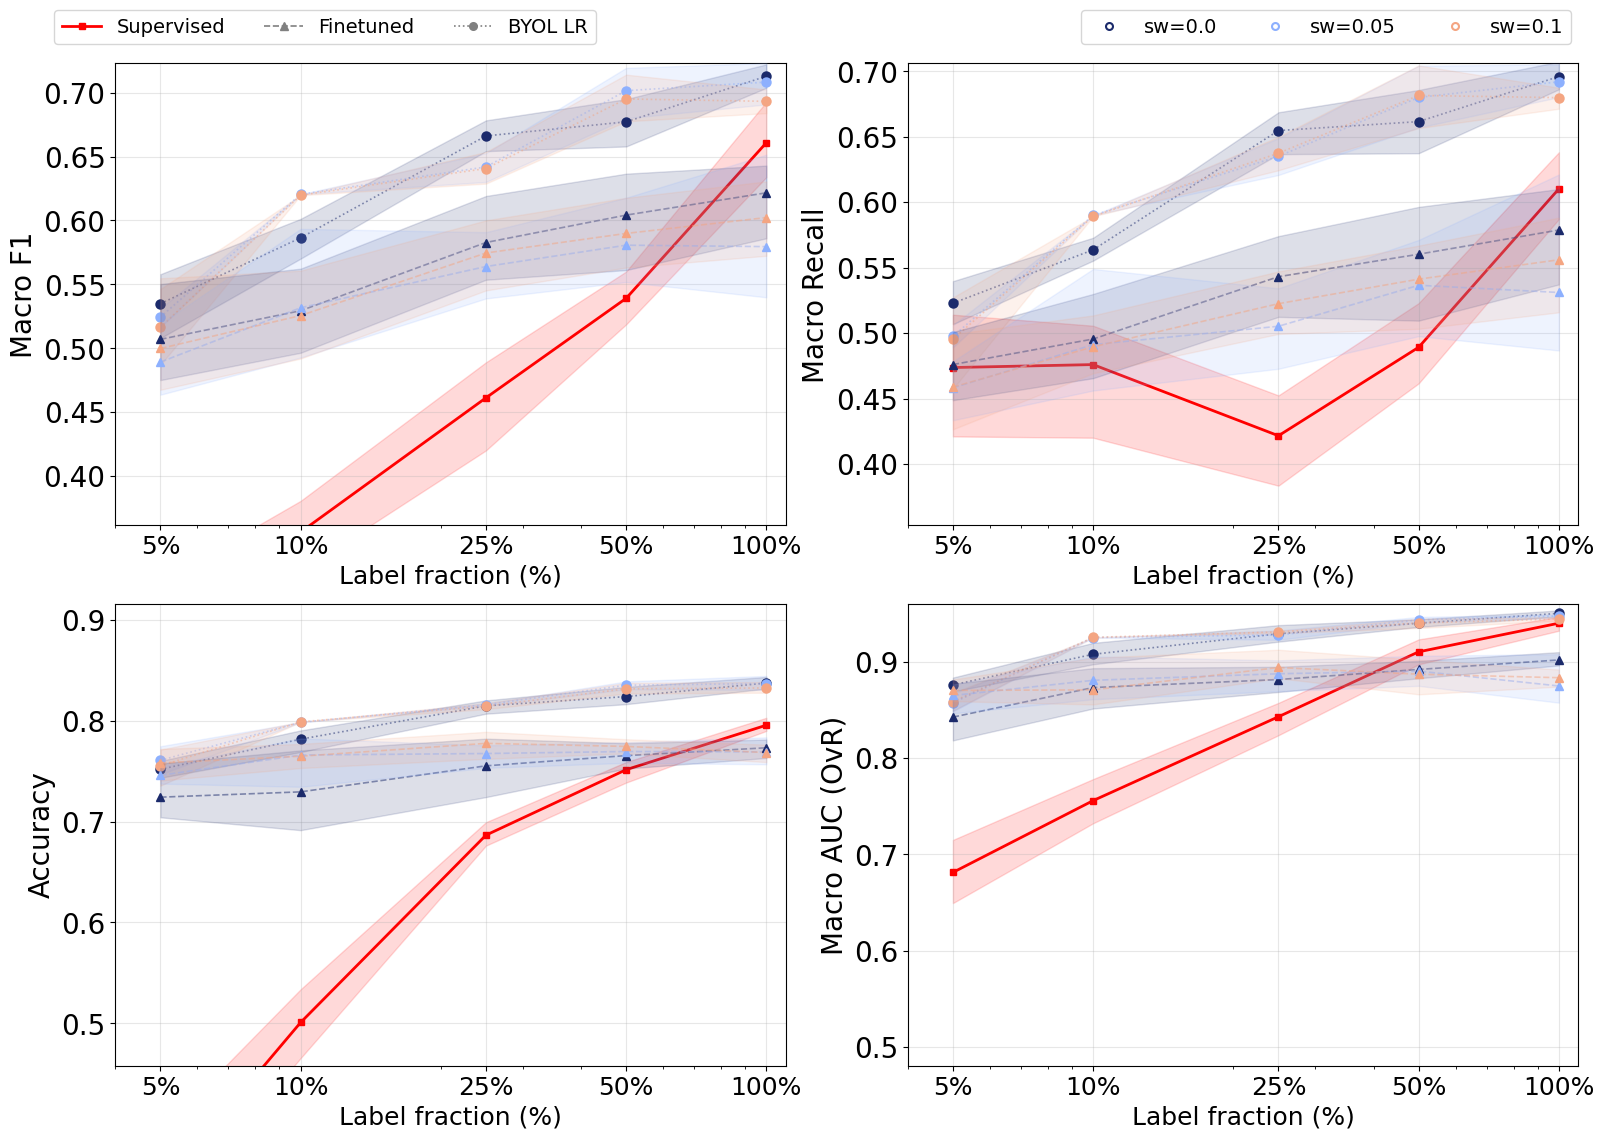

Saved → /users/mbredber/p3_SUPLAT/outputs/figures/classification/label_fraction_pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1.pdf


In [29]:
# ── All four metrics plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

_is_binary_tls = "_binary" in _tls

for ax, (metric, ylabel) in zip(axes, _metrics):

    # ── Collect BYOL LR pure points per sw ────────────────────────────────────
    # sw=0: BYOL is label-free; expand f=1 run's internal sweep across all fractions
    _byol_lr_by_sw = {}

    if not _is_binary_tls:
        for run_lbl, res in _all_frac_results_plot.items():
            _f_byol = _f_from_label(run_lbl)
            _sw = _sw_from_label(run_lbl)
            if _f_byol is None or _sw is None:
                continue
            if _sw == 0.0:
                if _f_byol != 1.0:
                    continue
                for _f_pt in sorted(k for k in res if isinstance(k, (int, float)) and k >= 0.05):
                    _x = _f_pt * 100
                    y = _pick_clf_val(res.get(_f_pt, {}), metric)
                    _byol_lr_by_sw.setdefault(_sw, []).append((_x, y, run_lbl, res, _f_pt))
            else:
                _x = _f_byol * 100
                y = _pick_clf_val(res.get(1.0, {}), metric)
                _byol_lr_by_sw.setdefault(_sw, []).append((_x, y, run_lbl, res, 1.0))

        for sp_lbl, sp in _single_pt_results_plot.items():
            _f_byol = _f_from_label(sp_lbl) or 1.0
            _sw = _sw_from_label(sp_lbl)
            if _sw == 0.0:
                continue
            _x = _f_byol * 100
            v = sp.get(metric, float("nan"))
            if v == v and _sw is not None:
                _byol_lr_by_sw.setdefault(_sw, []).append((_x, v, sp_lbl, None, _f_byol))

        # Draw BYOL LR pure: dotted line + hollow circles + shaded CI band
        for _sw, _pts in sorted(_byol_lr_by_sw.items()):
            _pts_s = sorted(_pts, key=lambda p: p[0])
            _col   = _sw_color_map.get(_sw, "grey")
            _xs_c  = [p[0] for p in _pts_s]
            _ys_c  = [p[1] for p in _pts_s]
            ax.plot(_xs_c, _ys_c, linestyle=":", color=_col, linewidth=1.2, alpha=0.5, zorder=3)
            _lo_vals, _hi_vals, _has_ci = [], [], False
            for _x, y, run_lbl, res, _f_plot in _pts_s:
                ax.plot(_x, y, marker="o", markersize=6, linestyle="none",
                        color=_col, markeredgewidth=1.5, zorder=4)
                if res is not None and run_lbl in all_frac_ci:
                    _ci = all_frac_ci[run_lbl].get(_f_plot, {}).get(metric, (0, 0))
                    _lo_vals.append(y - _ci[0])
                    _hi_vals.append(y + _ci[1])
                    if _ci[0] > 0 or _ci[1] > 0:
                        _has_ci = True
                else:
                    _lo_vals.append(y)
                    _hi_vals.append(y)
            if _has_ci:
                ax.fill_between(_xs_c, _lo_vals, _hi_vals, color=_col, alpha=0.15, zorder=3)

    # ── Collect BYOL LR binary points per sw ──────────────────────────────────
    _byol_bin_by_sw = {}

    if _is_binary_tls:
        for run_lbl, res in _all_frac_results_bin_plot.items():
            _f_byol = _f_from_label(run_lbl)
            _sw = _sw_from_label(run_lbl)
            if _f_byol is None or _sw is None:
                continue
            if _sw == 0.0:
                if _f_byol != 1.0:
                    continue
                for _f_pt in sorted(k for k in res if isinstance(k, (int, float)) and k >= 0.05):
                    _x = _f_pt * 100
                    y = _pick_clf_val(res.get(_f_pt, {}), metric)
                    _byol_bin_by_sw.setdefault(_sw, []).append((_x, y, run_lbl, res, _f_pt))
            else:
                _x = _f_byol * 100
                y = _pick_clf_val(res.get(1.0, {}), metric)
                _byol_bin_by_sw.setdefault(_sw, []).append((_x, y, run_lbl, res, 1.0))

        # Draw BYOL LR binary: dotted line + hollow squares + shaded CI band
        for _sw, _pts in sorted(_byol_bin_by_sw.items()):
            _pts_s = sorted(_pts, key=lambda p: p[0])
            _col   = _sw_color_map.get(_sw, "grey")
            _xs_c  = [p[0] for p in _pts_s]
            _ys_c  = [p[1] for p in _pts_s]
            ax.plot(_xs_c, _ys_c, linestyle=":", color=_col, linewidth=1.2, alpha=0.5, zorder=3)
            _lo_vals, _hi_vals, _has_ci = [], [], False
            for _x, y, run_lbl, res, _f_plot in _pts_s:
                ax.plot(_x, y, marker="s", markersize=6, linestyle="none",
                        color=_col, markerfacecolor="none", markeredgewidth=1.5, zorder=4)
                if res is not None and run_lbl in all_frac_ci_bin:
                    _ci = all_frac_ci_bin[run_lbl].get(_f_plot, {}).get(metric, (0, 0))
                    _lo_vals.append(y - _ci[0])
                    _hi_vals.append(y + _ci[1])
                    if _ci[0] > 0 or _ci[1] > 0:
                        _has_ci = True
                else:
                    _lo_vals.append(y)
                    _hi_vals.append(y)
            if _has_ci:
                ax.fill_between(_xs_c, _lo_vals, _hi_vals, color=_col, alpha=0.15, zorder=3)

    # Supervised baseline fraction curves with shaded std bands
    for bl_lbl, bl_res in baseline_frac_results.items():
        bl_fs  = sorted(f for f in bl_res.keys() if f not in _EXCLUDE_FRAC and f >= 0.05)
        bl_xs  = [f * 100 for f in bl_fs]
        ys    = [bl_res[f]["Supervised"].get(metric, float("nan")) for f in bl_fs]
        ys_lo = [bl_res[f]["Supervised"].get(f"{metric}_lo") for f in bl_fs]
        ys_hi = [bl_res[f]["Supervised"].get(f"{metric}_hi") for f in bl_fs]
        col   = _bl_colors[bl_lbl]
        ax.plot(bl_xs, ys, linestyle="-",  color=col, linewidth=2.0, marker="s", markersize=5)
        _lo = [y - (lo if lo is not None else 0) for y, lo in zip(ys, ys_lo)]
        _hi = [y + (hi if hi is not None else 0) for y, hi in zip(ys, ys_hi)]
        if any(v is not None for v in ys_lo):
            ax.fill_between(bl_xs, _lo, _hi, color=col, alpha=0.15)

    # Supervised baseline scalar fallback
    for bl_lbl, bl in baseline_scalars.items():
        v = bl.get(metric, float("nan"))
        if v == v:
            col = _bl_colors[bl_lbl]
            ax.plot(100, v, marker="s", markersize=8, color=col, linestyle="none", zorder=5)
            _lo_v = bl.get(f"{metric}_lo")
            _hi_v = bl.get(f"{metric}_hi")
            if _lo_v is not None or _hi_v is not None:
                ax.errorbar(100, v, yerr=[[max(0, _lo_v or 0)], [max(0, _hi_v or 0)]], fmt="none", color=col,
                            capsize=4, linewidth=1.5)

    # ── Collect finetuned points per sw ───────────────────────────────────────
    _ft_by_sw = {}

    for ft_lbl, ft_curve in _ft_curves_plot.items():
        _f_byol = _f_from_label(ft_lbl)
        _sw = _sw_from_label(ft_lbl)
        if _f_byol is None or _sw is None:
            continue
        if _sw == 0.0 and _f_byol == 1.0:
            # sw=0 label-free: expand internal frac_* sweep across all fraction keys
            for _f_pt in sorted(k for k in ft_curve if isinstance(k, (int, float)) and k >= 0.05):
                _x = _f_pt * 100
                _frac_data = ft_curve.get(_f_pt, {})
                y = _frac_data.get(metric, float("nan"))
                _ft_by_sw.setdefault(_sw, []).append((_x, y, ft_lbl, _frac_data))
        else:
            # sw>0: use 100% of its labeled subset, positioned at f_byol on x-axis
            _x = _f_byol * 100
            _frac_data = ft_curve.get(1.0, {})
            y = _frac_data.get(metric, float("nan"))
            _ft_by_sw.setdefault(_sw, []).append((_x, y, ft_lbl, _frac_data))

    for ft_lbl, ft in _ft_points_plot.items():
        if ft_lbl in _ft_curves_plot:
            continue
        _f_byol = _f_from_label(ft_lbl) or 1.0
        _sw = _sw_from_label(ft_lbl)
        _x = _f_byol * 100
        v = ft.get(metric, float("nan"))
        if v == v and _sw is not None:
            _ft_by_sw.setdefault(_sw, []).append((_x, v, ft_lbl, ft))

    # Draw finetuned: dashed line + filled circles + shaded CI band
    for _sw, _pts in sorted(_ft_by_sw.items()):
        _pts_s = sorted(_pts, key=lambda p: p[0])
        _col   = _sw_color_map.get(_sw, "grey")
        _xs_c  = [p[0] for p in _pts_s]
        _ys_c  = [p[1] for p in _pts_s]
        ax.plot(_xs_c, _ys_c, linestyle="--", color=_col, linewidth=1.2, alpha=0.5, zorder=5)
        _lo_vals, _hi_vals, _has_ci = [], [], False
        for _x, y, ft_lbl, frac_data in _pts_s:
            ax.plot(_x, y, marker="^", markersize=6, linestyle="none", color=_col, zorder=6)
            _lo_v = frac_data.get(f"{metric}_lo")
            _hi_v = frac_data.get(f"{metric}_hi")
            _lo_vals.append(y - (_lo_v or 0))
            _hi_vals.append(y + (_hi_v or 0))
            if _lo_v is not None or _hi_v is not None:
                _has_ci = True
        if _has_ci:
            ax.fill_between(_xs_c, _lo_vals, _hi_vals, color=_col, alpha=0.15, zorder=5)

    ax.set_xscale("log")
    ax.set_xlim(xs_pct_plot[0] * 0.8, xs_pct_plot[-1] * 1.1)
    ax.set_xlabel("Label fraction (%)", fontsize=18)
    ax.set_ylabel(ylabel, fontsize=20)
    ax.set_xticks(xs_pct_plot)
    ax.set_xticklabels([f"{x:.0f}%" for x in xs_pct_plot], fontsize=18)
    ax.tick_params(axis="y", labelsize=20)
    ax.margins(y=0.05)
    ax.set_ylim(bottom=_ylim_bottom.get(metric), top=_ylim_top.get(metric))
    ax.grid(True, alpha=0.3)

plt.tight_layout()

# ── Legend ────────────────────────────────────────────────────────────────────
_legend_handles = []
for lbl in baseline_frac_results:
    _legend_handles.append(
        plt.Line2D([0], [0], color=_bl_colors[lbl], linestyle="-",
                   linewidth=2.0, marker="s", markersize=5, label="Supervised"))
for lbl in baseline_scalars:
    _legend_handles.append(
        plt.Line2D([0], [0], color=_bl_colors[lbl], linestyle="none",
                   marker="s", markersize=8, label="Supervised (100% only)"))
if _ft_curves_plot or _ft_points_plot:
    _legend_handles.append(
        plt.Line2D([0], [0], color="grey", linestyle="--",
                   linewidth=1.2, marker="^", markersize=6, label="Finetuned"))
_byol_lr_marker = "s" if _is_binary_tls else "o"
_legend_handles.append(
    plt.Line2D([0], [0], color="grey", linestyle=":", linewidth=1.2,
               marker=_byol_lr_marker, markersize=5, markeredgewidth=1.5,
               label="BYOL LR"))
if _legend_handles:
    fig.legend(handles=_legend_handles, loc="upper left",
               ncol=len(_legend_handles), fontsize=14,
               bbox_to_anchor=(0.02, 1.04), frameon=True)

_sw_legend_handles = [
    plt.Line2D([0], [0], color=_sw_color_list[i], linestyle="none",
               marker="o", markersize=5, markerfacecolor="none", markeredgewidth=1.5,
               label=f"sw={v}")
    for i, v in enumerate(_sw_vals_unique)
]
if _sw_legend_handles:
    fig.legend(handles=_sw_legend_handles, loc="upper right",
               ncol=len(_sw_legend_handles), fontsize=14,
               bbox_to_anchor=(0.98, 1.04), frameon=True)

_out = f"{OUT_DIR}/label_fraction_{_ref_name}.pdf"
plt.savefig(_out, bbox_inches="tight")
plt.show()
print(f"Saved → {_out}")

## 8. Confusion Matrix

Row-normalised confusion matrices comparing Supervised, fine-tuned BYOL, and BYOL LR. Each cell shows the mean across diagonal (data_seed = training_seed) runs.

- **8.1** Single-run comparison for the reference checkpoint — full three-column layout
- **8.2** SW sweep comparison (sw = 0.0, 0.05, 0.1) — each cell divided into sub-rows, one per sw value

Configure `byol_classifier` and `baseline_model` in `CM_CONFIG` (Section 0).

### 8.1 Single-Run Comparison

Loads predicted probabilities and labels for the reference checkpoint, the matching fine-tuning run, and the supervised baseline. Plots a three-column row-normalised confusion matrix (Supervised | FT | BYOL LR), with mean ± CI across diagonal seeds.

In [30]:
_ls      = CM_CONFIG["eval_label_set"]   # what label set to evaluate on
_tls_cm  = CM_CONFIG.get("eval_label_set", CONFIG["train_label_set"])  # CM always uses pure-set classifier

_byol_clf  = CM_CONFIG["byol_classifier"]
_run_dir   = Path(CONFIG["checkpoint"]).parent
_clf_short = {"random_forest": "rf", "knn": "knn", "linear_probe": "lr"}.get(_byol_clf, _byol_clf)

_cw     = CONFIG.get("class_weight", "")
_cw_tag = f"cw{_cw}" if _cw else "cwNone"

def _cm_clf_dir(fd):
    _n = fd / "data" / "classifiers" / "simple_downstream" / f"{_tls_cm}_{_cw_tag}"
    _o = fd / "data" / "classifiers" / "simple_downstream" / _tls_cm
    return _n if _n.exists() else _o

# Always load from the train_label_set classifier directory (consistent with Sections 5–6)
_clf_dir = _cm_clf_dir(_run_dir)
print(f"Classifier dir : {_clf_dir}  (trained on '{_tls_cm}')")
print(f"Eval label set : {_ls}")

_PURE_SETS_CM = {"initial_pure", "classical_pure", "morphology_pure", "environment_pure", "full_pure"}

y_te_byol = y_pred_byol = _cm_byol_probs5 = None  # sentinel: set only on success

# ── CV mode: concatenate predictions from all non-overlapping folds ───────────
_fold_dirs_43 = _get_fold_dirs(_run_dir)
if len(_fold_dirs_43) > 1:
    _all_probs, _all_labels = [], []
    for _fd in _fold_dirs_43:
        _fd_pp = _cm_clf_dir(_fd) / f"{_clf_short}_projections_test_probs.npy"
        _fd_lp = _cm_clf_dir(_fd) / "projections_test_labels.npy"
        if _fd_pp.exists() and _fd_lp.exists():
            _all_probs.append(np.load(_fd_pp))
            _all_labels.append(np.load(_fd_lp))
    if _all_probs:
        _probs_full  = np.concatenate(_all_probs,  axis=0)
        _labels_full = np.concatenate(_all_labels, axis=0)
        print(f"CV: concatenated {len(_all_probs)}/{len(_fold_dirs_43)} folds "
              f"→ {len(_probs_full)} test samples")
    else:
        _probs_full = _labels_full = None
        print("No CV fold predictions found — re-run train_byol_classifiers.py --cv-fold K")
else:
    # Non-CV: load from single clf dir
    _probs_path  = _clf_dir / f"{_clf_short}_projections_test_probs.npy"
    _labels_path = _clf_dir / "projections_test_labels.npy"
    if _probs_path.exists() and _labels_path.exists():
        _probs_full  = np.load(_probs_path)
        _labels_full = np.load(_labels_path)
    else:
        _probs_full = _labels_full = None
        print(
            f"Probabilities or labels not found for '{_clf_short}' trained on '{_tls_cm}' — skipping confusion matrix.\n"
            f"  {_probs_path}\n"
            f"  {_labels_path}\n"
            f"Re-run train_byol_classifiers.py with --label-set {_tls_cm}."
        )

if _probs_full is not None and _labels_full is not None:
    if _labels_full.ndim == 1:
        _cm_byol_probs5 = _probs_full
        y_te_byol   = _labels_full
        y_pred_byol = _probs_full.argmax(axis=1)
    elif _ls in _PURE_SETS_CM:
        _eval_cols  = LABEL_SETS[_ls]
        _train_cols = LABEL_SETS[_tls_cm]
        _col_map    = [_train_cols.index(c) for c in _eval_cols if c in _train_cols]
        _ip_mask    = _labels_full[:, _eval_cols].sum(axis=1) == 1
        _cm_byol_probs5 = _probs_full[_ip_mask][:, _col_map]
        y_te_byol   = _labels_full[_ip_mask][:, _eval_cols].argmax(axis=1)
        y_pred_byol = _cm_byol_probs5.argmax(axis=1)
    else:
        _cm_byol_probs5 = _probs_full
        y_te_byol   = _labels_full
        y_pred_byol = (_probs_full >= 0.5).astype(int)

    print(f"Derived predictions via cross-eval: {len(y_te_byol)} test samples")
    print(f"BYOL {_byol_clf}: N_test={len(y_te_byol)}")

Classifier dir : ../outputs/byol_runs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1/data_seed_2/training_seed_2/data/classifiers/simple_downstream/initial_pure_cwNone  (trained on 'initial_pure')
Eval label set : initial_pure
CV: concatenated 5/5 folds → 6695 test samples
Derived predictions via cross-eval: 6695 test samples
BYOL linear_probe: N_test=6695


In [31]:
_bdir = Path(CONFIG["baselines_dir"])
_bsearch_dir = _bdir / "without_generative" if (_bdir / "without_generative").exists() else _bdir
_tag  = CM_CONFIG["baseline_model"]
n_cls = len([ALL_CLASS_NAMES[i] for i in LABEL_SETS[_ls]])

_cw     = CONFIG.get("class_weight", "")
_cw_tag = f"cw{_cw}" if _cw else "cwNone"

# Pick latest timestamped dir that matches label set + exact class-weight tag
_bl_top_dirs = sorted(
    d for d in _bsearch_dir.iterdir()
    if d.is_dir() and (
        d.name.endswith(f"_{_tls_cm}_{_cw_tag}") or f"_{_tls_cm}_{_cw_tag}_" in d.name
        # Also match lowercase + optional 0.0 suffix (old job-script naming)
        or d.name.lower().endswith(f"_{_tls_cm}_{_cw_tag.lower()}") or f"_{_tls_cm}_{_cw_tag.lower()}_" in d.name.lower()
        or d.name.lower().endswith(f"_{_tls_cm}_{_cw_tag.lower()}0.0") or f"_{_tls_cm}_{_cw_tag.lower()}0.0_" in d.name.lower()
    )
)
# Keep only paired runs (training_seed == data_seed + 1); old-style dirs without _sN_dsN are kept as-is
def _is_matched_bl(d):
    _m = re.search(r'_s(\d+)_ds(\d+)$', d.name)
    return _m is None or int(_m.group(1)) == int(_m.group(2)) or int(_m.group(1)) == int(_m.group(2)) + 1
_bl_top_dirs = [d for d in _bl_top_dirs if _is_matched_bl(d)]
if not _bl_top_dirs:
    print(f"Warning: no baseline dir matching '_{_tls_cm}_{_cw_tag}' found in {_bsearch_dir}")
    print("  Baseline column will be omitted from confusion matrix.")
    _cm_base_mean = _cm_base_lo = _cm_base_hi = None
    _base_metrics_agg = {k: (float("nan"), None, None) for k in ("F1", "AUC", "Acc", "Recall")}
    _base_run_norms = []
else:
    print(f"Baseline dirs ({len(_bl_top_dirs)})  Eval : {_ls}")

    _run_paths = sorted(p for _d in _bl_top_dirs for p in _d.rglob("test_probs.npy"))
    _candidates = [p.parent for p in _run_paths
                   if _tag in str(p.parent).lower()
                   and (p.parent / "test_labels.npy").exists()]
    if not _candidates:
        print(f"Warning: no baseline run found for '{_tag}' in {_latest_bl_dir}")
        _cm_base_mean = _cm_base_lo = _cm_base_hi = None
        _base_metrics_agg = {k: (float("nan"), None, None) for k in ("F1", "AUC", "Acc", "Recall")}
        _base_run_norms = []
    else:
        _base_run_norms   = []   # per-run normalised confusion matrices
        _base_run_metrics = []   # per-run source-level metrics dicts

        for _brun in sorted(_candidates):
            _probs_raw  = np.load(_brun / "test_probs.npy")
            _labels_raw = np.load(_brun / "test_labels.npy")
            # Handle both 5-class (initial_pure) and 20-class (full) outputs
            if _probs_raw.shape[1] == 20:
                _pure_mask = _labels_raw[:, :5].sum(axis=1) == 1
                _probs_b   = _probs_raw[_pure_mask, :5]
                _labels_b  = _labels_raw[_pure_mask, :5]
            elif _probs_raw.shape[1] == n_cls:
                _pure_mask = _labels_raw.sum(axis=1) == 1
                _probs_b   = _probs_raw[_pure_mask]
                _labels_b  = _labels_raw[_pure_mask]
            else:
                continue

            # Load saved one-hot preds (same predictions used in training evaluation);
            # fall back to argmax-as-onehot if file missing
            _preds_path = _brun / "test_preds.npy"
            if _preds_path.exists():
                _preds_b = np.load(_preds_path)[_pure_mask]
                if _preds_b.shape[1] == 20:
                    _preds_b = _preds_b[:, :5]
            else:
                _yp_int  = _probs_b.argmax(axis=1)
                _preds_b = np.eye(n_cls, dtype=int)[_yp_int]

            _y_true_b = _labels_b.argmax(axis=1)   # integer labels for CM + metrics
            _y_pred_b = _preds_b.argmax(axis=1)

            from sklearn.metrics import confusion_matrix as _cm, f1_score as _f1s, \
                roc_auc_score as _aucs, accuracy_score as _accs, recall_score as _recs
            from sklearn.preprocessing import label_binarize as _lbin
            _cm_raw  = _cm(_y_true_b, _y_pred_b, labels=list(range(n_cls)))
            _row_sum = _cm_raw.sum(axis=1, keepdims=True).clip(min=1)
            _base_run_norms.append(_cm_raw / _row_sum)
            _y_bin = _lbin(_y_true_b, classes=list(range(n_cls)))
            _probs_b_full = _probs_b if _probs_b.shape[1] == n_cls else np.zeros((len(_probs_b), n_cls))
            try:
                _auc_val = float(_aucs(_y_bin, _probs_b, multi_class="ovr", average="macro"))
            except Exception:
                _auc_val = float("nan")
            _base_run_metrics.append({
                "F1":     float(_f1s(_y_true_b, _y_pred_b, average="macro", zero_division=0)),
                "AUC":    _auc_val,
                "Acc":    float(_accs(_y_true_b, _y_pred_b)),
                "Recall": float(_recs(_y_true_b, _y_pred_b, average="macro", zero_division=0)),
            })

        print(f"Baseline {_tag}: {len(_base_run_norms)} run(s)")
        print(f"  n_test: {len(_y_true_b)}")

        # ── Aggregate across runs ──────────────────────────────────────────────────────
        _cm_base_mean = np.mean(_base_run_norms, axis=0)
        if len(_base_run_norms) > 1:
            _cm_base_lo, _cm_base_hi = _ci68(np.stack(_base_run_norms), axis=0)
        else:
            _cm_base_lo = _cm_base_hi = None
        def _magg(k):
            vals = [m[k] for m in _base_run_metrics]
            mean = float(np.mean(vals))
            if len(vals) > 1:
                lo, hi = _ci68(vals)
                return mean, float(lo), float(hi)
            return mean, None, None
        _base_metrics_agg = {k: _magg(k) for k in ("F1", "AUC", "Acc", "Recall")}

Baseline dirs (6)  Eval : initial_pure


Baseline enb0: 18 run(s)
  n_test: 2004


Aggregating over 5 fold(s)
BYOL LR (lr): 5 fold(s)/seed(s)


Finetuning (initial_pure_cwNone_mode2_lr1e-2_ep40): 25 run(s) across folds ['cross_val_0', 'cross_val_1', 'cross_val_2', 'cross_val_3', 'cross_val_4']

Metric                  Base               Finetuned                 BYOL LR
----------------------------------------------------------------------
F1           0.63+0.02/-0.01         0.60+0.07/-0.06         0.72+0.02/-0.02
AUC          0.93+0.01/-0.00         0.89+0.04/-0.03         0.95+0.00/-0.00
Acc          0.81+0.01/-0.01         0.77+0.03/-0.05         0.84+0.01/-0.00
Recall       0.59+0.02/-0.02         0.56+0.06/-0.05         0.69+0.02/-0.02


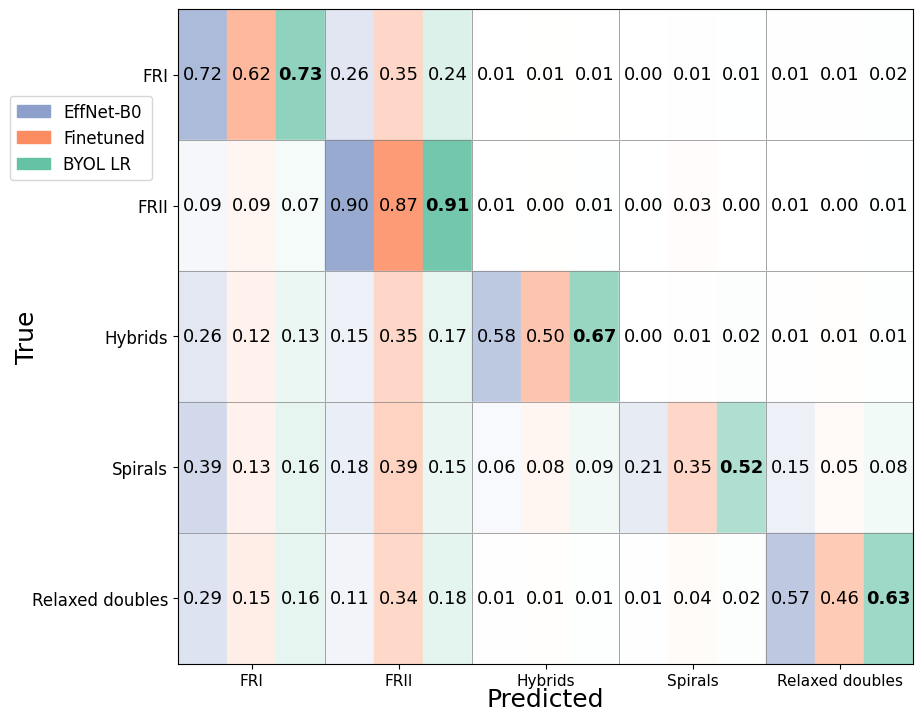

In [32]:
if y_te_byol is None:
    print("Skipping confusion matrix — BYOL predictions unavailable (see cell above).")
else:
    _class_names = [ALL_CLASS_NAMES[i] for i in LABEL_SETS[_ls]]
    n_cls = len(_class_names)

    # ── BYOL LR — aggregate across CV folds (or seed dirs for non-CV) ────────
    _seed_dirs = _get_fold_dirs(_run_dir)
    print(f"Aggregating over {len(_seed_dirs)} {'fold(s)' if len(_seed_dirs) > 1 else 'run(s)'}")

    _byol_run_norms, _byol_run_metrics = [], []
    for _sd in _seed_dirs:
        _sd_clf_dir_new = _sd / "data" / "classifiers" / "simple_downstream" / f"{_tls_cm}_{_cw_tag}"
        _sd_clf_dir_old = _sd / "data" / "classifiers" / "simple_downstream" / _tls_cm
        _sd_clf_dir     = _sd_clf_dir_new if _sd_clf_dir_new.exists() else _sd_clf_dir_old
        _sd_probs_path  = _sd_clf_dir / f"{_clf_short}_projections_test_probs.npy"
        _sd_labels_path = _sd_clf_dir / "projections_test_labels.npy"
        if not (_sd_probs_path.exists() and _sd_labels_path.exists()):
            continue
        _sd_probs  = np.load(_sd_probs_path)
        _sd_labels = np.load(_sd_labels_path)
        # Cross-eval: mirrors the logic in cell 24
        if _sd_labels.ndim == 1:
            _sd_probs5 = _sd_probs
            _sd_yt     = _sd_labels
            _sd_yp     = _sd_probs.argmax(axis=1)
        elif _ls in _PURE_SETS_CM:
            _eval_cols  = LABEL_SETS[_ls]
            _train_cols = LABEL_SETS[_tls_cm]
            _col_map    = [_train_cols.index(c) for c in _eval_cols if c in _train_cols]
            _ip_mask    = _sd_labels[:, _eval_cols].sum(axis=1) == 1
            _sd_probs5  = _sd_probs[_ip_mask][:, _col_map]
            _sd_yt      = _sd_labels[_ip_mask][:, _eval_cols].argmax(axis=1)
            _sd_yp      = _sd_probs5.argmax(axis=1)
        else:
            _sd_probs5 = _sd_probs
            _sd_yt     = _sd_labels
            _sd_yp     = (_sd_probs >= 0.5).astype(int)
        _sd_cm_r = confusion_matrix(_sd_yt, _sd_yp, labels=list(range(n_cls)))
        _byol_run_norms.append(_sd_cm_r / _sd_cm_r.sum(axis=1, keepdims=True).clip(min=1))
        _sd_y_bin = label_binarize(_sd_yt, classes=list(range(n_cls)))
        try:
            _sd_auc = float(roc_auc_score(_sd_y_bin, _sd_probs5, multi_class="ovr", average="macro"))
        except Exception:
            _sd_auc = float("nan")
        _byol_run_metrics.append({
            "F1":     float(f1_score(_sd_yt, _sd_yp, average="macro", zero_division=0)),
            "AUC":    _sd_auc,
            "Acc":    float(accuracy_score(_sd_yt, _sd_yp)),
            "Recall": float(recall_score(_sd_yt, _sd_yp, average="macro", zero_division=0)),
        })

    print(f"BYOL LR ({_clf_short}): {len(_byol_run_norms)} fold(s)/seed(s)")
    cm_b_n = np.mean(_byol_run_norms, axis=0)
    if len(_byol_run_norms) > 1:
        cm_b_lo, cm_b_hi = _ci68(np.stack(_byol_run_norms), axis=0)
    else:
        cm_b_lo = cm_b_hi = None

    def _byolmagg(k):
        vals = [m[k] for m in _byol_run_metrics]
        mean = float(np.mean(vals))
        if len(vals) > 1:
            lo, hi = _ci68(vals)
            return mean, float(lo), float(hi)
        return mean, None, None
    _byol_metrics_agg = {k: _byolmagg(k) for k in ("F1", "AUC", "Acc", "Recall")}

    # ── Finetuning — collect runs across all fold/seed dirs ───────────────────
    _cw_tag_ft = f"cw{_cw}" if _cw else "cwNone"
    _ft_spec   = CONFIG['finetuning_spec']   # mode2 (better than mode3)
    _ft_type   = f"{_tls}_{_cw_tag_ft}{_es_tag}_{_ft_spec}"
    _ft_run_norms, _ft_run_metrics = [], []
    _ft_seeds_found = []
    for _sd in _seed_dirs:
        _ft_dir = _sd / "data" / "classifiers" / "finetuning" / _ft_type
        if not _ft_dir.exists():
            _ft_dir_alt = _sd / "data" / "classifiers" / "finetuning" / f"{_tls}_{_cw_tag_ft}0.0{_es_tag}_{_ft_spec}"
            if _ft_dir_alt.exists():
                _ft_dir = _ft_dir_alt
        if not _ft_dir.exists():
            continue
        _ft_seeds_found.append(_sd.name)
        for _rp in sorted(_ft_dir.glob("frac_1.00/run*/test_probs.npy")):
            _rl = _rp.parent / "test_labels.npy"
            if not _rl.exists():
                continue
            _p = np.load(_rp); _l = np.load(_rl)
            if _l.ndim == 2 and _l.shape[1] >= 5:
                _mask = _l[:, :5].sum(axis=1) == 1
                _p, _l = _p[_mask, :5], _l[_mask, :5]
            _yt = _l.argmax(axis=1) if _l.ndim == 2 else _l
            _yp = _p.argmax(axis=1)
            _cm_r = confusion_matrix(_yt, _yp, labels=list(range(n_cls)))
            _ft_run_norms.append(_cm_r / _cm_r.sum(axis=1, keepdims=True).clip(min=1))
            _ft_run_metrics.append({
                "F1":     f1_score(_yt, _yp, average="macro", zero_division=0),
                "AUC":    roc_auc_score(
                              label_binarize(_yt, classes=list(range(n_cls))),
                              _p, multi_class="ovr", average="macro"),
                "Acc":    accuracy_score(_yt, _yp),
                "Recall": recall_score(_yt, _yp, average="macro", zero_division=0),
            })

    if _ft_run_norms:
        cm_ft_n = np.mean(_ft_run_norms, axis=0)
        if len(_ft_run_norms) > 1:
            cm_ft_lo, cm_ft_hi = _ci68(np.stack(_ft_run_norms), axis=0)
        else:
            cm_ft_lo = cm_ft_hi = None
        def _ftmagg(k):
            vals = [m[k] for m in _ft_run_metrics]
            mean = float(np.mean(vals))
            if len(vals) > 1:
                lo, hi = _ci68(vals)
                return mean, float(lo), float(hi)
            return mean, None, None
        _ft_metrics = {k: _ftmagg(k) for k in ("F1", "AUC", "Acc", "Recall")}
        print(f"Finetuning ({_ft_type}): {len(_ft_run_norms)} run(s) across folds {_ft_seeds_found}")
    else:
        cm_ft_n = cm_ft_lo = cm_ft_hi = None
        _ft_metrics = {}
        print(f"Finetuning: no predictions found for '{_ft_type}' in any fold/seed dir")

    # ── Supervised baseline ───────────────────────────────────────────────────────
    cm_s_n  = _cm_base_mean
    cm_s_lo = _cm_base_lo
    cm_s_hi = _cm_base_hi

    # ── Metrics table ─────────────────────────────────────────────────────────────
    print(f"\n{'Metric':<8}  {'Base':>18}  {'Finetuned':>22}  {'BYOL LR':>22}")
    print("-" * 70)
    for k in ["F1", "AUC", "Acc", "Recall"]:
        mu_by, lo_by, hi_by = _byol_metrics_agg[k]
        s_byol = f"{mu_by:.2f}+{hi_by:.2f}/-{lo_by:.2f}" if lo_by is not None else f"{mu_by:.2f}"

        mu_b, lo_b, hi_b = _base_metrics_agg[k]
        if mu_b != mu_b:
            s_base = "N/A"
        elif lo_b is not None:
            s_base = f"{mu_b:.2f}+{hi_b:.2f}/-{lo_b:.2f}"
        else:
            s_base = f"{mu_b:.2f}"

        if _ft_metrics:
            mu_f, lo_f, hi_f = _ft_metrics[k]
            s_ft = f"{mu_f:.2f}+{hi_f:.2f}/-{lo_f:.2f}" if lo_f is not None else f"{mu_f:.2f}"
        else:
            s_ft = "N/A"
        print(f"{k:<8}  {s_base:>18}  {s_ft:>22}  {s_byol:>22}")

    NO_ERROR_BARS = True  # hide ± CI annotations
    # ── Plot ──────────────────────────────────────────────────────────────────────
    from matplotlib.colors import LinearSegmentedColormap as _LSC
    _mk_cmap = lambda h: _LSC.from_list("", ["white", h])
    cmap_b  = _mk_cmap("#66c2a5")  # teal — BYOL linear probe
    cmap_ft = _mk_cmap("#fc8d62")  # coral — Finetuned
    cmap_s  = _mk_cmap("#8da0cb")  # dusty blue — Supervised baseline

    _w = 1 / 3  # width of each third

    _clf_display = {"linear_probe": "LR", "random_forest": "RF", "knn": "KNN"}.get(
        CM_CONFIG["byol_classifier"], CM_CONFIG["byol_classifier"])

    fig, ax = plt.subplots(figsize=(n_cls * 1.5 + 3, n_cls * 1.5 + 1))
    plt.subplots_adjust(left=0.28, right=0.98)
    ax.set_xlim(0, n_cls); ax.set_ylim(0, n_cls)
    ax.invert_yaxis()

    _n_runs_base = len(_base_run_norms)
    _n_runs_ft   = len(_ft_run_norms)
    for i in range(n_cls):
        for j in range(n_cls):
            # Determine bold for diagonal cells
            if i == j:
                _diag_vals = {"b": cm_b_n[i, j]}
                if cm_ft_n is not None: _diag_vals["ft"] = cm_ft_n[i, j]
                if cm_s_n  is not None: _diag_vals["s"]  = cm_s_n[i, j]
                _diag_max = max(_diag_vals.values())
                _fw_b  = "bold" if _diag_vals["b"]           == _diag_max else "normal"
                _fw_ft = "bold" if _diag_vals.get("ft", -1) == _diag_max else "normal"
                _fw_s  = "bold" if _diag_vals.get("s",  -1) == _diag_max else "normal"
            else:
                _fw_b = _fw_ft = _fw_s = "normal"

            # Left third — Supervised baseline (mean ± CI)
            if cm_s_n is not None:
                ax.add_patch(plt.Rectangle([j, i], _w, 1, color=cmap_s(cm_s_n[i, j])))
                ax.text(j + _w * 0.5, i + (0.5 if NO_ERROR_BARS else 0.38), f"{cm_s_n[i,j]:.2f}",
                        ha="center", va="center", fontsize=13, fontweight=_fw_s)
                if cm_s_lo is not None and not NO_ERROR_BARS:
                    ax.text(j + _w * 0.5, i + 0.62, f"+{cm_s_hi[i,j]:.2f}",
                            ha="center", va="center", fontsize=9, color="#111111")
                    ax.text(j + _w * 0.5, i + 0.75, f"-{cm_s_lo[i,j]:.2f}",
                            ha="center", va="center", fontsize=9, color="#111111")

            # Middle third — Finetuned (mean ± CI)
            _ft_val = cm_ft_n[i, j] if cm_ft_n is not None else 0.0
            ax.add_patch(plt.Rectangle([j + _w, i], _w, 1, color=cmap_ft(_ft_val)))
            if cm_ft_n is not None:
                ax.text(j + _w * 1.5, i + (0.5 if NO_ERROR_BARS else 0.38), f"{_ft_val:.2f}",
                        ha="center", va="center", fontsize=13, fontweight=_fw_ft)
                if cm_ft_lo is not None and not NO_ERROR_BARS:
                    ax.text(j + _w * 1.5, i + 0.62, f"+{cm_ft_hi[i,j]:.2f}",
                            ha="center", va="center", fontsize=9, color="#111111")
                    ax.text(j + _w * 1.5, i + 0.75, f"-{cm_ft_lo[i,j]:.2f}",
                            ha="center", va="center", fontsize=9, color="#111111")

            # Right third — BYOL linear probe (mean ± CI across folds)
            ax.add_patch(plt.Rectangle([j + 2*_w, i], _w, 1, color=cmap_b(cm_b_n[i, j])))
            if cm_b_lo is not None and not NO_ERROR_BARS:
                ax.text(j + _w * 2.5, i + 0.38, f"{cm_b_n[i,j]:.2f}",
                        ha="center", va="center", fontsize=13, fontweight=_fw_b)
                ax.text(j + _w * 2.5, i + 0.62, f"+{cm_b_hi[i,j]:.2f}",
                        ha="center", va="center", fontsize=9, color="#111111")
                ax.text(j + _w * 2.5, i + 0.75, f"-{cm_b_lo[i,j]:.2f}",
                        ha="center", va="center", fontsize=9, color="#111111")
            else:
                ax.text(j + _w * 2.5, i + 0.5, f"{cm_b_n[i,j]:.2f}",
                        ha="center", va="center", fontsize=13, fontweight=_fw_b)

            ax.add_patch(plt.Rectangle([j, i], 1, 1, fill=False, edgecolor="grey", lw=0.5))

    ax.set_xticks(np.arange(n_cls) + 0.5)
    ax.set_xticklabels(_class_names, rotation=0, ha="center", fontsize=11)
    ax.set_yticks(np.arange(n_cls) + 0.5)
    ax.set_yticklabels(_class_names, fontsize=12)
    ax.set_xlabel("Predicted", fontsize=18, labelpad=-1)
    ax.set_ylabel("True", fontsize=18, labelpad=-5)

    ax.legend(handles=[
        mpatches.Patch(color="#8da0cb", label="EffNet-B0"),
        mpatches.Patch(color="#fc8d62", label="Finetuned"),
        mpatches.Patch(color="#66c2a5", label=f"BYOL {_clf_display}"),
    ], loc="upper left", bbox_to_anchor=(-0.24, 0.88), ncol=1, fontsize=12, frameon=True)

    _run_name = _run_dir.name
    plt.savefig(f"{OUT_DIR}/confusion_matrix_{_run_name}_{_ls}.pdf", bbox_inches="tight")
    plt.show()


### 8.2 SW Sweep Comparison

Same three-column layout, but each cell is divided into sub-rows — one per sw value in `_SW_COMPARE` (default: 0.0, 0.05, 0.1). Supervised results appear in the sw = 0 sub-row only. Sub-row colours follow the canonical `_SW_PALETTE`.

Run directories:
  sw=0.0: ../outputs/byol_runs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.0_f1  byol=True  ft=True
  sw=0.05: ../outputs/byol_runs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.05_f1  byol=True  ft=True
  sw=0.1: ../outputs/byol_runs/byol_runs/pd128_qext_v1_wd1e-3_lrconst_sw0.1_f1  byol=True  ft=True


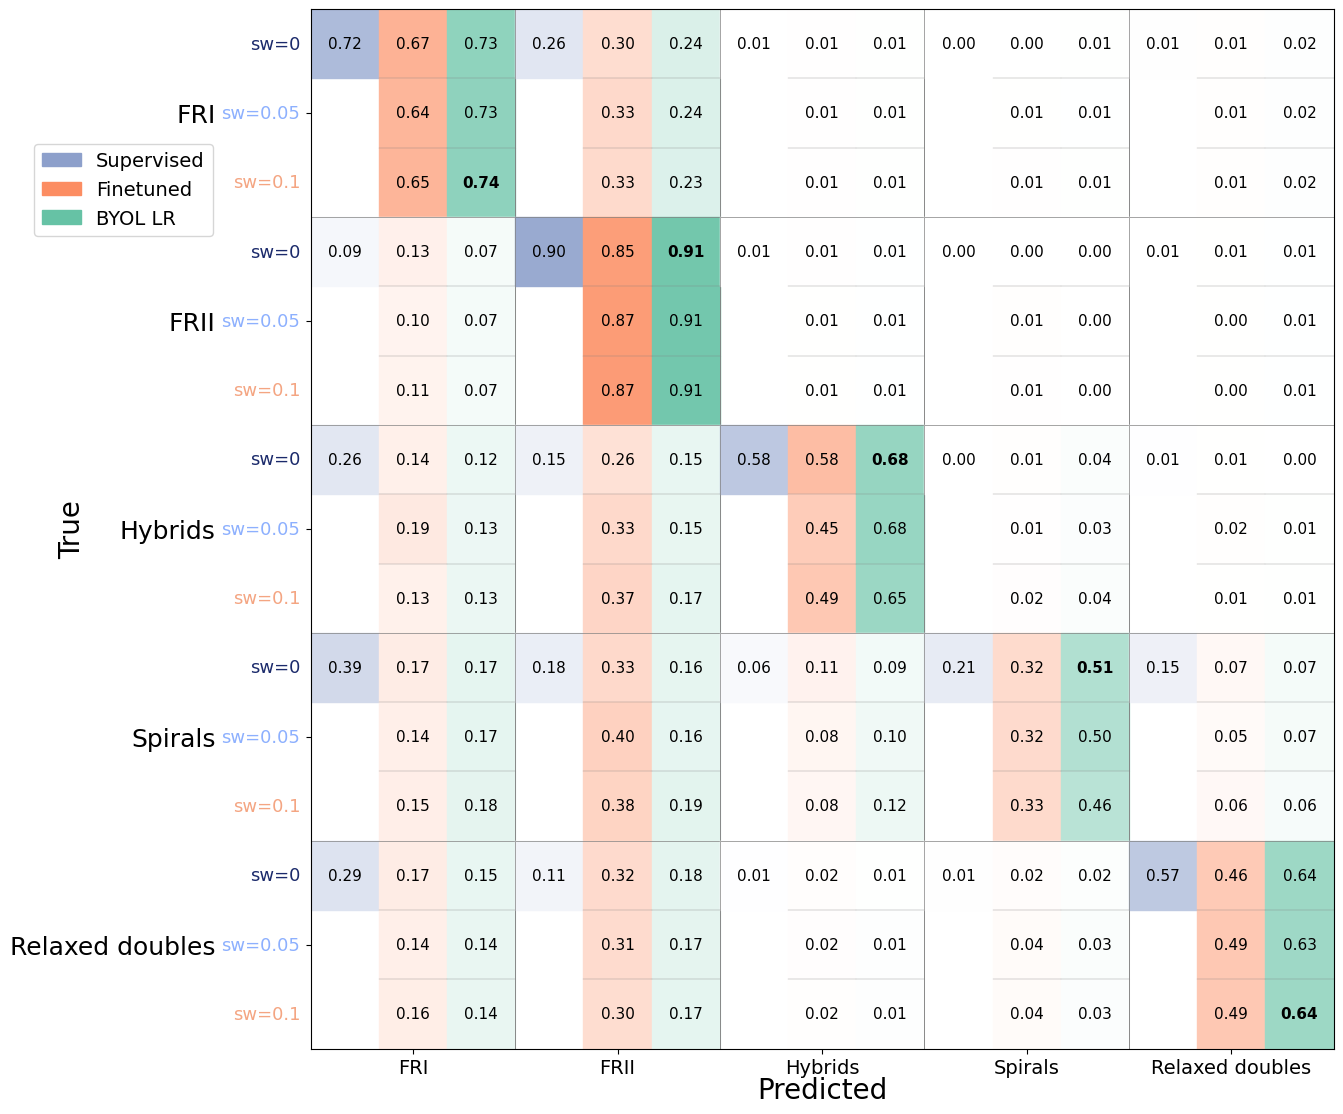

In [33]:
# ── Multi-sw comparison confusion matrix ──────────────────────────────────────
# Fallback: Section 8.1 may have been skipped (BYOL predictions unavailable)
if "cm_s_n" not in dir():
    cm_s_n  = _cm_base_mean if "_cm_base_mean" in dir() else None
    cm_s_lo = _cm_base_lo   if "_cm_base_lo"   in dir() else None
    cm_s_hi = _cm_base_hi   if "_cm_base_hi"   in dir() else None
    _bl_src = "from Section 8 setup" if cm_s_n is not None else "unavailable (Section 8 setup not run)"
    print(f"[8.2 fallback] cm_s_n not set by Section 8.1 — using supervised baseline {_bl_src}")
if "_class_names" not in dir():
    _class_names = [ALL_CLASS_NAMES[i] for i in LABEL_SETS[_ls]]
NO_ERROR_BARS = True   # hide ± CI annotations
_SW_COMPARE   = [0.0, 0.05, 0.1]

# ── Find sibling run dirs for each sw value ───────────────────────────────────
_run_name_dir  = _run_dir.parent.parent      # e.g. outputs/byol_runs/pd128_.../
_byol_runs_dir = _run_name_dir.parent        # e.g. outputs/byol_runs/
_f_val         = _parse_param(_run_name_dir.name, 'f')

def _find_sw_run_dir(sw_val):
    # Always use _run_name_dir directly for the current run's sw value
    _cur_sw_str = _parse_param(_run_name_dir.name, 'sw')
    try:
        if _cur_sw_str is not None and abs(float(_cur_sw_str) - float(sw_val)) < 1e-9:
            return _run_name_dir
    except (ValueError, TypeError):
        pass
    # Search sibling directories for other sw values — must match f value too
    for d in sorted(_byol_runs_dir.iterdir()):
        if not d.is_dir():
            continue
        _sw_d = _parse_param(d.name, 'sw')
        _f_d  = _parse_param(d.name, 'f')
        if _sw_d is None or _f_d is None:
            continue
        try:
            if (abs(float(_sw_d) - float(sw_val)) < 1e-9
                    and abs(float(_f_d) - float(_f_val)) < 1e-9):
                return d
        except (ValueError, TypeError):
            pass
    return None

def _iter_fold_or_seed_dirs(run_name_dir):
    """Yield all leaf dirs to aggregate over: folds within each seed dir, or the seed dir itself."""
    seed_dirs = _get_seed_dirs(run_name_dir)
    if seed_dirs:
        for _sd in seed_dirs:
            yield from _get_fold_dirs(_sd)
    else:
        yield from _get_fold_dirs(run_name_dir)

# ── Helper: load normalised CM for BYOL LR across folds/seeds ────────────────
def _load_byol_cm_ms(run_dir):
    if run_dir is None:
        return None, None, None
    _norms = []
    for _sd in _iter_fold_or_seed_dirs(run_dir):
        _cd = (_sd / "data" / "classifiers" / "simple_downstream" / f"{_tls_cm}_{_cw_tag}")
        if not _cd.exists():
            _cd = _sd / "data" / "classifiers" / "simple_downstream" / _tls_cm
        _pp = _cd / f"{_clf_short}_projections_test_probs.npy"
        _lp = _cd / "projections_test_labels.npy"
        if not (_pp.exists() and _lp.exists()):
            continue
        _pr = np.load(_pp); _lb = np.load(_lp)
        if _lb.ndim == 1:
            _yt = _lb; _yp = _pr.argmax(axis=1)
        elif _ls in _PURE_SETS_CM:
            _ec = LABEL_SETS[_ls]; _tc = LABEL_SETS[_tls_cm]
            _cm_idx = [_tc.index(c) for c in _ec if c in _tc]
            _mk = _lb[:, _ec].sum(axis=1) == 1
            _yt = _lb[_mk][:, _ec].argmax(axis=1)
            _yp = _pr[_mk][:, _cm_idx].argmax(axis=1)
        else:
            _yt = _lb; _yp = (_pr >= 0.5).astype(int)
        _cm_r = confusion_matrix(_yt, _yp, labels=list(range(n_cls)))
        _norms.append(_cm_r / _cm_r.sum(axis=1, keepdims=True).clip(min=1))
    if not _norms:
        return None, None, None
    _mn = np.mean(_norms, axis=0)
    (_lo, _hi) = _ci68(np.stack(_norms), axis=0) if len(_norms) > 1 else (None, None)
    return _mn, _lo, _hi

# ── Helper: load finetuning normalised CM across folds/seeds ─────────────────
def _load_ft_cm_ms(run_dir):
    if run_dir is None:
        return None, None, None
    _cw_tag_ft = f"cw{_cw}" if _cw else "cwNone"
    _ft_type   = f"{_tls}_{_cw_tag_ft}{_es_tag}_{CONFIG['finetuning_spec']}"
    _norms = []
    for _sd in _iter_fold_or_seed_dirs(run_dir):
        _fd = _sd / "data" / "classifiers" / "finetuning" / _ft_type
        if not _fd.exists():
            _fd_alt = _sd / "data" / "classifiers" / "finetuning" / f"{_tls}_{_cw_tag_ft}0.0{_es_tag}_{CONFIG['finetuning_spec']}"
            if _fd_alt.exists():
                _fd = _fd_alt
        if not _fd.exists():
            _fd_pure = _sd / "data" / "classifiers" / "finetuning" / f"initial_pure_{_cw_tag_ft}0.0{_es_tag}_{CONFIG['finetuning_spec']}"
            if _fd_pure.exists():
                _fd = _fd_pure
        if not _fd.exists():
            continue
        for _rp in sorted(_fd.glob("frac_1.00/run*/test_probs.npy")):
            _rl = _rp.parent / "test_labels.npy"
            if not _rl.exists():
                continue
            _p = np.load(_rp); _l = np.load(_rl)
            if _l.ndim == 2 and _l.shape[1] >= 5:
                _mk = _l[:, :5].sum(axis=1) == 1
                _p, _l = _p[_mk, :5], _l[_mk, :5]
            _yt = _l.argmax(axis=1) if _l.ndim == 2 else _l
            _cm_r = confusion_matrix(_yt, _p.argmax(axis=1), labels=list(range(n_cls)))
            _norms.append(_cm_r / _cm_r.sum(axis=1, keepdims=True).clip(min=1))
    if not _norms:
        return None, None, None
    _mn = np.mean(_norms, axis=0)
    (_lo, _hi) = _ci68(np.stack(_norms), axis=0) if len(_norms) > 1 else (None, None)
    return _mn, _lo, _hi

# ── Collect data ──────────────────────────────────────────────────────────────
_ms_dirs     = {sw: _find_sw_run_dir(sw) for sw in _SW_COMPARE}
_ms_byol_cms = {sw: _load_byol_cm_ms(_ms_dirs[sw]) for sw in _SW_COMPARE}
_ms_ft_cms   = {sw: _load_ft_cm_ms(_ms_dirs[sw])   for sw in _SW_COMPARE}

print("Run directories:")
for sw, d in _ms_dirs.items():
    b_ok = _ms_byol_cms[sw][0] is not None
    f_ok = _ms_ft_cms[sw][0] is not None
    print(f"  sw={sw}: {d if d else 'NOT FOUND'}  byol={b_ok}  ft={f_ok}")

# ── Plot ──────────────────────────────────────────────────────────────────────
from matplotlib.colors import LinearSegmentedColormap as _LSC2
_mk_cmap2 = lambda h: _LSC2.from_list("", ["white", h])
_cmap_b2  = _mk_cmap2("#66c2a5")
_cmap_ft2 = _mk_cmap2("#fc8d62")
_cmap_s2  = _mk_cmap2("#8da0cb")

_n_sw   = len(_SW_COMPARE)
_w_col  = 1.0 / 3          # width of each main column (Supervised | FT | BYOL)
_h_sub  = 1.0 / _n_sw      # height of each sw sub-row within FT / BYOL columns

# Colour per sw from canonical SW_PALETTE (indices 0,1,3 → sw 0.0,0.05,0.5)
_ms_sw_colors = {0.0: _SW_PALETTE[0], 0.05: _SW_PALETTE[1], 0.1: _SW_PALETTE[2]}

_clf_disp2 = {"linear_probe": "LR", "random_forest": "RF", "knn": "KNN"}.get(
    CM_CONFIG["byol_classifier"], CM_CONFIG["byol_classifier"])

fig2, ax2 = plt.subplots(figsize=(n_cls * 2.5 + 3, n_cls * 2.5 + 1))
plt.subplots_adjust(left=0.32, right=0.98)
ax2.set_xlim(0, n_cls); ax2.set_ylim(0, n_cls)
ax2.invert_yaxis()

for i in range(n_cls):
    for j in range(n_cls):
        # ── Diagonal bold: find max mean across all sub-cells ─────────────────
        if i == j:
            _d_vals = []
            for sw in _SW_COMPARE:
                mn, _, _ = _ms_byol_cms[sw]
                if mn is not None: _d_vals.append(mn[i, j])
                mn, _, _ = _ms_ft_cms[sw]
                if mn is not None: _d_vals.append(mn[i, j])
            if cm_s_n is not None: _d_vals.append(cm_s_n[i, j])
            _d_max = max(_d_vals) if _d_vals else float("nan")
        else:
            _d_max = float("nan")

        # ── Left column: Supervised baseline — sw=0 sub-row only ───────────────
        if cm_s_n is not None:
            _val = cm_s_n[i, j]
            _fw  = "bold" if (i == j and abs(_val - _d_max) < 1e-9) else "normal"
            ax2.add_patch(plt.Rectangle([j, i], _w_col, _h_sub, color=_cmap_s2(_val)))
            ax2.text(j + _w_col * 0.5, i + _h_sub * 0.5, f"{_val:.2f}",
                     ha="center", va="center", fontsize=11, fontweight=_fw)
            if cm_s_lo is not None and not NO_ERROR_BARS:
                ax2.text(j + _w_col * 0.5, i + _h_sub * 0.28, f"+{cm_s_hi[i,j]:.2f}",
                         ha="center", va="center", fontsize=6, color="#111111")
                ax2.text(j + _w_col * 0.5, i + _h_sub * 0.72, f"-{cm_s_lo[i,j]:.2f}",
                         ha="center", va="center", fontsize=6, color="#111111")

        # ── Middle column: Finetuned — one sub-row per sw ─────────────────────
        for k, sw in enumerate(_SW_COMPARE):
            mn, lo, hi = _ms_ft_cms[sw]
            _val = mn[i, j] if mn is not None else 0.0
            _y0  = i + k * _h_sub
            ax2.add_patch(plt.Rectangle([j + _w_col, _y0], _w_col, _h_sub,
                                        color=_cmap_ft2(_val if mn is not None else 0.0)))
            if mn is not None:
                _fw = "bold" if (i == j and abs(_val - _d_max) < 1e-9) else "normal"
                ax2.text(j + _w_col * 1.5, _y0 + _h_sub * 0.5, f"{_val:.2f}",
                         ha="center", va="center", fontsize=11, fontweight=_fw)
                if lo is not None and not NO_ERROR_BARS:
                    ax2.text(j + _w_col * 1.5, _y0 + _h_sub * 0.28, f"+{hi[i,j]:.2f}",
                             ha="center", va="center", fontsize=6, color="#111111")
                    ax2.text(j + _w_col * 1.5, _y0 + _h_sub * 0.72, f"-{lo[i,j]:.2f}",
                             ha="center", va="center", fontsize=6, color="#111111")

        # ── Right column: BYOL LR — one sub-row per sw ───────────────────────
        for k, sw in enumerate(_SW_COMPARE):
            mn, lo, hi = _ms_byol_cms[sw]
            _val = mn[i, j] if mn is not None else 0.0
            _y0  = i + k * _h_sub
            ax2.add_patch(plt.Rectangle([j + 2*_w_col, _y0], _w_col, _h_sub,
                                        color=_cmap_b2(_val if mn is not None else 0.0)))
            if mn is not None:
                _fw = "bold" if (i == j and abs(_val - _d_max) < 1e-9) else "normal"
                ax2.text(j + _w_col * 2.5, _y0 + _h_sub * 0.5, f"{_val:.2f}",
                         ha="center", va="center", fontsize=11, fontweight=_fw)
                if lo is not None and not NO_ERROR_BARS:
                    ax2.text(j + _w_col * 2.5, _y0 + _h_sub * 0.28, f"+{hi[i,j]:.2f}",
                             ha="center", va="center", fontsize=6, color="#111111")
                    ax2.text(j + _w_col * 2.5, _y0 + _h_sub * 0.72, f"-{lo[i,j]:.2f}",
                             ha="center", va="center", fontsize=6, color="#111111")

        # ── Cell border + sub-row dividers ────────────────────────────────────
        ax2.add_patch(plt.Rectangle([j, i], 1, 1, fill=False, edgecolor="grey", lw=0.5))
        for k in range(1, _n_sw):
            _y_div = i + k * _h_sub
            ax2.plot([j + _w_col,   j + 2*_w_col], [_y_div, _y_div], color="grey", lw=0.25)
            ax2.plot([j + 2*_w_col, j + 3*_w_col], [_y_div, _y_div], color="grey", lw=0.25)

# ── Axes ──────────────────────────────────────────────────────────────────────
ax2.set_xticks(np.arange(n_cls) + 0.5)
ax2.set_xticklabels(_class_names, rotation=0, ha="center", fontsize=14)
ax2.set_yticks(np.arange(n_cls) + 0.5)
ax2.set_yticklabels(_class_names, fontsize=18)
ax2.tick_params(axis='y', pad=65)
ax2.set_xlabel("Predicted", fontsize=20, labelpad=-1)
ax2.set_ylabel("True", fontsize=20, labelpad=-55)

# ── SW sub-row labels: left margin, one label per (class row, sw) ─────────────
from matplotlib.transforms import blended_transform_factory as _btf
_ms_trans = _btf(ax2.transAxes, ax2.transData)
for i in range(n_cls):
    for k, sw in enumerate(_SW_COMPARE):
        _yc = i + (k + 0.5) * _h_sub
        ax2.text(-0.01, _yc, f"sw={sw:.2g}",
                 transform=_ms_trans, ha="right", va="center",
                 fontsize=13, color=_ms_sw_colors.get(sw, "grey"), clip_on=False)

# ── Legend ────────────────────────────────────────────────────────────────────
import matplotlib.patches as mpatches
ax2.legend(handles=[
    mpatches.Patch(color="#8da0cb", label="Supervised"),
    mpatches.Patch(color="#fc8d62", label="Finetuned"),
    mpatches.Patch(color="#66c2a5", label=f"BYOL {_clf_disp2}"),
], loc="upper left", bbox_to_anchor=(-0.28, 0.88), ncol=1, fontsize=14, frameon=True)

_run_nm2 = _run_dir.name

## 9. Generative Augmentation

Performance when generated images are added to the supervised training set.

- **9.1** Gen fraction sweep — metric vs. generated-image fraction for ENB0 and BYOL LR across sw values; the gen fraction = 0 point comes from the matching without-generative baseline
- **9.2** Augmentation comparison — side-by-side comparison of augmentation strategies at a fixed label fraction

### 9.1 Gen Fraction Sweep

Metric vs. generated-image fraction for ENB0 and BYOL LR, across sw values. Error bands show ±1 std across seeds. Gen fraction = 0 is injected from the without-generative baseline (`_baseline_frac0`).

> **Seed pairing:** This section uses **diagonal seeds** (data\_seed = training\_seed), unlike the rest of the notebook which uses training\_seed = data\_seed + 1. The diagonal pairing is necessary here to keep the seeds consistent with the generator, which was trained on the same data split.

Found 83 gen run dir(s) from 2 base dir(s)

Evaluating on: initial_pure



Aggregated by (sw, model) — 9 combination(s):
  sw=0.0  model=byollr: fracs=[0.0, 0.5, 1.0, 2.0, 5.0]
  sw=0.0  model=enb0: fracs=[0.0, 0.5, 1.0, 2.0, 5.0]
  sw=0.05  model=byollr: fracs=[0.0, 0.5, 1.0, 2.0, 5.0]
  sw=0.05  model=enb0: fracs=[0.0, 0.5, 1.0, 2.0, 5.0]
  sw=0.1  model=byollr: fracs=[0.0, 0.5, 1.0, 2.0, 5.0]
  sw=0.1  model=enb0: fracs=[0.0, 0.5, 1.0, 2.0, 5.0]
  sw=0.5  model=byollr: fracs=[0.0, 0.5, 1.0, 2.0, 5.0]
  sw=0.5  model=enb0: fracs=[0.0, 0.5, 1.0, 2.0, 5.0]
  sw=1.0  model=enb0: fracs=[0.0, 0.5, 1.0, 2.0, 5.0]


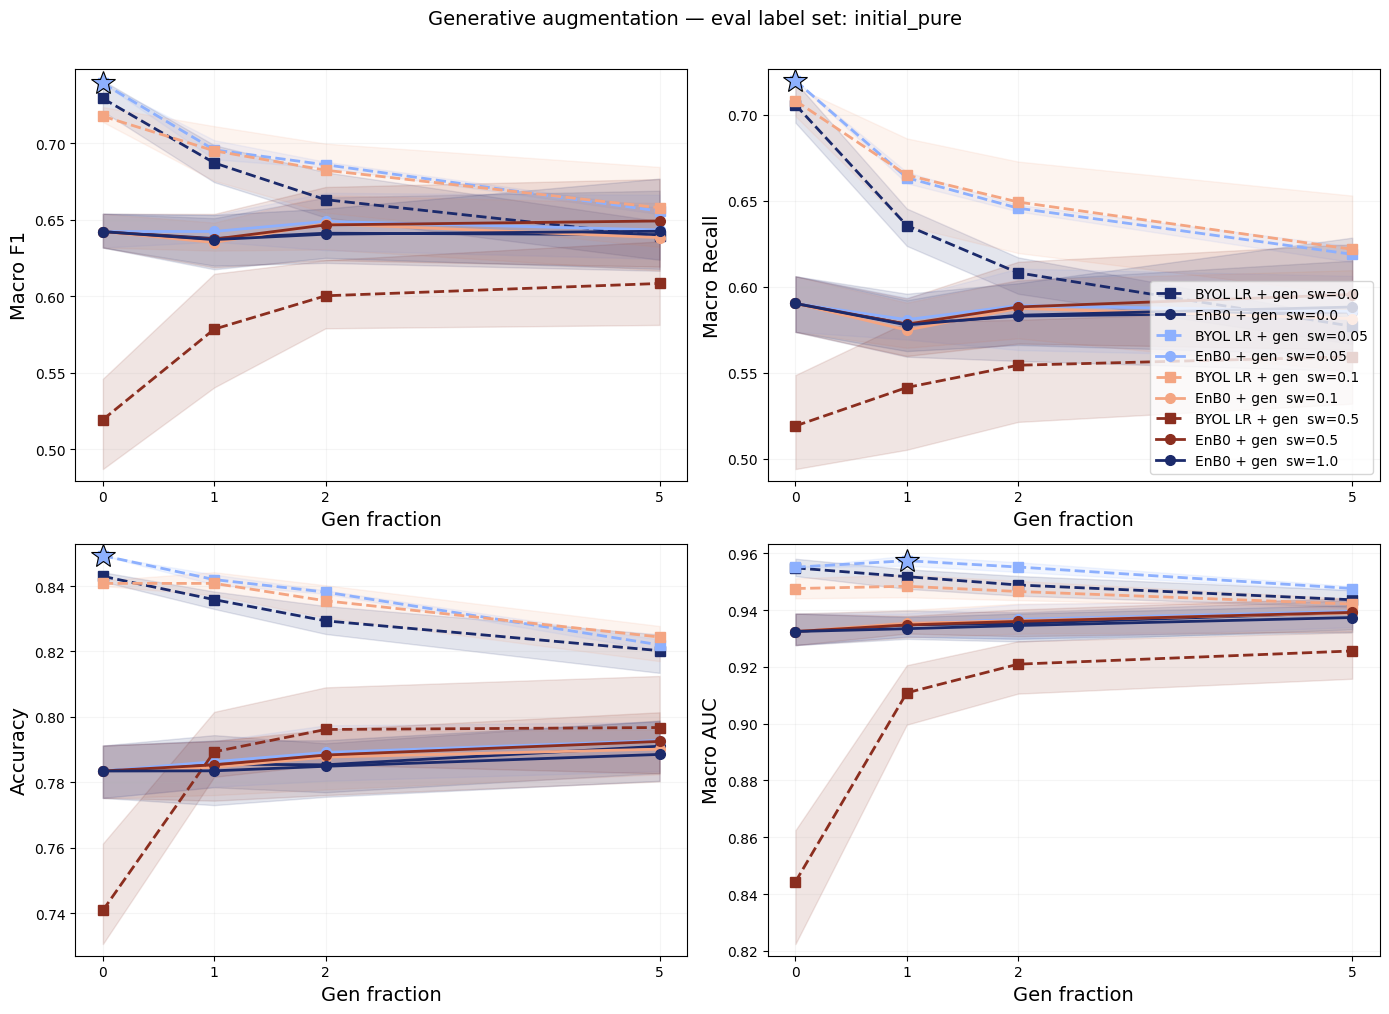

Saved → /users/mbredber/p3_SUPLAT/outputs/figures/classification/gen_aug_sweep.pdf


In [34]:
# ── Find all gen-aug run dirs (baselines_dir + gen_sweep_dirs) ────────────────
_scan_bases = list(dict.fromkeys([
    CONFIG["baselines_dir"],
    *CONFIG.get("gen_sweep_dirs", []),
]))
_all_gen_dirs = []
for _bpath in _scan_bases:
    _gen_base = Path(_bpath) / "with_generative"
    if _gen_base.exists():
        _all_gen_dirs.extend(sorted(d for d in _gen_base.iterdir() if d.is_dir()))

print(f"Found {len(_all_gen_dirs)} gen run dir(s) from {len(_scan_bases)} base dir(s)")

_eval_ls = CONFIG["eval_label_set"]
print(f"\nEvaluating on: {_eval_ls}")

_GA_METRICS = [
    ("f1_macro",     "Macro F1"),
    ("recall_macro", "Macro Recall"),
    ("accuracy",     "Accuracy"),
    ("auc_macro",    "Macro AUC"),
]
_GA_KEYS = [m for m, _ in _GA_METRICS]


def _parse_gen_dir(name):
    """Extract (model, ls, cw) from gen-aug dir name."""
    # byollr_<ls>_<cw>_sw*_s*
    m = re.match(r'byollr_(.+?)_(cw[\w.]+?)(?=_sw|_s\d|$)', name)
    if m:
        ls = m.group(1)
        return {"model": "byollr", "ls": ls, "cw": m.group(2), "genls": ls}
    # enb0_<ls>_<cw>[_ES]_<digits><suffix>_gen<ls>
    m = re.match(r'enb0_(.+?)_(cw[\w.]+?)(?:_ES)?_\d+\w+_gen(\w+)', name)
    if m:
        return {"model": "enb0", "ls": m.group(1), "cw": m.group(2), "genls": m.group(3)}
    # enb0_<ls>_<cw>_sw*_s*
    m = re.match(r'enb0_(.+?)_(cw[\w.]+?)(?=_sw|_s\d|$)', name)
    if m:
        ls = m.group(1)
        return {"model": "enb0", "ls": ls, "cw": m.group(2), "genls": ls}
    return {"model": "?", "ls": "?", "cw": "cwNone", "genls": "?"}


def _read_gen_sw(run_dir):
    """Extract sw from gen_dir field in config.log."""
    cfg_path = run_dir / "config.log"
    if not cfg_path.exists():
        return "?"
    with open(cfg_path) as fp:
        for line in fp:
            if line.startswith("gen_dir:"):
                m = re.search(r'_sw([\d.]+)', line)
                if m:
                    return m.group(1)
    return "?"


def _load_gen_frac_results(run_dir, clf_ls, eval_ls):
    """Load {gfrac: {mkey: [values]}} from a gen dir."""
    frac_dirs = list(run_dir.glob("frac_*")) or list(run_dir.glob("gen_aug/frac_*"))
    result = {}
    for _fdir in sorted(frac_dirs):
        try:
            _gf = float(_fdir.name.replace("frac_", ""))
        except ValueError:
            continue
        _bucket = result.setdefault(_gf, {mk: [] for mk in _GA_KEYS})
        for _rrun in sorted(_fdir.glob("run*")):
            _rj = _rrun / "results.json"
            if not _rj.exists():
                continue
            if clf_ls == eval_ls:
                with open(_rj) as fp:
                    r = json.load(fp)
                for mk in _GA_KEYS:
                    if mk in r:
                        _bucket[mk].append(float(r[mk]))
            else:
                _cache = _rrun / f"results_{eval_ls}_eval.json"
                if _cache.exists():
                    with open(_cache) as fp:
                        r = json.load(fp)
                    for mk in _GA_KEYS:
                        if mk in r:
                            _bucket[mk].append(float(r[mk]))
                else:
                    _pb_path = _rrun / "test_probs.npy"
                    _lb_path = _rrun / "test_labels_20.npy"
                    if _pb_path.exists() and _lb_path.exists():
                        try:
                            _m = _cross_eval_metrics(
                                np.load(_pb_path), np.load(_lb_path), clf_ls, eval_ls)
                            with open(_cache, "w") as fp:
                                json.dump(_m, fp, indent=2)
                            for mk in _GA_KEYS:
                                if mk in _m:
                                    _bucket[mk].append(float(_m[mk]))
                        except ValueError as _e:
                            print(f"  Skipping {_rrun.name}: {_e}")
    return result


def _baseline_frac0(gen_dir_name, clf_ls, eval_ls):
    """Read frac=0 per-run values from the matching without_generative baseline.

    For enb0: globs without_generative/enb0_{ls}_{cwtag}* (handles _sN_dsN suffix),
              keeps only diagonal runs (sN == dsN), pools per-run values.
    For byollr: frac=0 comes from its own frac_0.00/ dir; this function returns None.
    """
    m = re.match(r'(?:enb0|byollr)_(.+?)_(cw[\w.]+?)(?=_sw|_s\d|_ES|_\d|$)', gen_dir_name)
    if not m:
        return None
    ls, cwtag = m.group(1), m.group(2)
    if gen_dir_name.startswith("byollr"):
        return None  # byollr frac=0 comes from frac_0.00/ in its gen dirs
    _bbase = Path(CONFIG["baselines_dir"])
    # Glob for dirs matching enb0_{ls}_{cwtag}* (new naming: _sN_dsN suffix)
    _wg_dir = _bbase / "without_generative"
    _bl_dirs = sorted(d for d in _wg_dir.glob(f"enb0_{ls}_{cwtag}*") if d.is_dir()) if _wg_dir.exists() else []
    # Keep only diagonal runs (sN == dsN) or un-suffixed dirs
    _bl_dirs = [d for d in _bl_dirs
                if not (_m2 := re.search(r'_s(\d+)_ds(\d+)$', d.name))
                or _m2.group(1) == _m2.group(2)]
    if not _bl_dirs:
        _d = _bbase / f"enb0_{ls}_{cwtag}"  # old flat location
        if _d.exists():
            _bl_dirs = [_d]
    if not _bl_dirs:
        return None
    if clf_ls == eval_ls:
        _per_run = {mk: [] for mk in _GA_KEYS}
        for _bl_dir in _bl_dirs:
            _rs_path = _bl_dir / "run_summary.json"
            if not _rs_path.exists():
                continue
            with open(_rs_path) as fp:
                rs = json.load(fp)
            pm = rs.get("per_metric", {})
            for mk in _GA_KEYS:
                _per_run[mk].extend(pm.get(mk, {}).get("per_run", []))
        return _per_run if any(_per_run.values()) else None
    else:
        _per_run = {mk: [] for mk in _GA_KEYS}
        for _bl_dir in _bl_dirs:
            for _rrun in sorted(_bl_dir.glob("run*")):
                _cache = _rrun / f"results_{eval_ls}_eval.json"
                if _cache.exists():
                    with open(_cache) as fp:
                        r = json.load(fp)
                    for mk in _GA_KEYS:
                        if mk in r:
                            _per_run[mk].append(float(r[mk]))
                else:
                    _pb_path = _rrun / "test_probs.npy"
                    _lb_path = _rrun / "test_labels_20.npy"
                    if _pb_path.exists() and _lb_path.exists():
                        try:
                            _m = _cross_eval_metrics(
                                np.load(_pb_path), np.load(_lb_path), clf_ls, eval_ls)
                            with open(_cache, "w") as fp:
                                json.dump(_m, fp, indent=2)
                            for mk in _GA_KEYS:
                                if mk in _m:
                                    _per_run[mk].append(float(_m[mk]))
                        except ValueError:
                            pass
        return _per_run if any(_per_run.values()) else None


# ── Pool raw run values by (sw, model) ───────────────────────────────────────
_raw_by_sw   = {}   # (sw, model) -> {gfrac -> {mkey -> [values]}}
_frac0_added = set()

for _grd in _all_gen_dirs:
    _attrs = _parse_gen_dir(_grd.name)
    if _attrs["ls"] == "?":
        print(f"  Skipping unrecognised dir: {_grd.name}")
        continue
    _sw    = _read_gen_sw(_grd)
    _model = _attrs["model"]
    _key   = (_sw, _model)

    _frac_vals = _load_gen_frac_results(_grd, _attrs["ls"], _eval_ls)

    # For enb0, inject frac=0 from the without_generative baseline
    if _model == "enb0" and _sw not in _frac0_added:
        _bl0 = _baseline_frac0(_grd.name, _attrs["ls"], _eval_ls)
        if _bl0:
            _frac_vals[0.0] = _bl0
            _frac0_added.add(_sw)

    if not _frac_vals:
        continue

    if _key not in _raw_by_sw:
        _raw_by_sw[_key] = {}
    for gf, mdict in _frac_vals.items():
        if gf not in _raw_by_sw[_key]:
            _raw_by_sw[_key][gf] = {mk: [] for mk in _GA_KEYS}
        for mk, vs in mdict.items():
            _raw_by_sw[_key][gf][mk].extend(vs)


# ── Compute mean + CI68 ───────────────────────────────────────────────────────
def _sw_sort_key(s):
    try: return float(s)
    except ValueError: return float("inf")

_ga_by_sw = {}  # (sw, model) -> {gfrac -> {mkey -> (mean, lo, hi)}}
for key in sorted(_raw_by_sw, key=lambda k: (_sw_sort_key(k[0]), k[1])):
    _ga_by_sw[key] = {}
    for gf in sorted(_raw_by_sw[key]):
        _ga_by_sw[key][gf] = {}
        for mk, vs in _raw_by_sw[key][gf].items():
            if not vs:
                continue
            mean_v = float(np.mean(vs))
            lo, hi = (_ci68(vs) if len(vs) > 1 else (0.0, 0.0))
            _ga_by_sw[key][gf][mk] = (mean_v, float(lo), float(hi))

_sw_vals = sorted({sw for sw, _ in _ga_by_sw}, key=_sw_sort_key)
_models  = sorted({model for _, model in _ga_by_sw})

print(f"\nAggregated by (sw, model) — {len(_ga_by_sw)} combination(s):")
for (sw, model), fdata in _ga_by_sw.items():
    print(f"  sw={sw}  model={model}: fracs={sorted(fdata)}")

# ── Visual encoding: color by sw, line style by model ────────────────────────
_sw_color    = {sw: _SW_PALETTE[i % len(_SW_PALETTE)] for i, sw in enumerate(_sw_vals)}
_model_style = {"enb0": "-", "byollr": "--"}
_model_label = {"enb0": "EnB0 + gen",  "byollr": "BYOL LR + gen"}

# ── Plot ───────────────────────────────────────────────────────────────────────
if not _ga_by_sw:
    print("No gen-aug data found — skipping plot.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    fig.suptitle(f"Generative augmentation — eval label set: {_eval_ls}", fontsize=14, y=1.01)

    for ax, (mkey, ylabel) in zip(axes, _GA_METRICS):
        _best_val, _best_x, _best_y, _best_key = -np.inf, None, None, None
        _yall = []

        for (sw, model) in sorted(_ga_by_sw, key=lambda k: (_sw_sort_key(k[0]), k[1])):
            da   = _ga_by_sw[(sw, model)]
            col  = _sw_color[sw]
            ls   = _model_style.get(model, "-")
            xs      = sorted(gf for gf in da if gf != 0.5)
            ys      = [da[gf].get(mkey, (float("nan"), 0.0, 0.0))[0] for gf in xs]
            lo_errs = [da[gf].get(mkey, (float("nan"), 0.0, 0.0))[1] for gf in xs]
            hi_errs = [da[gf].get(mkey, (float("nan"), 0.0, 0.0))[2] for gf in xs]

            marker = "o" if model == "enb0" else "s"
            ax.plot(xs, ys, color=col, linestyle=ls, linewidth=2,
                    marker=marker, markersize=7)
            ax.fill_between(xs,
                            [y - lo for y, lo in zip(ys, lo_errs)],
                            [y + hi for y, hi in zip(ys, hi_errs)],
                            alpha=0.12, color=col)
            _yall.extend(y - lo for y, lo in zip(ys, lo_errs) if np.isfinite(y))
            _yall.extend(y + hi for y, hi in zip(ys, hi_errs) if np.isfinite(y))

            for gf, y in zip(xs, ys):
                if np.isfinite(y) and y > _best_val:
                    _best_val, _best_x, _best_y, _best_key = y, gf, y, (sw, model)

        if _best_x is not None:
            ax.plot(_best_x, _best_y, "*",
                    color=_sw_color[_best_key[0]], markersize=18,
                    markeredgecolor="k", markeredgewidth=0.8, zorder=10)

        ax.set_xlabel("Gen fraction", fontsize=14)
        ax.set_ylabel(ylabel, fontsize=14)
        _pad = 0.03 * (max(_yall) - min(_yall)) if _yall else 0.05
        ax.set_ylim(min(_yall) - _pad if _yall else 0,
                    max(_yall) + _pad if _yall else 1.05)
        ax.set_xticks([0, 1, 2, 5])
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: str(int(x))))
        ax.grid(True, alpha=0.12)

    # Legend: one entry per (sw, model) combination
    _handles = []
    for sw in _sw_vals:
        for model in _models:
            if (sw, model) not in _ga_by_sw:
                continue
            _handles.append(plt.Line2D(
                [], [],
                color=_sw_color[sw],
                linestyle=_model_style.get(model, "-"),
                linewidth=2,
                marker="o" if model == "enb0" else "s",
                markersize=7,
                label=f"{_model_label.get(model, model)}  sw={sw}",
            ))
    axes[1].legend(handles=_handles, fontsize=10, loc="lower right")

    fig.tight_layout()
    _out = f"{OUT_DIR}/gen_aug_sweep.pdf"
    plt.savefig(_out, bbox_inches="tight")
    plt.show()
    print(f"Saved → {_out}")


### 9.2 Augmentation Comparison

Side-by-side comparison of augmentation strategies (e.g. standard vs. generative) at a fixed label fraction, for the same eval label set.

> **Seed pairing:** This section uses **diagonal seeds** (data\_seed = training\_seed), unlike the rest of the notebook which uses training\_seed = data\_seed + 1. The diagonal pairing is necessary here to keep the seeds consistent with the generator, which was trained on the same data split.

Condition 1 (no aug): found 5 dir(s)


  n_values per metric: {'f1_macro': 15, 'recall_macro': 15, 'accuracy': 15, 'auc_macro': 15}
Condition 2 (only classical): found 5 dir(s)


  n_values per metric: {'f1_macro': 15, 'recall_macro': 15, 'accuracy': 15, 'auc_macro': 15}

Condition 3 (only generative): found 15 dir(s)



Condition 4 (classical + generative, frac≈1): sw values = ['0.0', '0.05', '0.1', '0.5', '1.0']


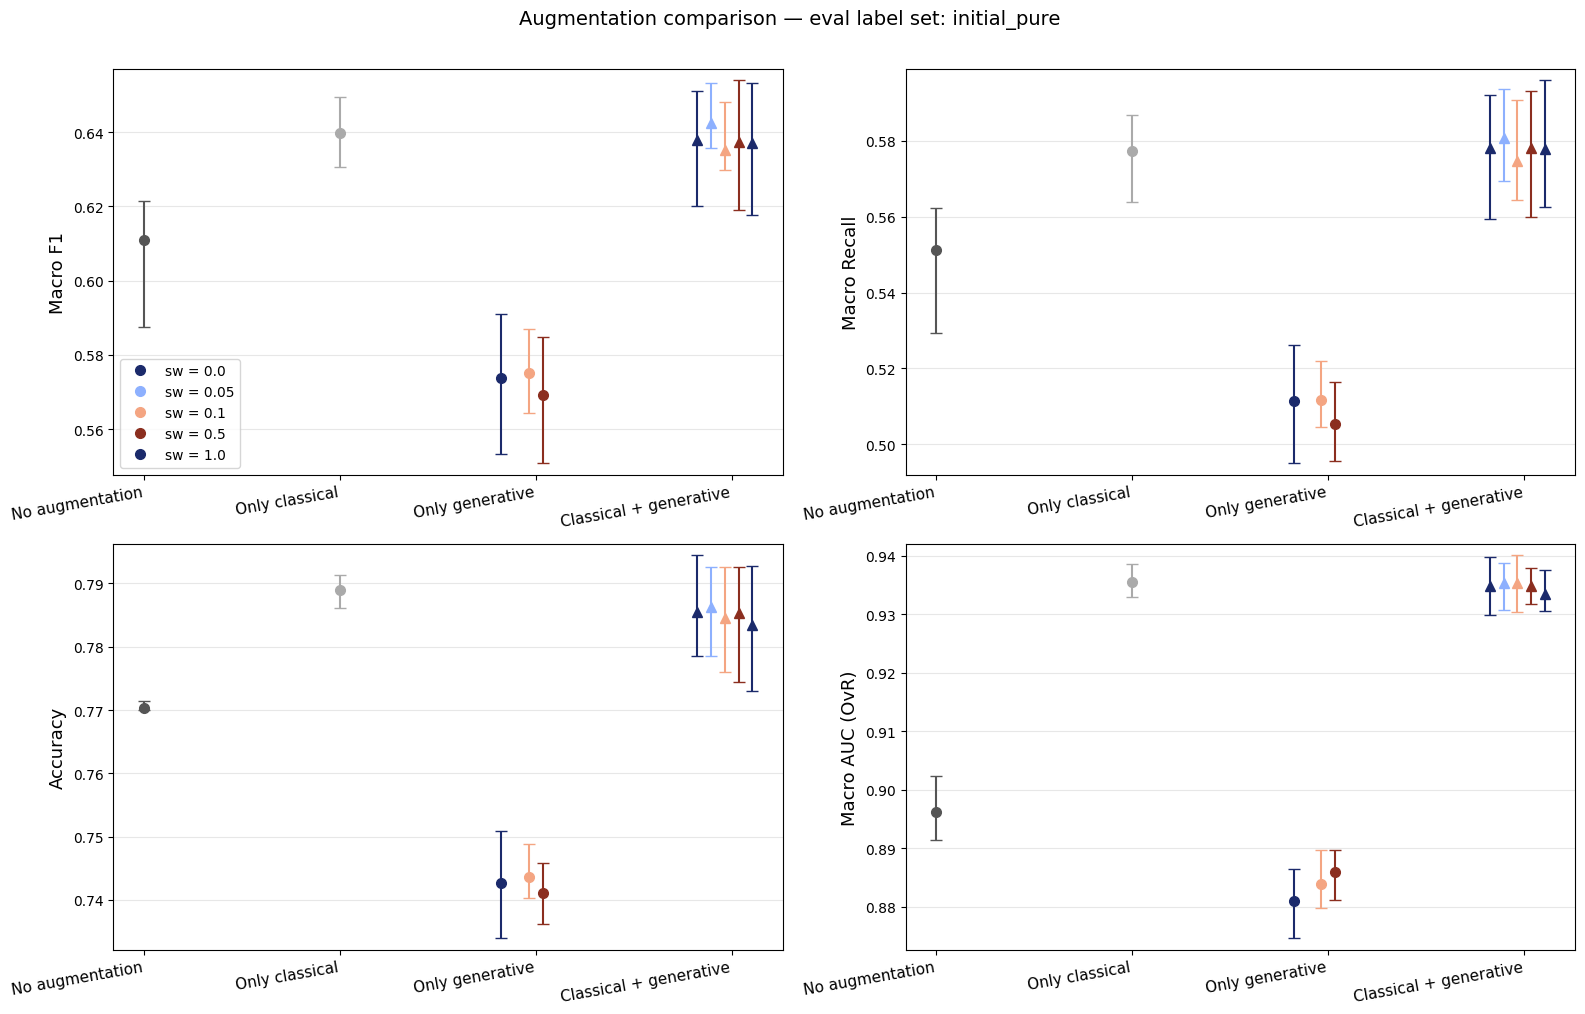

Saved → /users/mbredber/p3_SUPLAT/outputs/figures/classification/aug_comparison.pdf


In [35]:
# ── Augmentation Comparison ───────────────────────────────────────────────────
# Conditions:
#   1. no_aug:          aug_comp/without_generative/*_noaug*
#   2. only_classical:  aug_comp/without_generative/*classicaug*
#   3. only_gen:        aug_comp/with_generative/*_noaug*, grouped by sw and frac
#   4. classical+gen:   gen-aug sweep (_ga_by_sw, enb0 only), gen frac=1, grouped by sw

_AC_METRICS = [
    ("f1_macro",     "Macro F1"),
    ("recall_macro", "Macro Recall"),
    ("accuracy",     "Accuracy"),
    ("auc_macro",    "Macro AUC (OvR)"),
]
_AC_KEYS = [m for m, _ in _AC_METRICS]

_eval_ls_ac = CONFIG["eval_label_set"]
_aug_comp    = Path(CONFIG["aug_comp_dir"])
_wogen       = _aug_comp / "without_generative"


def _load_run_vals(run_dir, eval_ls):
    """Collect per-metric values from all run*/results.json in run_dir."""
    vals = {mk: [] for mk in _AC_KEYS}
    for rrun in sorted(run_dir.glob("run*")):
        rj = rrun / "results.json"
        if not rj.exists():
            continue
        with open(rj) as fp:
            r = json.load(fp)
        for mk in _AC_KEYS:
            if mk in r:
                vals[mk].append(float(r[mk]))
    return vals


def _load_frac_run_vals(run_dir, eval_ls):
    """Collect {frac: {mk: [vals]}} from frac_*/run*/results.json."""
    result = {}
    for fdir in sorted(run_dir.glob("frac_*")):
        try:
            gf = float(fdir.name.replace("frac_", ""))
            if gf == 5.0:
                continue
        except ValueError:
            continue
        bucket = result.setdefault(gf, {mk: [] for mk in _AC_KEYS})
        for rrun in sorted(fdir.glob("run*")):
            rj = rrun / "results.json"
            if not rj.exists():
                continue
            with open(rj) as fp:
                r = json.load(fp)
            for mk in _AC_KEYS:
                if mk in r:
                    bucket[mk].append(float(r[mk]))
    return result


# ── Collect condition 1: no aug ───────────────────────────────────────────────
_noaug_raw = {mk: [] for mk in _AC_KEYS}
_noaug_dirs = sorted(_wogen.glob("*_noaug*")) if _wogen.exists() else []
print(f"Condition 1 (no aug): found {len(_noaug_dirs)} dir(s)")
for _d in _noaug_dirs:
    _v = _load_run_vals(_d, _eval_ls_ac)
    for mk in _AC_KEYS:
        _noaug_raw[mk].extend(_v[mk])
print(f"  n_values per metric: { {mk: len(_noaug_raw[mk]) for mk in _AC_KEYS} }")

# ── Collect condition 2: only classical aug ───────────────────────────────────
_clsaug_raw = {mk: [] for mk in _AC_KEYS}
_clsaug_dirs = sorted(_wogen.glob("*classicaug*")) if _wogen.exists() else []
print(f"Condition 2 (only classical): found {len(_clsaug_dirs)} dir(s)")
for _d in _clsaug_dirs:
    _v = _load_run_vals(_d, _eval_ls_ac)
    for mk in _AC_KEYS:
        _clsaug_raw[mk].extend(_v[mk])
print(f"  n_values per metric: { {mk: len(_clsaug_raw[mk]) for mk in _AC_KEYS} }")

# ── Collect condition 3: only generative (no classical aug), grouped by sw ────
_gennoaug_raw = {}   # sw -> {gf -> {mk: [vals]}}
_gennoaug_dirs = []
if (_aug_comp / "with_generative").exists():
    for _d in sorted((_aug_comp / "with_generative").iterdir()):
        if _d.is_dir() and "noaug" in _d.name:
            _gennoaug_dirs.append(_d)
print(f"\nCondition 3 (only generative): found {len(_gennoaug_dirs)} dir(s)")
for _d in _gennoaug_dirs:
    _sw = _read_gen_sw(_d)
    _fvals = _load_frac_run_vals(_d, _eval_ls_ac)
    if _sw not in _gennoaug_raw:
        _gennoaug_raw[_sw] = {}
    for gf, mdict in _fvals.items():
        if gf not in _gennoaug_raw[_sw]:
            _gennoaug_raw[_sw][gf] = {mk: [] for mk in _AC_KEYS}
        for mk, vs in mdict.items():
            _gennoaug_raw[_sw][gf][mk].extend(vs)

# ── Condition 4: classical + generative — gen frac=1 from gen-aug sweep ───────
# Uses _ga_by_sw (keyed by (sw, model)); filter to enb0 only.
_clsgen_agg = {}   # sw -> mk -> (mean, lo, hi)
if "_ga_by_sw" in dir() and _ga_by_sw:
    for (sw, model), fdata in _ga_by_sw.items():
        if model != "enb0":
            continue
        _avail = [gf for gf in fdata if gf > 0]
        if not _avail:
            continue
        _target_gf = min(_avail, key=lambda gf: abs(gf - 1.0))
        _clsgen_agg[sw] = {mk: fdata[_target_gf].get(mk, (float("nan"), 0.0, 0.0))
                           for mk in _AC_KEYS}
    print(f"\nCondition 4 (classical + generative, frac≈1): sw values = {sorted(_clsgen_agg)}")
else:
    print("\nCondition 4: _ga_by_sw not available — run the gen-aug sweep cell first")

# ── Mean + CI68 helpers ───────────────────────────────────────────────────────
def _agg(vals):
    """Return (mean, lo_err, hi_err) or (nan, 0, 0) if empty."""
    if not vals:
        return float("nan"), 0.0, 0.0
    mean_v = float(np.mean(vals))
    if len(vals) > 1:
        lo, hi = _ci68(vals)
        return mean_v, float(lo), float(hi)
    return mean_v, 0.0, 0.0

_noaug_agg   = {mk: _agg(_noaug_raw[mk])   for mk in _AC_KEYS}
_clsaug_agg  = {mk: _agg(_clsaug_raw[mk])  for mk in _AC_KEYS}

# gen+noaug aggregated: sw -> gf -> mk -> (mean, lo, hi)
_gennoaug_agg = {}
for sw, fdata in _gennoaug_raw.items():
    _gennoaug_agg[sw] = {}
    for gf, mdict in fdata.items():
        _gennoaug_agg[sw][gf] = {mk: _agg(mdict[mk]) for mk in _AC_KEYS}

# ── X-axis layout ─────────────────────────────────────────────────────────────
_gen_fracs_sorted = sorted(set(gf for fd in _gennoaug_agg.values() for gf in fd))
_sw_vals_ac       = sorted(
    set(list(_gennoaug_agg.keys()) + list(_clsgen_agg.keys())),
    key=lambda s: (float(s) if s != "?" else 999),
)
_sw_color_ac  = {sw: _SW_PALETTE[i % len(_SW_PALETTE)] for i, sw in enumerate(_sw_vals_ac)}

_JITTER = 0.07

_xtick_labels_ac = ["No augmentation", "Only classical", "Only generative", "Classical + generative"]
_xtick_pos_ac    = [0, 1, 2, 3]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
fig.suptitle(f"Augmentation comparison — eval label set: {_eval_ls_ac}", fontsize=14, y=1.01)

_n_gen_combos   = len(_sw_vals_ac) * len(_gen_fracs_sorted)
_n_clsgen_combos = len(_clsgen_agg)

for ax, (mkey, ylabel) in zip(axes, _AC_METRICS):
    _yall = []

    # Condition 1: no aug
    m, lo, hi = _noaug_agg[mkey]
    ax.errorbar(0, m, yerr=[[lo], [hi]], fmt="o", color="#555555",
                capsize=4, markersize=7)
    if np.isfinite(m): _yall.extend([m - lo, m + hi])

    # Condition 2: only classical aug
    m, lo, hi = _clsaug_agg[mkey]
    ax.errorbar(1, m, yerr=[[lo], [hi]], fmt="o", color="#aaaaaa",
                capsize=4, markersize=7)
    if np.isfinite(m): _yall.extend([m - lo, m + hi])

    # Condition 3: only generative — jittered by (sw, frac) at x=2
    combo_idx = 0
    for i_sw, sw in enumerate(_sw_vals_ac):
        col = _sw_color_ac[sw]
        for i_gf, gf in enumerate(_gen_fracs_sorted):
            if sw not in _gennoaug_agg or gf not in _gennoaug_agg[sw]:
                combo_idx += 1
                continue
            xpos = 2 + (combo_idx - _n_gen_combos / 2) * _JITTER
            m, lo, hi = _gennoaug_agg[sw][gf][mkey]
            ax.errorbar(xpos, m, yerr=[[lo], [hi]], fmt="o", color=col,
                        capsize=4, markersize=7)
            if np.isfinite(m): _yall.extend([m - lo, m + hi])
            combo_idx += 1

    # Condition 4: classical + generative (gen frac≈1) — jittered by sw at x=3
    for i_sw, (sw, sw_metrics) in enumerate(sorted(_clsgen_agg.items(),
                                                    key=lambda x: float(x[0]) if x[0] != "?" else 999)):
        col = _sw_color_ac.get(sw, "grey")
        xpos = 3 + (i_sw - _n_clsgen_combos / 2) * _JITTER
        m, lo, hi = sw_metrics.get(mkey, (float("nan"), 0.0, 0.0))
        ax.errorbar(xpos, m, yerr=[[lo], [hi]], fmt="^", color=col,
                    capsize=4, markersize=7)
        if np.isfinite(m): _yall.extend([m - lo, m + hi])

    ax.set_xticks(_xtick_pos_ac)
    ax.set_xticklabels(_xtick_labels_ac, rotation=10, fontsize=11, ha="right")
    ax.set_ylabel(ylabel, fontsize=13)
    _pad = 0.03 * (max(_yall) - min(_yall)) if _yall else 0.05
    ax.set_ylim(min(_yall) - _pad if _yall else 0,
                max(_yall) + _pad if _yall else 1.05)
    ax.grid(True, alpha=0.3, axis="y")

# ── Legend — colour = sw value only ──────────────────────────────────────────
_leg_handles = [
    plt.Line2D([], [], color=_sw_color_ac[sw], linestyle="none",
               marker="o", markersize=7, label=f"sw = {sw}")
    for sw in _sw_vals_ac
]
axes[0].legend(handles=_leg_handles, fontsize=10, loc="lower left")

fig.tight_layout()
_out_ac = f"{OUT_DIR}/aug_comparison.pdf"
plt.savefig(_out_ac, bbox_inches="tight")
plt.show()
print(f"Saved → {_out_ac}")